In [1]:
import pandas as pd
import pickle
import json
from matplotlib import pyplot as plt
import torch
import numpy as np
import os
import itertools
import seaborn as sns
import warnings
from sklearn.metrics import RocCurveDisplay
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)


# DEFINE DATASET NAMES + FUNCTIONS

In [2]:
parameters_for_analysis={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':{
                            'result_cat':'RESULT_AT_END_OF_TREATMENT',
                            'selection_method':'patient_clustering',
                            'clust_comb':'2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':22,
                            'training_days':120},
                         
                         'tb21_1405_pats_41_vars_result_at_end_of_treatment':{
                            'result_cat':'RESULT_AT_END_OF_TREATMENT',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':41,
                            'training_days':120},
    
    
                        'tb21_22__20_3441_pats_9_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':9,
                            'training_days':120},
                
    
                        'tb21_22_2416_pats_27_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':27,
                            'training_days':120},

                        'tb21_1268_pats_43_vars_result_at_18_months':{
                            'result_cat':'RESULT_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                         
                         'tb21_1240_pats_43_vars_unfavour_cat_at_18_months':{
                            'result_cat':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':43,
                            'training_days':120},
                        
                         'tb21_1258_pats_42_vars_result_at_12_months':{
                            'result_cat':'RESULT_AT_12_MONTHS',
                            'selection_method':'patient_clustering',
                            'clust_comb':'1-2-3-4-5',
                            'graph_metric':None,
                            'num_of_common_vars':42,
                            'training_days':120},
                        }



##=========================================
## SCALE TRAINING AND TESTING DATA WITH A STANDARD SCALER TRAINED ON THE TRAINING DATA
def scale_by_training_data(X_train, X_test):
    from sklearn.preprocessing import StandardScaler

    ## Standardise non-binary numerical columns ==> select numerical columns and drop columns already scaled
    numerical_cols=X_train.select_dtypes(exclude=['object'])
    non_binary_num_cols = []

    for col in numerical_cols.columns:
        unique_values = np.sort(numerical_cols[col].unique())
        if np.array_equal(unique_values, np.array([0, 1]))==False:
            non_binary_num_cols.append(col)

    if len(non_binary_num_cols)>0:
        std_scaler = StandardScaler()
        std_scaler.fit(X_train.loc[:,non_binary_num_cols])
        X_train.loc[:,non_binary_num_cols]=std_scaler.transform(X_train.loc[:,non_binary_num_cols])
        X_test.loc[:,non_binary_num_cols]=std_scaler.transform(X_test.loc[:,non_binary_num_cols])

        #X_train.loc[:,non_binary_num_cols]=(StandardScaler().fit_transform(X_train.loc[:,non_binary_num_cols]))

        '''        
        ## As DAY colum,n also gets standardised, transform the training_days number as well, in order to susbet the
        #  data to training-testing set
        std_scaler = StandardScaler()
        std_scaler.fit(X.loc[:, 'DAY'].values.reshape(-1, 1))
        std_training_days = std_scaler.transform([[training_days]])
        '''

    return (X_train, X_test)


##=========================================
## SPLIT TRAINING AND TESTING DATA IN A STRATIFIED MANNER
#  - Standardise non-binary numerical columns with a standard scaler trained on the training dataset
#  - If training_data_type=='last_therapy_day', just keep the information from the last therapy day
                                                                                     
def create_std_training_testing_data(X,y,pat_ids,test_size_ratio,rand_state,training_data_type,columns_to_drop):

    X_train_pat_ids, X_test_pat_ids, _, _ = train_test_split(pat_ids, y, test_size=test_size_ratio, stratify=y,random_state=rand_state)

    X_train=X.loc[X['USUBJID'].isin(X_train_pat_ids),:]
    X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]

    X_train, X_test=scale_by_training_data(X_train, X_test)
    
    ## Just take the last therapy day inormation from patient
    if training_data_type=='last_therapy_day':
        X_train=X_train.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
        X_test=X_test.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])

    
    ## Subset y to training and testing set 
    # - If training_data_type=='last_therapy_day', this means one label per patient (i.e. Each patient has one row input)
    # - If training_data_type=='full', this means num_of_input_rows label per patient (i.e. Each patient has 'n' rows of input)
    y_train=y.loc[X_train['USUBJID'].values.tolist()]
    y_test=y.loc[X_test['USUBJID'].values.tolist()]
    
    ## Drop columns that are not necessary for training 
    if len(columns_to_drop)>0:
        X_train=X_train.drop(columns=columns_to_drop)
        X_test=X_test.drop(columns=columns_to_drop)
    
    
    ## Add STUDYID information to index for y_test and y_train
    y_test_=y_test.reset_index()
    y_test_['STUDYID']=y_test_['USUBJID'].str.split('/',expand=True)[0].values
    y_test_=y_test_.set_index(['USUBJID','STUDYID'])
    
    y_train_=y_train.reset_index()
    y_train_['STUDYID']=y_train_['USUBJID'].str.split('/',expand=True)[0].values
    y_train_=y_train_.set_index(['USUBJID','STUDYID'])
    
    return X_train,X_test,y_train_,y_test_,X_train_pat_ids,X_test_pat_ids
        

 

###=========================================
### FUNCTION FOR TRAINING THE ML MODELS & CALCULATING CV ROC-AUC SCORES
def init_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq) :

    from sklearn.model_selection import cross_val_score,RepeatedKFold,cross_validate,GridSearchCV
    from sklearn.linear_model import Lasso,LogisticRegressionCV,LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.svm import SVC
    from sklearn.neighbors import KNeighborsClassifier

    
    
    if weight_by_label_freq==True:
        target_label_freq=y_train_data[outcome_label].value_counts(normalize=True)
        
        target_label_freq=target_label_freq.sort_index(ascending=False)

        label_weights_dict={label:1/x for label,x in zip(target_label_freq.index.tolist(),
                                                         target_label_freq.values.tolist())}

        rf_label_weight='balanced' 
        gb_label_weight=y_train_data[outcome_label].map(label_weights_dict).values
        #print(gb_label_weight)
        #print('label_weights_dict',label_weights_dict)
    
    if weight_by_label_freq==False:
        rf_label_weight=None   
        gb_label_weight=None
        label_weights_dict=None
        

    if 'RandomForest' in model_name:

        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        '''
        rfCV=RandomForestClassifier(n_estimators=200, max_features='sqrt',random_state=random_state,
                                     class_weight=label_weights)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'max_depth':[3,5,7],}

        grid=GridSearchCV(rfCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        print(model_name,'parameter grid search...')

        '''
                                    
        model=RandomForestClassifier(class_weight=rf_label_weight,random_state=random_state,
                                     **model_params)
        
        #model=RandomForestClassifier(n_estimators=500, max_features='sqrt',random_state=random_state,
        #                             class_weight=label_weights)
        #model.fit(X_train, y_train_data)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'GradientBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        '''
        gbCV=GradientBoostingClassifier(n_estimators=200, subsample=0.9,max_features='sqrt',random_state=random_state,\
                                        learning_rate=0.1)
        params={'n_estimators':[300,500],'max_features':['log2', 'sqrt'],'learning_rate':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(gbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=GradientBoostingClassifier(n_estimators=grid.best_params_['n_estimators'], subsample=0.9,
                                         max_features=grid.best_params_['max_features'],random_state=random_state,\
                                         learning_rate=grid.best_params_['learning_rate']) 
        '''                                                 
        
        model=GradientBoostingClassifier(random_state=random_state,**model_params)
        
        #model.fit(X_train, y_train_data,label_weights=gb_label_weight)
        #feature_names=model.feature_names_in_
        #feature_importances=model.feature_importances_

        
    elif 'XGBoost' in model_name:
        
        label_weights=gb_label_weight
        label_weight_param_name='sample_weight'
        
        '''
        xgbCV=XGBClassifier(n_estimators=200, max_depth=7, eta=0.1, subsample=1.0, colsample_bytree=0.8,\
                           random_state=random_state)
        params={'n_estimators':[250,500],'max_depth':[3,5,7],'eta':[0.1,0.3,0.5],}

        print(model_name,'parameter grid search...')                        
        grid=GridSearchCV(xgbCV,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)    
        grid.fit(X_train,y_train_data,sample_weight=label_weights)

        model=XGBClassifier(n_estimators=grid.best_params_['n_estimators'], max_depth=grid.best_params_['max_depth'],
                            eta=grid.best_params_['eta'], subsample=1.0, colsample_bytree=0.8,\
                            random_state=random_state)
        '''
        model=XGBClassifier(random_state=random_state,**model_params,colsample_bytree=0.8)
        #model.fit(X_train, y_train_data,sample_weight=label_weights)
        #feature_names=X_train.columns.tolist()
        #feature_importances=model.feature_importances_

        
    elif 'LogisticRegression' in model_name:
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        
        model=LogisticRegression(penalty='elasticnet',solver='saga',class_weight=label_weights,max_iter=1000,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_names=X_train.columns.tolist()
        #feature_importances=np.abs(model.coef_)

    
    elif 'SVC' in model_name:
        
        label_weights=rf_label_weight
        label_weight_param_name='class_weight'
        '''
        svc=SVC(kernel='rbf',gamma='scale', C=1.0,class_weight=rf_label_weight)
        params={'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(svc,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)

        model=SVC(kernel='rbf',gamma='scale', C=grid.best_params_['C'],class_weight=rf_label_weight)
        '''
        model=SVC(gamma='scale',class_weight=rf_label_weight,**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)

        
    elif 'KNN' in model_name:
        
        label_weights=None
        label_weight_param_name=None
        '''
        knn=KNeighborsClassifier(n_neighbors=2)
        params={'n_neighbors':[2,5,10,25,50,100]}
        #f1_macro_scorer=make_scorer(f1_score, average='macro')

        grid=GridSearchCV(knn,param_grid=params,cv=3,scoring='roc_auc',verbose=1,return_train_score=True)
        grid.fit(X_train,y_train_data)
        model=KNeighborsClassifier(n_neighbors=grid.best_params_['n_neighbors'])
        '''
        model=KNeighborsClassifier(**model_params)
        #model.fit(X_train, y_train_data)
        #feature_importances=np.abs(model.coef_)   
        
    return model,label_weights,label_weights_dict



##=========================================
def run_cv(X,y,k_folds,model_name,weight_by_label_freq,random_state,outcome_label,model_params):
    
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import roc_auc_score
    from sklearn.model_selection import cross_validate
    pd.options.mode.chained_assignment = None
    
    
    pat_ids=y.index.get_level_values('USUBJID').unique()
    y_unique=y.reset_index().drop_duplicates(subset='USUBJID').set_index('USUBJID',drop=True)
    #print('y_unique',y_unique.loc[pat_ids,:])
   
    
    # Initialize a StratifiedKFold splitter
    skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=random_state)

    # Initialize lists to store the evaluation scores
    train_roc_auc_scores_all,test_roc_auc_scores_all=[],[]
    train_roc_auc_scores_per_study,test_roc_auc_scores_per_study=[],[]
    
    cv_roc_auc_scores={}

    # Loop through each fold
    for train_index, test_index in skf.split(pat_ids, y_unique.loc[pat_ids,outcome_label]):
        
        train_pat_ids=pat_ids[train_index]
        test_pat_ids=pat_ids[test_index]
        
        #print('train test index set',set(train_pat_ids)&set(test_pat_ids))
        
        train_mask=y.index.get_level_values('USUBJID').isin(train_pat_ids)
        test_mask=y.index.get_level_values('USUBJID').isin(test_pat_ids)
        
        
        # Split the data
        X_train_fold, X_test_fold = X.loc[train_mask,:], X.loc[test_mask,:]
        y_train_fold,y_test_fold=y.loc[train_mask,:],y.loc[test_mask,:]

        
        ## Init model
        model,label_weights,_=init_model(model_name,X_train_fold,y_train_fold,
                                         k_folds,random_state,outcome_label,
                                         model_params,
                                         weight_by_label_freq) 
        
        ## Fit model
        if model_name in ['XGBoost','GradientBoost']:
            model.fit(X_train_fold, y_train_fold.values.ravel(),sample_weight=label_weights)
        else:
            model.fit(X_train_fold, y_train_fold.values.ravel())
                

        # Predict probabilities on the training and test data
        train_probabilities = model.predict_proba(X_train_fold)[:, 1]
        test_probabilities = model.predict_proba(X_test_fold)[:, 1]
        
        
        ## If patients come from multiple studies, calculate the ROC-AUC score within the studies as well
        if len(y.index.get_level_values('STUDYID').unique())>1:
            y_train_fold['pred']=train_probabilities
            y_test_fold['pred']=test_probabilities
            
            train_roc_auc_per_study=y_train_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))
            test_roc_auc_per_study=y_test_fold.groupby('STUDYID').apply(lambda x:roc_auc_score(x[outcome_label],x['pred']))
            
            train_roc_auc_scores_per_study.append(train_roc_auc_per_study)
            test_roc_auc_scores_per_study.append(test_roc_auc_per_study)
            
      
        # Calculate ROC AUC scores for all prediction across all studies
        train_roc_auc=roc_auc_score(y_train_fold[outcome_label], train_probabilities)
        test_roc_auc=roc_auc_score(y_test_fold[outcome_label], test_probabilities)

        # Append the scores to the lists
        train_roc_auc_scores_all.append(train_roc_auc)
        test_roc_auc_scores_all.append(test_roc_auc)
        

    ## Add ROC-AUC values calculated across all studies to the result dictionary
    cv_roc_auc_scores['train_score']=train_roc_auc_scores_all
    cv_roc_auc_scores['test_score']=test_roc_auc_scores_all

    ## If multiple studies, join the per-study ROC-AUC scores into one dataframe containing scores per CV-fold 
    if len(y.index.get_level_values('STUDYID').unique())>1:
        
        train_roc_auc_per_study_df=pd.concat(train_roc_auc_scores_per_study,axis=1)
        test_roc_auc_per_study_df=pd.concat(test_roc_auc_scores_per_study,axis=1)
        
        cv_roc_auc_scores['train_score_per_study']=train_roc_auc_per_study_df
        cv_roc_auc_scores['test_score_per_study']=test_roc_auc_per_study_df
    
    return cv_roc_auc_scores 





##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def run_parameter_search(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                param_search_dict,
                                weight_by_label_freq):
    from tqdm.auto import tqdm
    
    param_search_results={}
        
    ### RUN CV WITH DIFFERENT PARAMETER SETS & SAVE THE CV-RESULTS INTO A DICT
    parameter_combinations = list(itertools.product(*param_search_dict[model_name].values()))
    parameter_sets=[{key: value for key, value in zip(param_search_dict[model_name].keys(), combination)} for combination in parameter_combinations]

    #for n, model_params in enumerate(parameter_sets):
    for n, model_params in enumerate(tqdm(parameter_sets[:], desc="Processing", unit="parameter_set")):

        ## Create string of the parameters
        pairs=[f"{key}:{value}" for key, value in model_params.items()]
        param_set_string='-'.join(pairs)
  
        #print(f'Running CV of {model_name} model with parameters:{param_set_string}')
              
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params)
        
        ## SAVE RESULT OF CV WITH GIVEN PARAMETER SET
        param_search_results[param_set_string]=cv_roc_auc_scores

        
    return param_search_results



##=========================================

def extract_best_model_params(param_search_results,metric_func):
    
    def is_float(s):
        try:
            a=float(s)
            return True
        except ValueError:
            return False
    
    
    ## Init dictionary to hold the best results for each CV-repetition
    best_cv_rep_results={}
    
    ## Loop through all thr CV-repeats and extract the CV-scores of the validation splits
    for cv_rep_num in param_search_results['param_search_results'].keys():
        
        cv_rep_param_search_results = param_search_results['param_search_results'][cv_rep_num]
    
        best_score=0
        
        ## If metric of validation is better than the previous ones, replace the best parameter set with current parameter set
        for param_set_string in cv_rep_param_search_results:
            cv_test_score = metric_func(cv_rep_param_search_results[param_set_string]['test_score'])

            if cv_test_score>best_score:
                best_param_set=param_set_string
                best_score=cv_test_score
        
        ## Convert the best parameter-set to a dictionary
        best_model_params={key_val_pair.split(':')[0]:key_val_pair.split(':')[1] for key_val_pair in best_param_set.split('-')}
        #print('best_model_params',best_model_params)
        ## Convert numeric to floats
        
        
        
        best_model_params={key:float(value) if is_float(value) else value for key,value in best_model_params.items() }
        #print('best_model_params',best_model_params)
        
        best_cv_rep_results[cv_rep_num]=best_model_params
        
        #print(f'Best CV-score {best_score} in CV-rep {cv_rep_num}, best params: {best_model_params}')
        
    ## Initialize dictionary for averaging the parameters of the best parameter-sets/CV-repeat
    best_model_params_avg={}
    
    ## Average the parameters values across the different CV-splits, and save them into a dictionary
    n = len(best_cv_rep_results)
    for param_name in best_cv_rep_results[[*best_cv_rep_results][0]].keys():
        
        if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==True:
        
            best_model_params_avg[param_name] = sum(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()) / n

            if best_model_params_avg[param_name]>1:
                best_model_params_avg[param_name]=int(best_model_params_avg[param_name])
                
        if is_float(best_cv_rep_results[[*best_cv_rep_results][0]][param_name])==False:
            best_model_params_avg[param_name]= list(set(best_cv_rep_results[cv_rep_num][param_name] for cv_rep_num in best_cv_rep_results.keys()))[0]
        
    return best_model_params_avg


##=========================================
## RUN CV OF GIVEN MODEL & TRAIN FINAL MODEL AFTERWARDS
def calc_roc_auc_score_of_model(model_name,X_train,y_train_data,
                                k_folds,random_state,
                                outcome_label,
                                model_params,
                                weight_by_label_freq):
        
    ### RUN CV & TRAIN MODEL AFTERWARDS
    if model_name in ['XGBoost','GradientBoost']:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq) 
        
        model.fit(X_train, y_train_data,sample_weight=label_weights)
        
    else:
        
        ## CALCULATE CV-SCORES
        cv_roc_auc_scores=run_cv(X_train,y_train_data,k_folds,
                                 model_name,weight_by_label_freq,
                                 random_state,outcome_label,
                                 model_params)
        
        ## INITIALIZE MODEL & TRAIN 
        model,label_weights,label_weights_dict=init_model(model_name,X_train,y_train_data,
                                                          k_folds,random_state,outcome_label,
                                                          model_params,
                                                          weight_by_label_freq) 
        
        model.fit(X_train, y_train_data)
        
    return model,cv_roc_auc_scores,label_weights_dict



##=========================================
## Setup function for calculating elapsed time
def print_elapsed_time(start,stop):
    # Calculate the elapsed time in seconds
    elapsed_seconds = stop - start
    
    # Convert elapsed time to hours and minutes
    elapsed_minutes, elapsed_seconds = divmod(int(elapsed_seconds), 60)
    elapsed_hours, elapsed_minutes = divmod(elapsed_minutes, 60)
    
    # Print the result in the desired format
    print(f"Elapsed time:{elapsed_hours} hours:{elapsed_minutes} minutes")
    
    
    
##=========================================  
'''
def draw_pca_biplot(score,coeff,y,loading_rel_length_thr,legend_title,labels=None):
    from adjustText import adjust_text
    
    fig,ax=plt.subplots(1,1,figsize=(15,10))
    xs = score[:,0]
    ys = score[:,1]
    
    
    load_vect_lengths=np.sqrt(coeff[:,0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths=load_vect_lengths/np.max(load_vect_lengths)

    coeff_filt=coeff[norm_load_vect_lengths>loading_rel_length_thr]
    labels=[x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels=[x.split('dr_reg_')[-1] for x in labels]
    labels_filt=np.array(labels)[norm_load_vect_lengths>loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())
    scatter=ax.scatter(xs * scalex,ys * scaley, c = y,s=4)
    
    # produce a legend with the unique colors from the scatter
    h=scatter.legend_elements()[0]
    l=[id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h,labels=l,loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i,0], coeff_filt[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            ax.text(coeff_filt[i,0]* 1.15, coeff_filt[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            ax.text(coeff_filt[i,0]* 1.2, coeff_filt[i,1] * 1.2, labels_filt[i], color = 'g', ha = 'center', va = 'center')
    #plt.xlim(-1,1)
    #plt.ylim(-1,1)
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()   
    
 '''   
    
def draw_pca_biplot(score, coeff, y, loading_rel_length_thr, legend_title, labels=None):
    from adjustText import adjust_text
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    xs = score[:, 0]
    ys = score[:, 1]
    
    load_vect_lengths = np.sqrt(coeff[:, 0]**2 + coeff[:, 1]**2)
    norm_load_vect_lengths = load_vect_lengths / np.max(load_vect_lengths)

    coeff_filt = coeff[norm_load_vect_lengths > loading_rel_length_thr]
    labels = [x.split('_STD_NUM_RESULT')[0] for x in labels]
    labels = [x.split('dr_reg_')[-1] for x in labels]
    labels_filt = np.array(labels)[norm_load_vect_lengths > loading_rel_length_thr]
    
    n = coeff_filt.shape[0]
    
    scalex = 1.0 / (xs.max() - xs.min())
    scaley = 1.0 / (ys.max() - ys.min())
    scatter = ax.scatter(xs * scalex, ys * scaley, c=y, s=4)
    
    # produce a legend with the unique colors from the scatter
    h = scatter.legend_elements()[0]
    l = [id2label[int(x.split('{')[-1].split('}')[0])] for x in scatter.legend_elements()[1]]
    legend1 = ax.legend(handles=h, labels=l, loc="best", title=legend_title)
    ax.add_artist(legend1)
    
    for i in range(n):
        ax.arrow(0, 0, coeff_filt[i, 0], coeff_filt[i, 1], color='r', alpha=0.5)
    
    texts = []
    for i in range(n):
        if labels is None:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center'))
        else:
            texts.append(ax.text(coeff_filt[i, 0] * 1.15, coeff_filt[i, 1] * 1.15, labels_filt[i], color='g', ha='center', va='center'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='b', lw=0.5))
    
    ax.set_xlabel("PC{}".format(1))
    ax.set_ylabel("PC{}".format(2))
    plt.grid()    


##=========================================  
## Select variables from temporal-type data types, where enough patients (==num_of_pats * temp_col_threshold) have entries for that variable
#  - Temporal variables: 
#  (ae: adverse events,ce: clinical events, mh: medical history, cm: concomitant medication, cmind: indication for concomitant medication)
def select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold): 
    variables_per_patient_all=pd.read_csv('../data/all_pat_variables_with_reliable_therapy_data.csv.gz',index_col=0)
    
    vars_per_pat=variables_per_patient_all.loc[X_subset['USUBJID'].unique(),:]
    a=vars_per_pat.loc[:,vars_per_pat.columns.str.startswith(temp_data_name)].sum()
    temp_cols_with_suff_data=a[a>len(X_subset['USUBJID'].unique())*temp_col_threshold].index.tolist()

    return temp_cols_with_suff_data


##=========================================  
## Extract the initial weight of the patient and add it as a column to the data
def add_init_weight_as_variable(X_subset):
    
    init_weights=X_subset.groupby('USUBJID').apply(lambda x: x.loc[x['DAY'].idxmin(),'vs_Weight_STD_NUM_RESULT'])
    
    l=[]
    for pat_idx, pat_df in X_subset.groupby('USUBJID'):
        pat_df['init_weight']=init_weights.loc[pat_idx]
        l.append(pat_df)
        
    X_subset=pd.concat(l,axis=0)
    del l
    
    return X_subset

##=========================================  
def one_hot_encode_categorical_vars(X_subset,categorical_columns):
    one_hot_encoded_arms=pd.get_dummies(X_subset[categorical_columns],dtype=int)
    X_subset=pd.concat([X_subset.drop(columns=categorical_columns), one_hot_encoded_arms], axis=1)

    return X_subset

# PLOT PCAs OF DATA

In [ ]:
import umap
from sklearn.decomposition import PCA


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)

## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

### EXTRACT METADATA OF PATIENTS AND ADD THEM AS COLORING VARIABLES TO THE UMAP PLOT
## Define columns to use for UMAP colouring
col_columns=['STUDYID','AGE','SEX','RACE','ARM']


training_data_types=['full','last_therapy_day']
columns_to_drop=['ARM','STUDYID','DAY','index']
temp_cols_to_drop=['ae','ce','mh','cm'] #
temp_cols_to_drop=['ae','ce','mh','cm','lb','ms','mb']

therapy_day_thr=80
period_end_days=[31,62,93,125,160,'all']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
    
    ## Load concatenated patient data
    fn='../data/'+data_param_key+'_all_data_concat.csv.gz'
    data_conc=pd.read_csv(fn,low_memory=False,index_col=0)
    
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    X=X.loc[X['DAY']>-10,:].copy()
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))].copy()


        ## Subset outcome dataframe to patient considered
        target_df=outcome_df.loc[pat_ids,outcome_label]
        y=target_df.loc[pat_ids].replace(label2id)


        ## Extract value for each patient from the concatenated patient data (multiple timepoints/patient ==> use drop_duplicates to get the unique values)
        meta_df=data_conc.groupby('USUBJID').apply(lambda x: x[col_columns].drop_duplicates()).reset_index().drop(columns=['level_1']).set_index('USUBJID')

        ## Max day during therapy
        max_days_df=data_conc.groupby('USUBJID').apply(lambda x: x['DAY'].max())

        for training_data_type in training_data_types[:]:

            if training_data_type=='last_therapy_day':
                X_full=X_subset.loc[X_subset['USUBJID'].isin(pat_ids),:].sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:]).drop(columns=['USUBJID'])
                col_columns_=col_columns


            if training_data_type=='full':
                X_full=X_subset.loc[X_subset['USUBJID'].isin(pat_ids),:].set_index('USUBJID').copy()
                weeks=np.ceil(X_full['DAY']/7)
                col_columns_=col_columns + ['WEEK']


            if len(columns_to_drop)>0:
                columns_to_drop=columns_to_drop + X_full.columns[X_full.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                X_full=X_full.drop(columns=columns_to_drop)


            print(X_full.columns)
            X_full_, _=scale_by_training_data(X_full, X_full.copy())
            #X_full_= X_full.copy()


            # Perform UMAP
            #reducer=umap.UMAP()

            reducer = PCA(n_components=2)

            embedding=reducer.fit_transform(X_full_)
            umap_df=pd.DataFrame(embedding, columns=['PCA1', 'PCA2'],index=X_full_.index.tolist())

            umap_df[outcome_label]=target_df.loc[umap_df.index].values
            umap_df[col_columns]=meta_df.loc[umap_df.index.tolist(),col_columns].values

            umap_df['Last_therapy_day']=max_days_df.loc[umap_df.index.tolist()].values
            umap_df[col_columns+['Last_therapy_day']]=umap_df[col_columns+['Last_therapy_day']].fillna('NaN')


            if training_data_type=='full':
                umap_df['WEEK']=weeks


            umap_col_cols=[outcome_label,'Last_therapy_day'] + col_columns_

            ncols=3
            nrows=int(np.ceil(len(umap_col_cols)/ncols))
            fig=plt.figure(figsize=(ncols*8,nrows*6))

            suptitle=f"PCA - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full.shape[1]} vars" 
            fig.suptitle(suptitle,fontweight='bold',fontsize=20,y=0.96)

            for n,col in enumerate(umap_col_cols): 
                ax=fig.add_subplot(nrows,ncols,n+1)
                sns.scatterplot(data=umap_df,x='PCA1',y='PCA2',ax=ax,hue=col,s=10)
                ax.set_title(col,fontweight='bold')


            ## Plot PCA biplot
            draw_pca_biplot(embedding[:,0:2],
                           np.transpose(reducer.components_[0:2, :]),
                           y=umap_df[outcome_label].replace(label2id).values,
                           loading_rel_length_thr=0.3,
                           legend_title=outcome_label,
                           labels=X_full_.columns.tolist())

            ax=plt.gca()
            title=f"PCA BIPLOT - {period_end_day} days\n {data_param_key} - {training_data_type} {X_full.shape[1]} vars" 
            ax.set_title(title,fontweight='bold',fontsize=12)


        

# TRAIN ML MODELS

## Define training parameters

In [3]:
from sklearn.model_selection import train_test_split
import warnings
from tqdm import tqdm


outcome_df=pd.read_csv('../data/tb_1018_20_21_22_30_outcome.csv.gz',index_col=0)
outcome_df=outcome_df.set_index('USUBJID',drop=True)
outcome_df=outcome_df.rename(columns={'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS':'UNFAVOUR_CAT_AT_18_MONTHS'})


model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression'][:]

training_data_types=['full','last_therapy_day']
columns_to_drop=['USUBJID','STUDYID','DAY','index'] #'ARM'

temp_cols_to_drop=['ae','ce','cm','lb','ms','mb','dr_reg','vs']#'mh','su'


## Set up prediction labels
id2label={0: "FAVOURABLE", 1: "UNFAVOURABLE"}
label2id={"FAVOURABLE": 0, "UNFAVOURABLE": 1}

#={'UNFAVOUR_CAT_AT_18_MONTHS':'UNFAVOURABLE_OUTCOME_CATEGORY_AT_18_MONTHS'}

## Drop patients who have their last data at an earlier timepin than threshold
therapy_day_thr=80

period_end_days=[31,62,93,125,160,'all']

## Define training parameters
train_params={'k_folds':5,
              'num_cv_repeats':5,
              'weight_by_label_freq':True,
              'random_state':42,
              'test_size_ratio':0.25,
              'label2id':label2id}

## Run parameter search for models

In [6]:
import time    
start=time.time()

    
param_search_dict={'RandomForest':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'max_depth':[3,5,7,9]},
                   
                  'GradientBoost':{'n_estimators':[300,500,700],
                                   'max_features':['sqrt'],
                                   'learning_rate':[0.1,0.3,0.5,0.8]},
                  
                  'XGBoost':{'n_estimators':[300,500,700],
                             'max_depth':[3,5,7,9],
                             'eta':[0.1,0.3,0.5,0.8],
                             'subsample':[1.0,0.9,0.8,0.7]
                            },
                   
                  'LogisticRegression':{'l1_ratio':[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]},
                   
                  'SVC':{'C':[1e-3,1e-2,1e-1,1e0,1e1,1e2],
                        'kernel':['rbf','poly']},
                   
                  'KNN':{'n_neighbors':[2,5,10,25,50,100]},
                  }   




### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]


        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
 
        
        for n, model_name in enumerate(tqdm(model_names[:], total=len(model_names[:]),position=0, leave=True,unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['param_search_results']={}

            for training_data_type in training_data_types[:]:

                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                              train_params['test_size_ratio'],
                                                                                              rand_state,training_data_type,
                                                                                              columns_to_drop_)
                    #print(X_train.columns) 
                    #print(len(X_train.columns.tolist()))
                    #df_=y_train.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    

                    print(f'Running training with {training_data_type} model: {X_train.shape[1]} vars')
                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']={}
                    
                    
                    
                    param_search_results = run_parameter_search(model_name,
                                                                X_train,
                                                                y_train,
                                                                train_params['k_folds'],
                                                                train_params['random_state'],
                                                                outcome_label,
                                                                param_search_dict,
                                                                train_params['weight_by_label_freq'])
                    
                    

                    training_results['param_search_results'][f'cv_rep_{cv_repeat_num}']=param_search_results
                    

                
                
                
                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_param_search_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 



 tb21_1405_pats_41_vars_result_at_end_of_treatment 

Period: 31 days


  0%|          | 0/4 [00:00<?, ?model/s]


XGBoost
Running training with full model: 255 vars
Num of CV-repeat:1


Processing:   0%|          | 0/192 [00:00<?, ?parameter_set/s]

  0%|          | 0/4 [00:03<?, ?model/s]


KeyboardInterrupt: 

## Run training & save results 

In [4]:
import time    
start=time.time()

columns_to_drop=['USUBJID','STUDYID','DAY','index'] #'ARM'
model_names_for_training=['XGBoost','LogisticRegression'][:]

### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    
    print('===========\n',data_param_key,'\n')
    
    outcome_label=data_param_key.split('vars_')[-1].upper()

    
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Extract patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    #pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[-1:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
            
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

    
        for n, model_name in enumerate(tqdm(model_names_for_training[:], desc="Processing", unit="model")):
            print('\n=====================')
            print(model_name)

            training_results={}
            training_results['train_params']=train_params
            training_results['cv_results']={}

            for training_data_type in training_data_types[:]:

                for cv_repeat_num in range(train_params['num_cv_repeats']):
                    rand_state=train_params['random_state'] + cv_repeat_num

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                    X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                              train_params['test_size_ratio'],
                                                                                              rand_state,training_data_type,
                                                                                              columns_to_drop_)

                    #df_=y_train.reset_index()#
                    #print(pd.crosstab(df_['STUDYID'],df_[outcome_label]))    
                    
                    print(f'Running training with {training_data_type} model: {X_train.shape[1]} vars')
                    print(f"Num of CV-repeat:{cv_repeat_num+1}")
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']={}
                    
                    ## LOAD RESULTS OF PARAMETER SEARCH AND EXTRACT THE PARAMETERS OF THE BEST MODEL
                    fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_param_search_results.pickle'
                    with open(fn, 'rb') as handle:
                        param_search_results=pickle.load(handle)
                    
                    
                    ## Take the mean of the best parameteres selected for each CV-split as best parameters for the final model
                    metric_func=np.mean
                    best_model_params=extract_best_model_params(param_search_results,metric_func)
                    
                    #print(best_model_params)
                    
                    
                    ## RUN CV & TRAIN FINAL MODEL WITH MODEL PARAMETERS SELECTED IN PREVIOUS STEP
                    model,cv_roc_auc_scores,label_weights_dict = calc_roc_auc_score_of_model(model_name,
                                                                                             X_train,
                                                                                             y_train,
                                                                                             train_params['k_folds'],
                                                                                             train_params['random_state'],
                                                                                             outcome_label,
                                                                                             best_model_params,
                                                                                             train_params['weight_by_label_freq'])

                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['model']=model
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']=cv_roc_auc_scores 
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_train_pat_ids']=X_train_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']=X_test_pat_ids
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['rand_state']=rand_state
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_train_indices']=y_train.index.tolist()
                    #training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['y_test_indices']=y_test.index.tolist()
                    training_results['cv_results'][f'cv_rep_{cv_repeat_num}']['label_weights_dict']=label_weights_dict

                ## Save training results
                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
        
loop_time=time.time()
print('Training duration:')
print_elapsed_time(start,loop_time) 



 tb21_1405_pats_41_vars_result_at_end_of_treatment 

Period: all days


Processing:   0%|          | 0/2 [00:00<?, ?model/s]


XGBoost
Running training with full model: 255 vars
Num of CV-repeat:1
Running training with full model: 255 vars
Num of CV-repeat:2
Running training with full model: 255 vars
Num of CV-repeat:3
Running training with full model: 255 vars
Num of CV-repeat:4
Running training with full model: 255 vars
Num of CV-repeat:5
Running training with last_therapy_day model: 255 vars
Num of CV-repeat:1
Running training with last_therapy_day model: 255 vars
Num of CV-repeat:2
Running training with last_therapy_day model: 255 vars
Num of CV-repeat:3
Running training with last_therapy_day model: 255 vars
Num of CV-repeat:4
Running training with last_therapy_day model: 255 vars
Num of CV-repeat:5


Processing:  50%|█████     | 1/2 [00:32<00:32, 32.91s/model]


LogisticRegression
Running training with full model: 255 vars
Num of CV-repeat:1


...

Running training with last_therapy_day model: 255 vars
Num of CV-repeat:4


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scikit_learn-1.4.1.post1-py3.9-linux-x86_64.egg/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scikit_learn-1.4.1.post1-py3.9-linux-x86_64.egg/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Running training with last_therapy_day model: 255 vars
Num of CV-repeat:5


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scikit_learn-1.4.1.post1-py3.9-linux-x86_64.egg/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scikit_learn-1.4.1.post1-py3.9-linux-x86_64.egg/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Processing: 100%|██████████| 2/2 [09:52<00:00, 296.23s/model]

Training duration:
Elapsed time:0 hours:10 minutes


# PLOT TRAINING RESULTS

## CV TRAINING SET ROC-AUC values 

/tmp/ipykernel_89538/2164732853.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, weight='bold')
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_89538/2164732853.py:102: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(model_names, weight='bold')
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/categorical.py:3399: UserWarning: 24.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/tmp/ipykernel_89538/2164732853.py:102: 

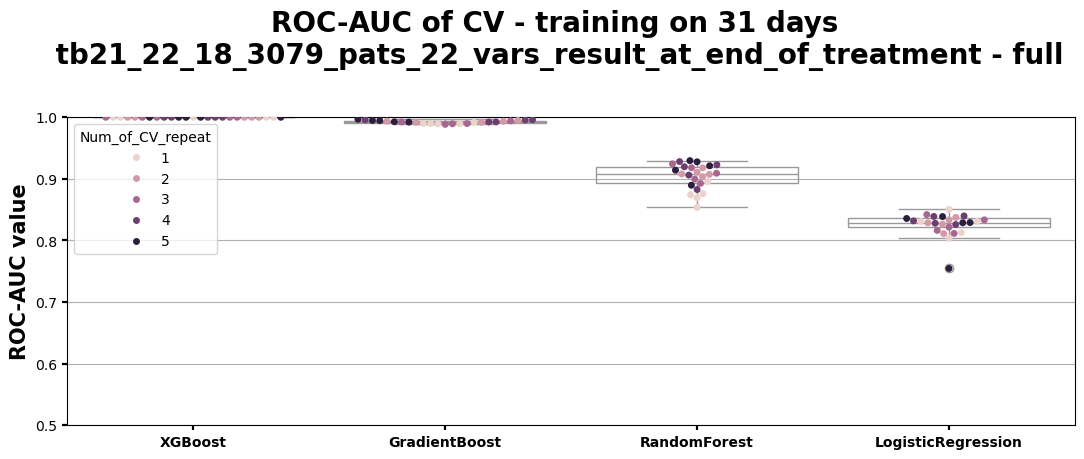

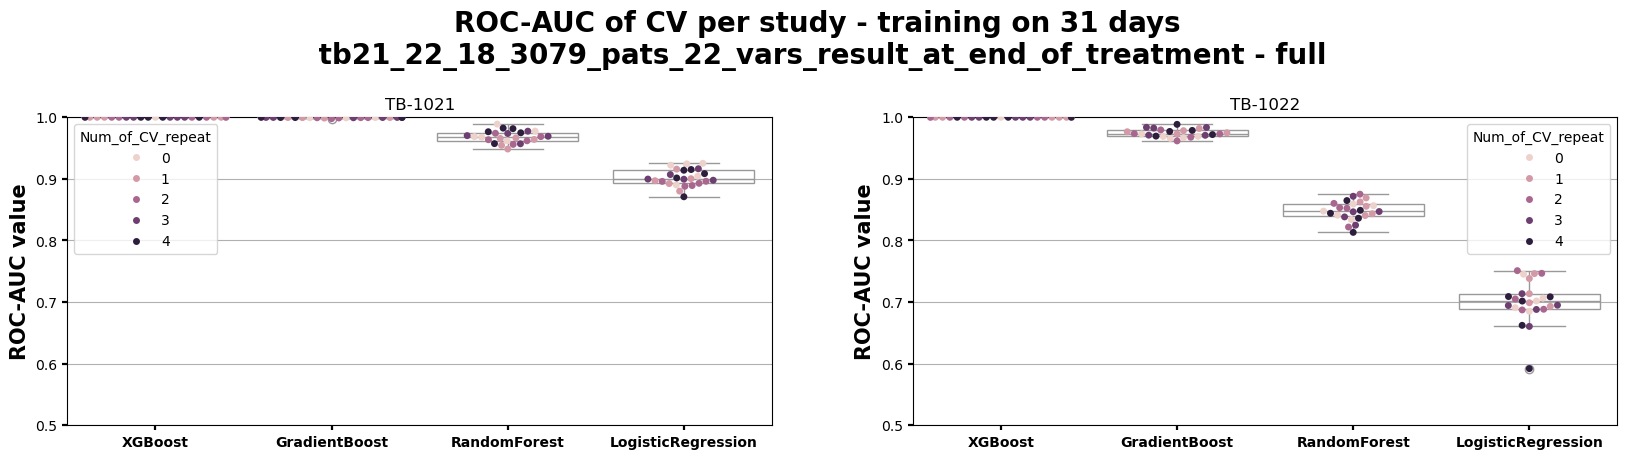

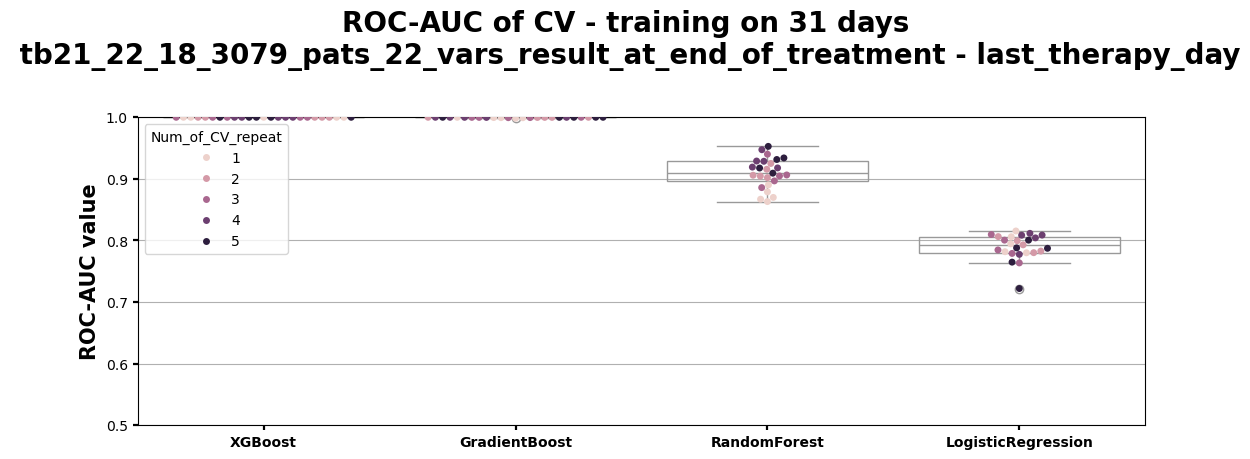

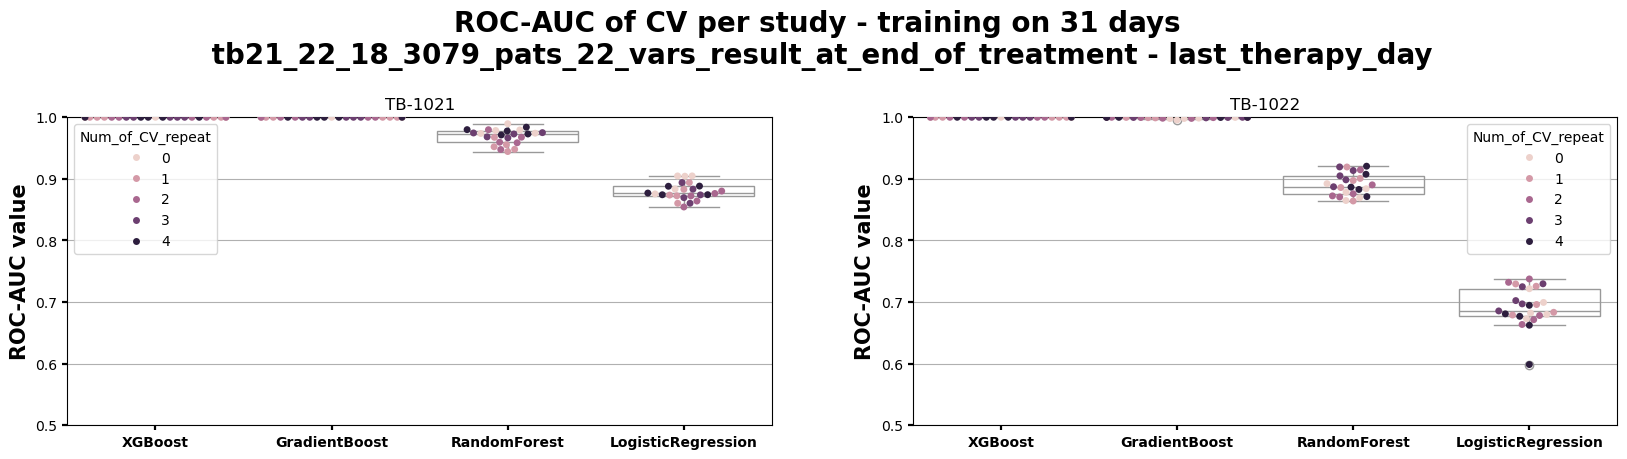

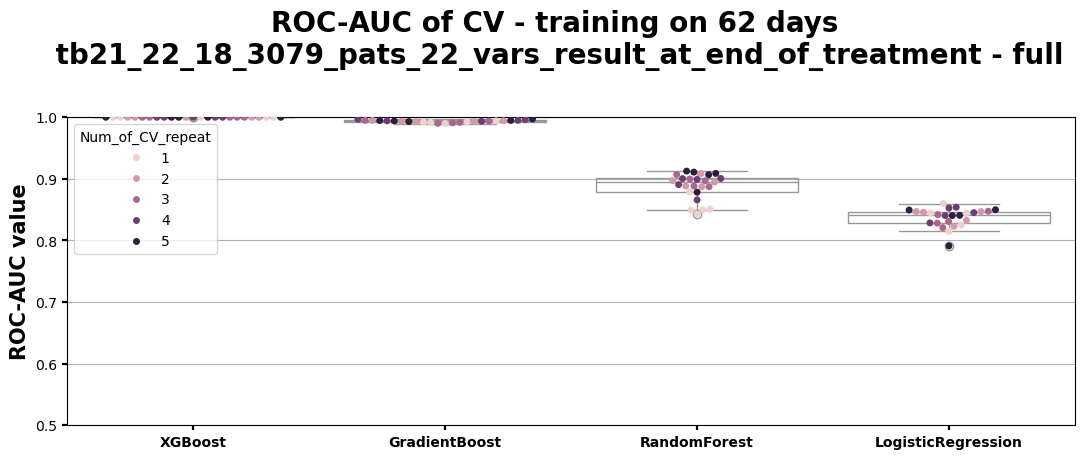

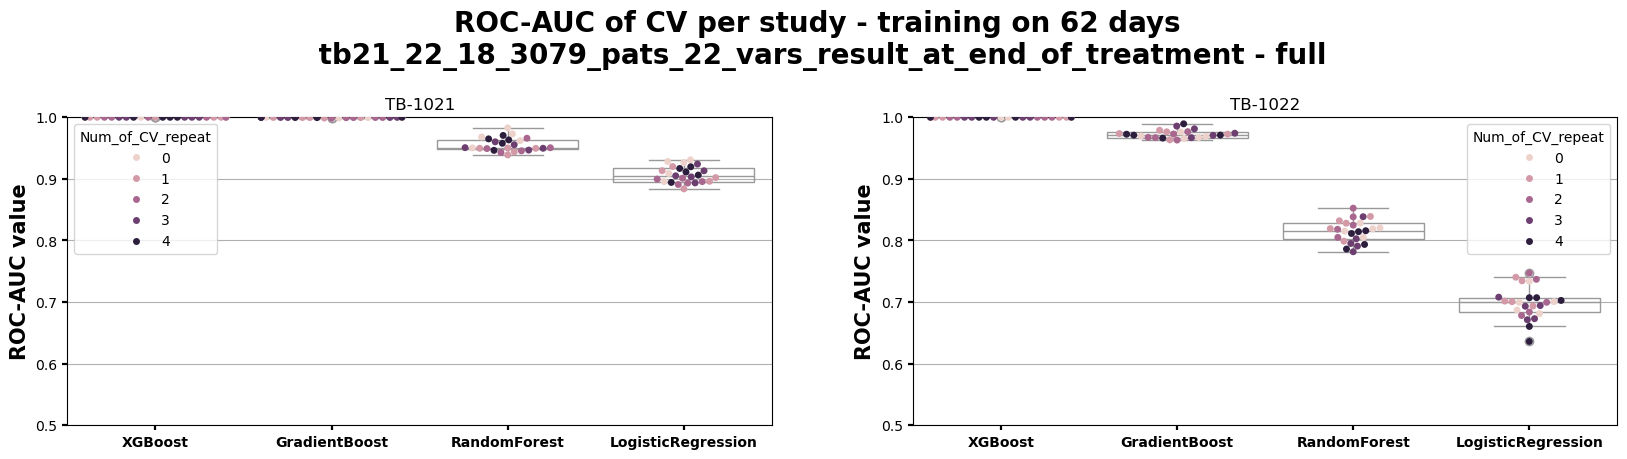

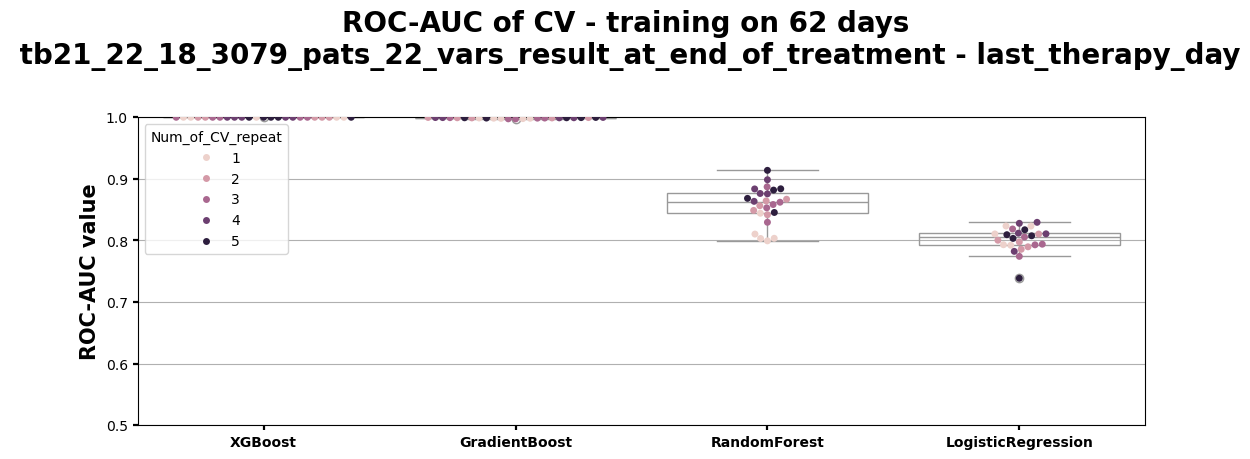

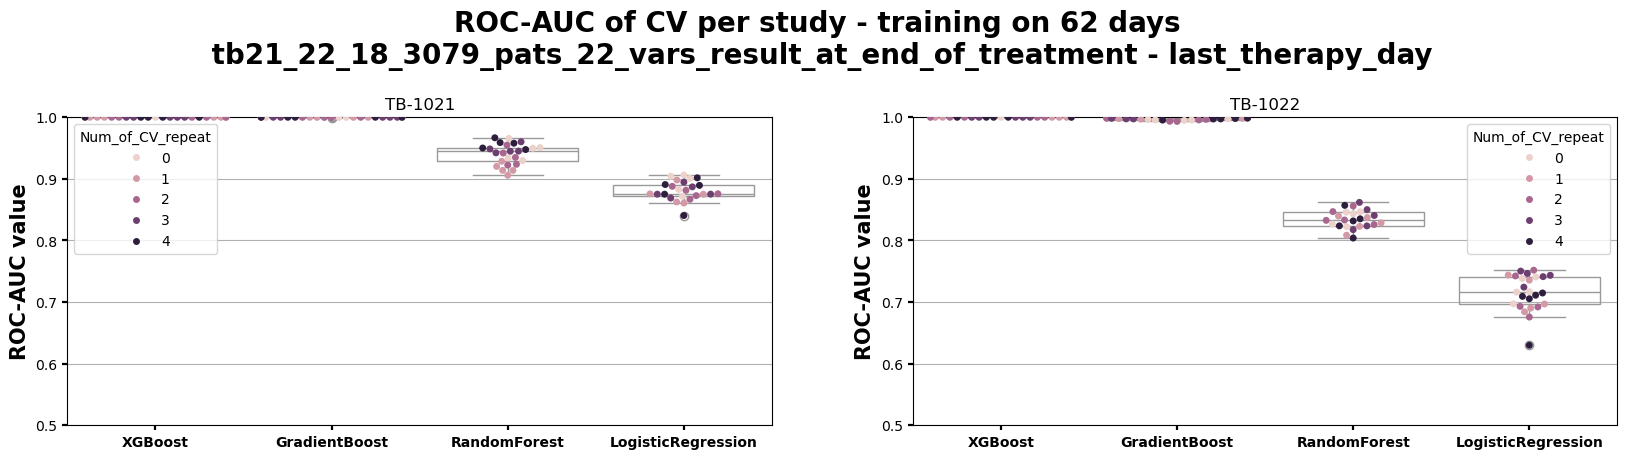

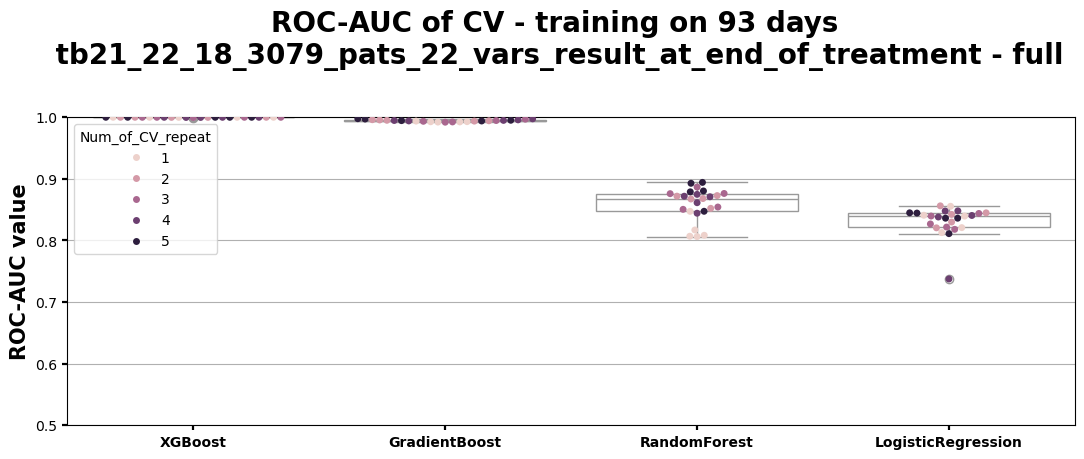

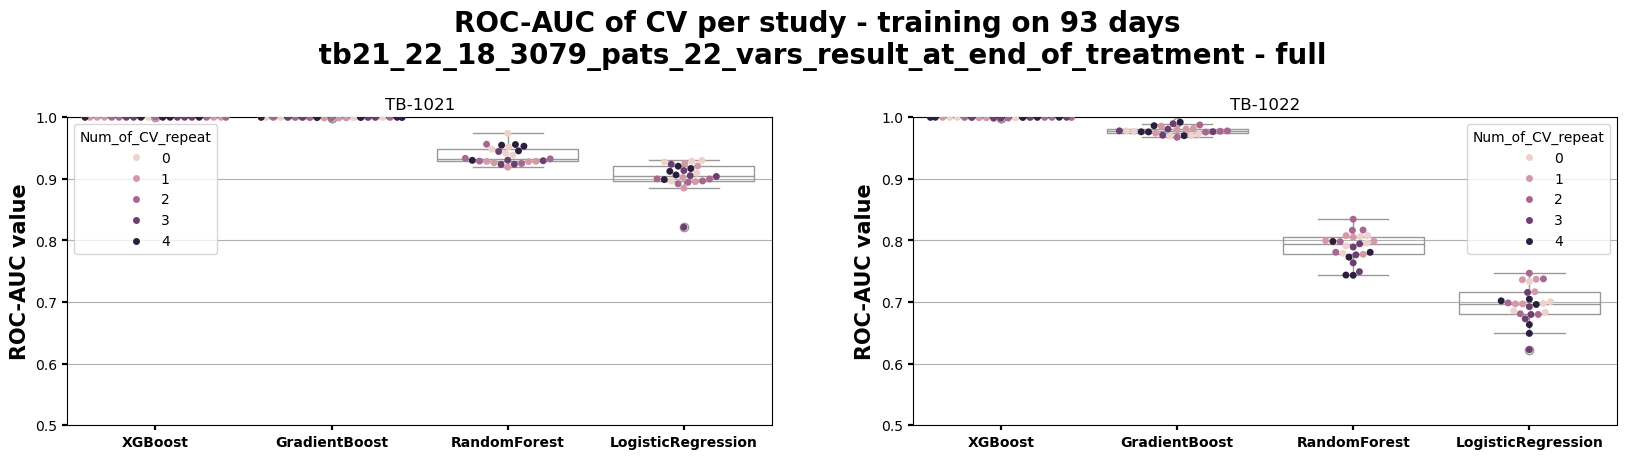

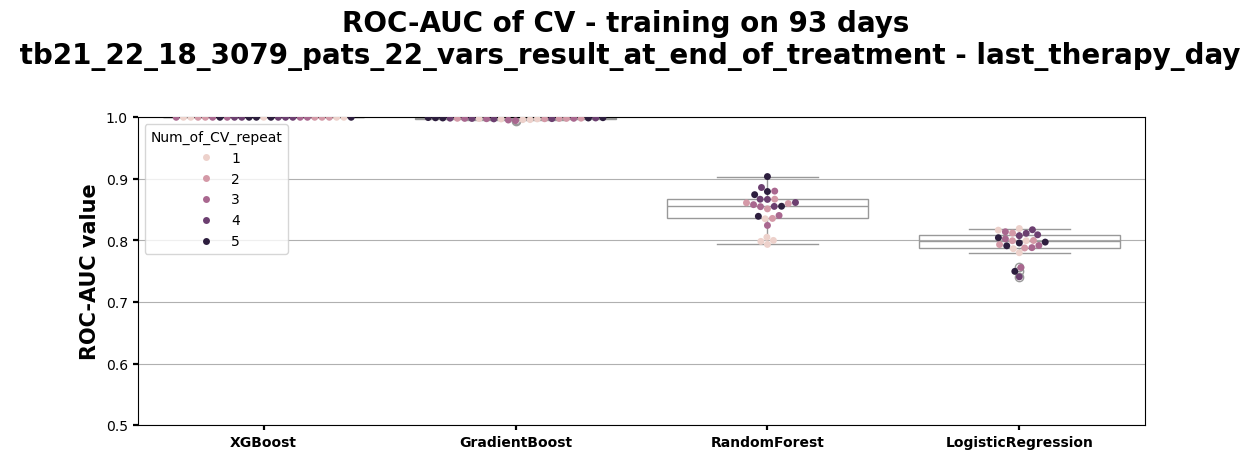

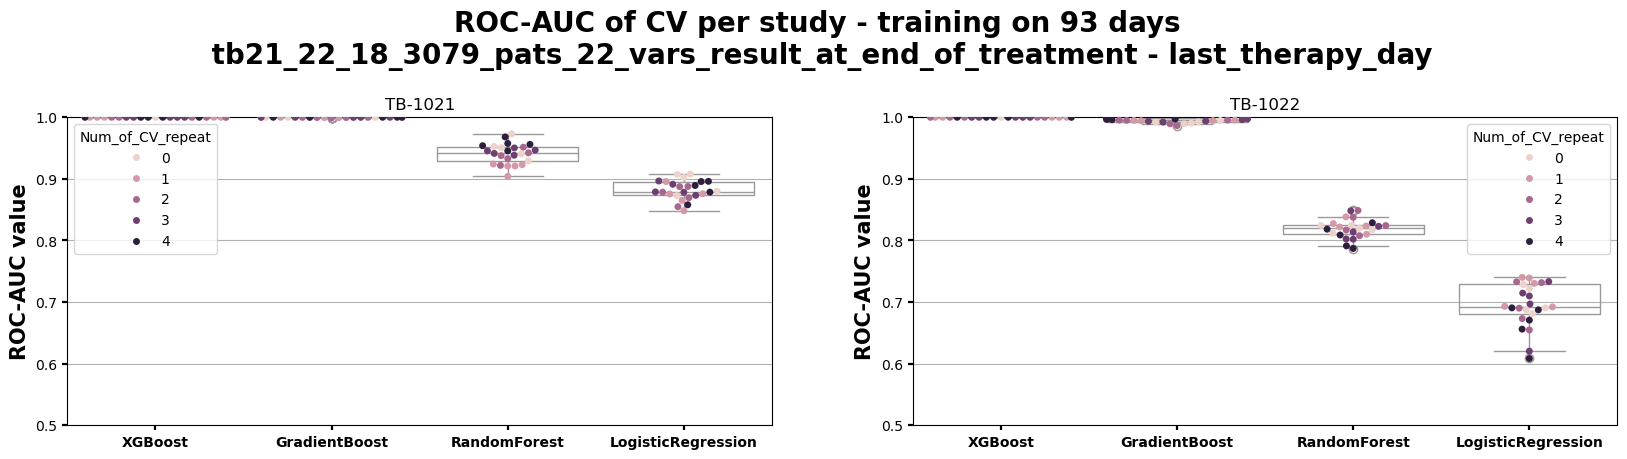

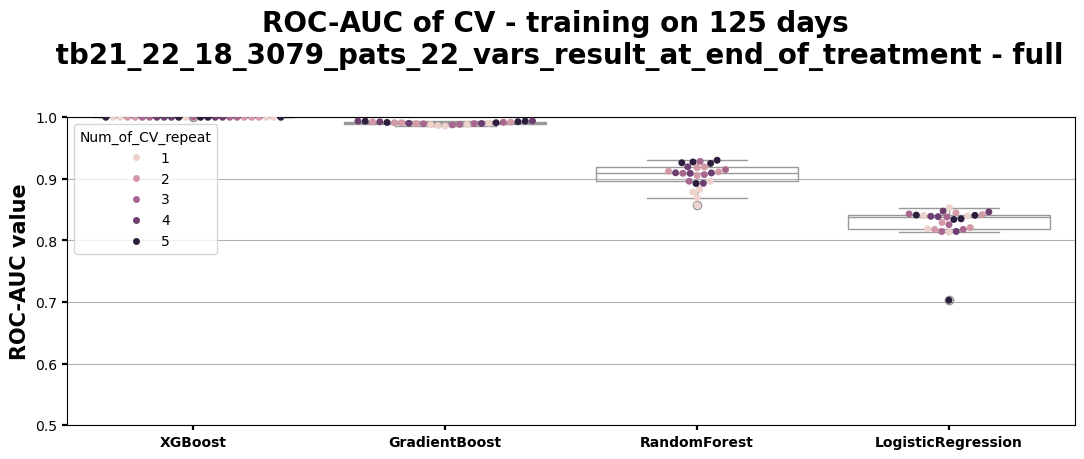

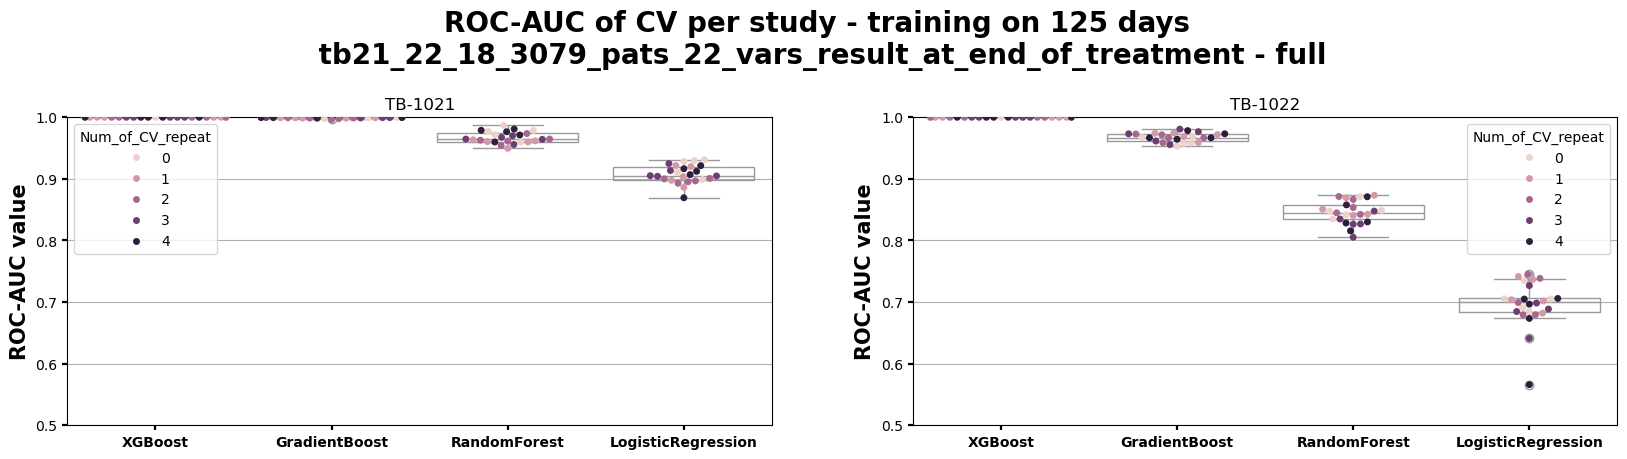

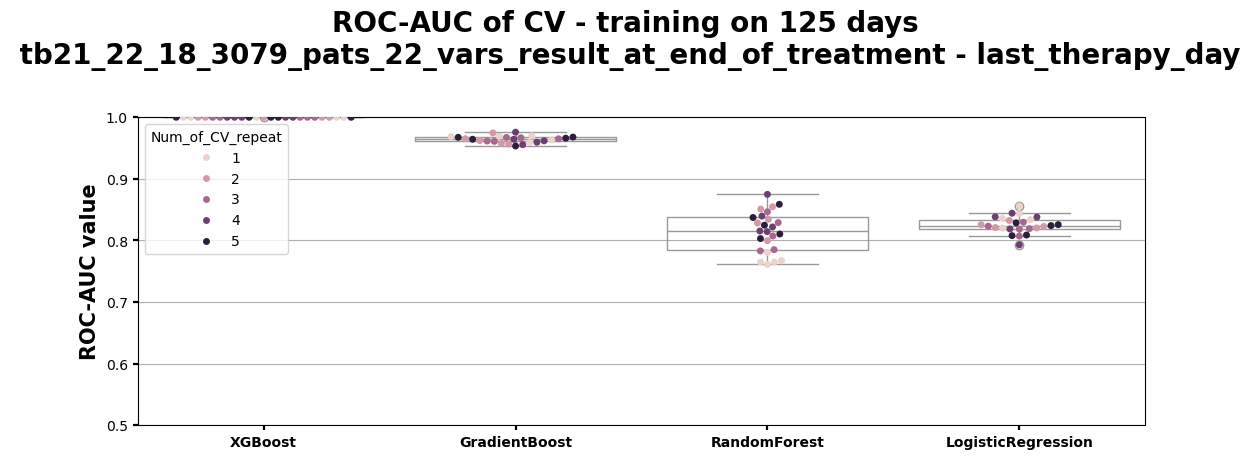

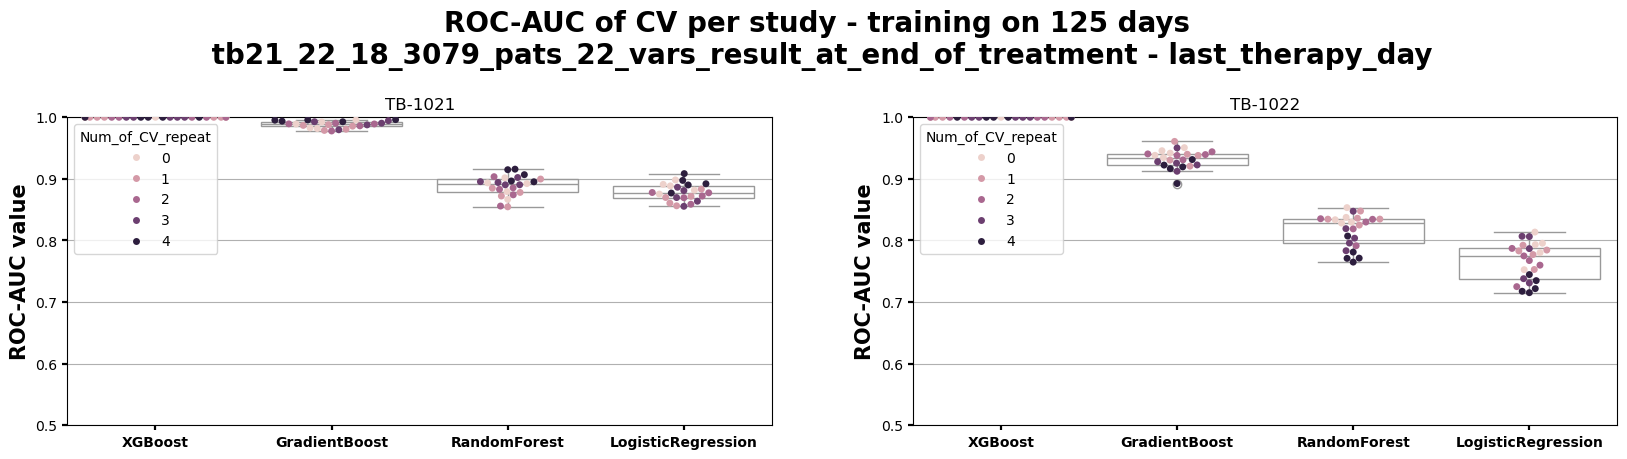

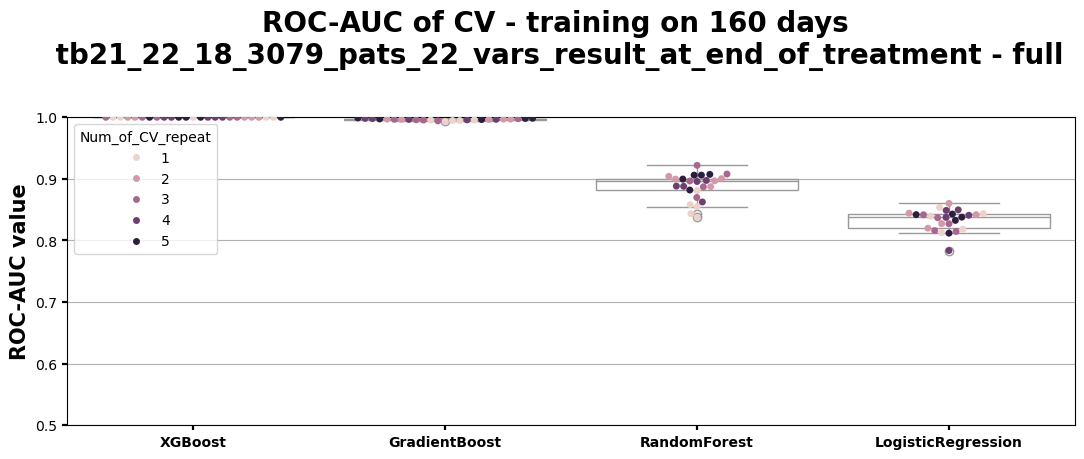

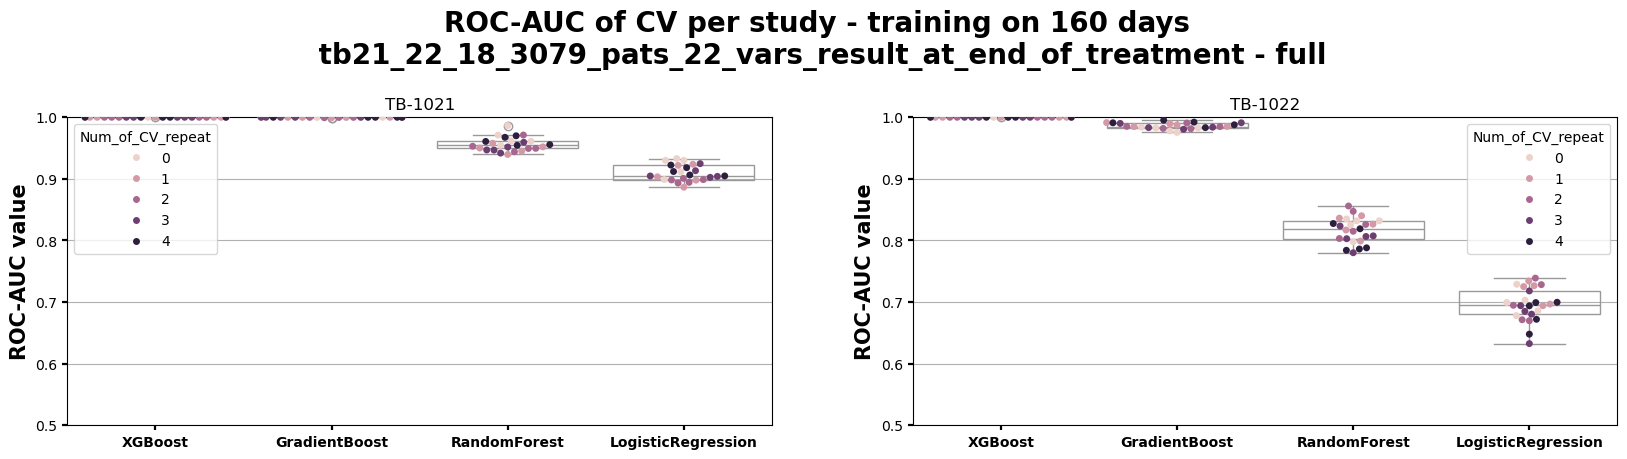

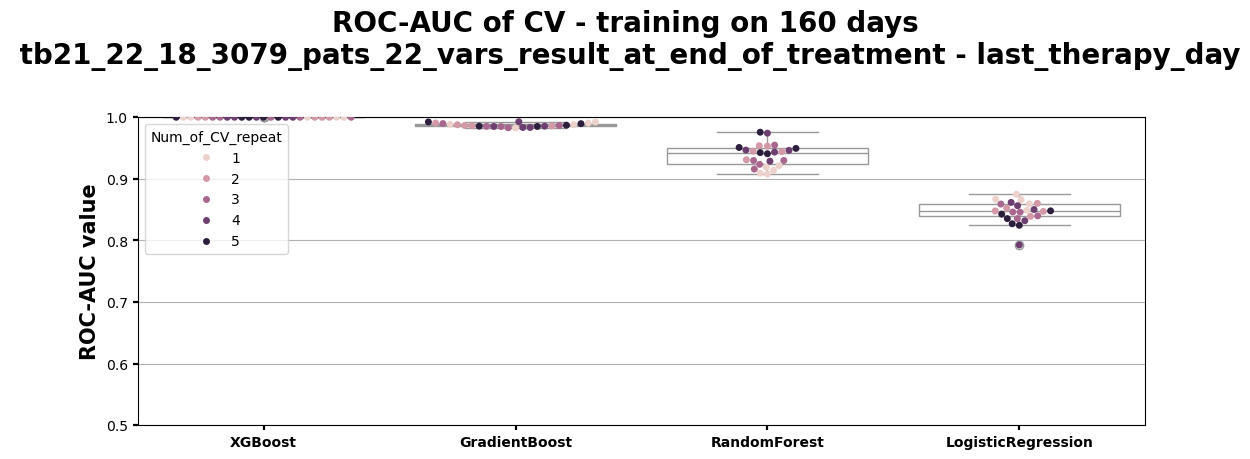

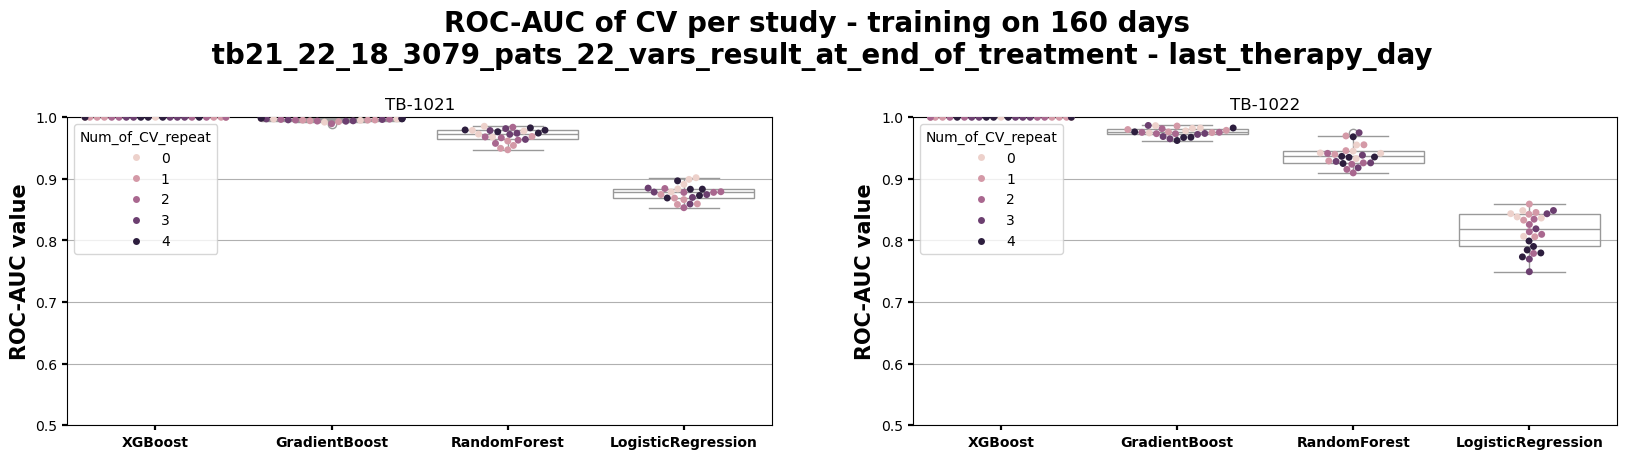

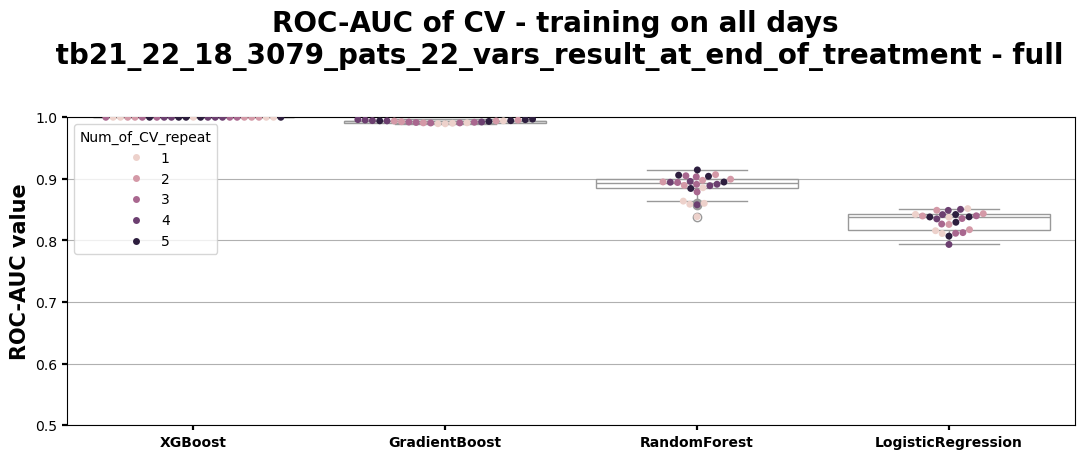

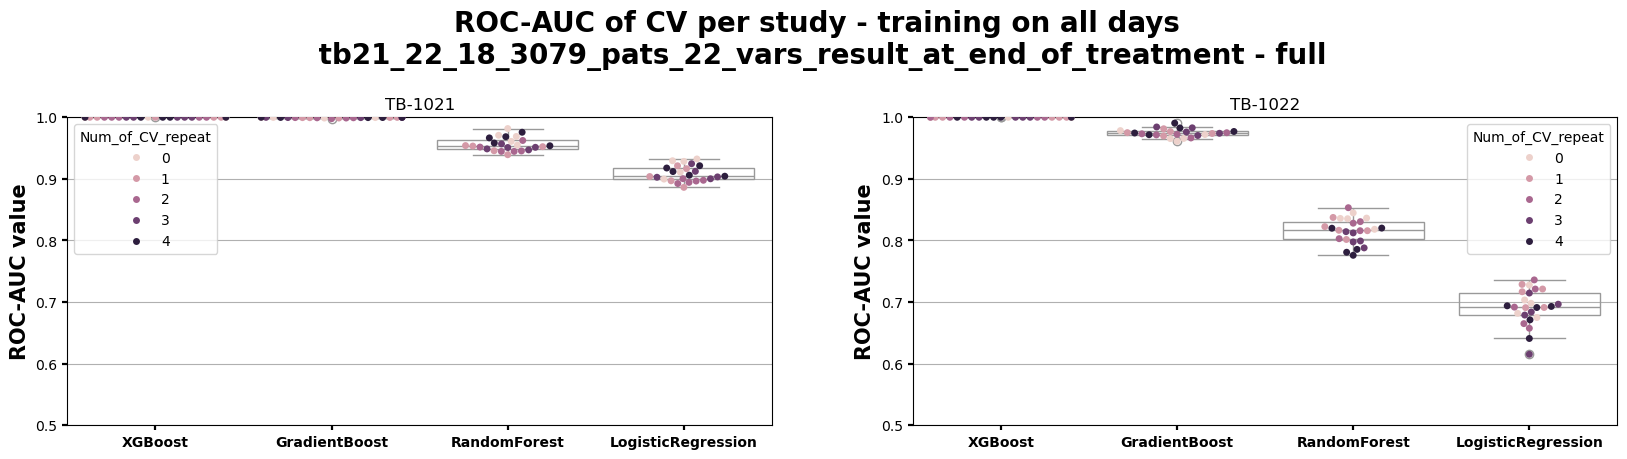

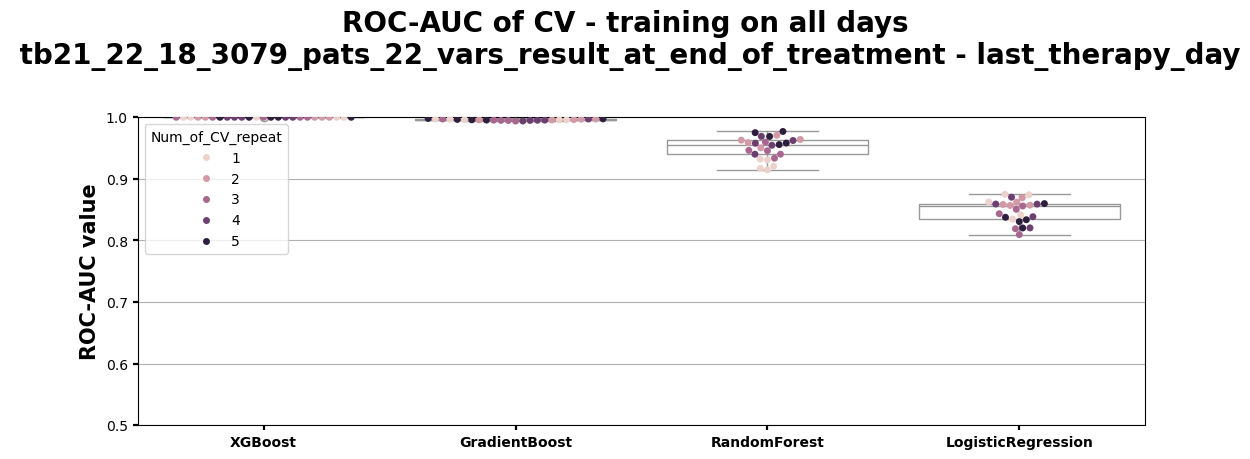

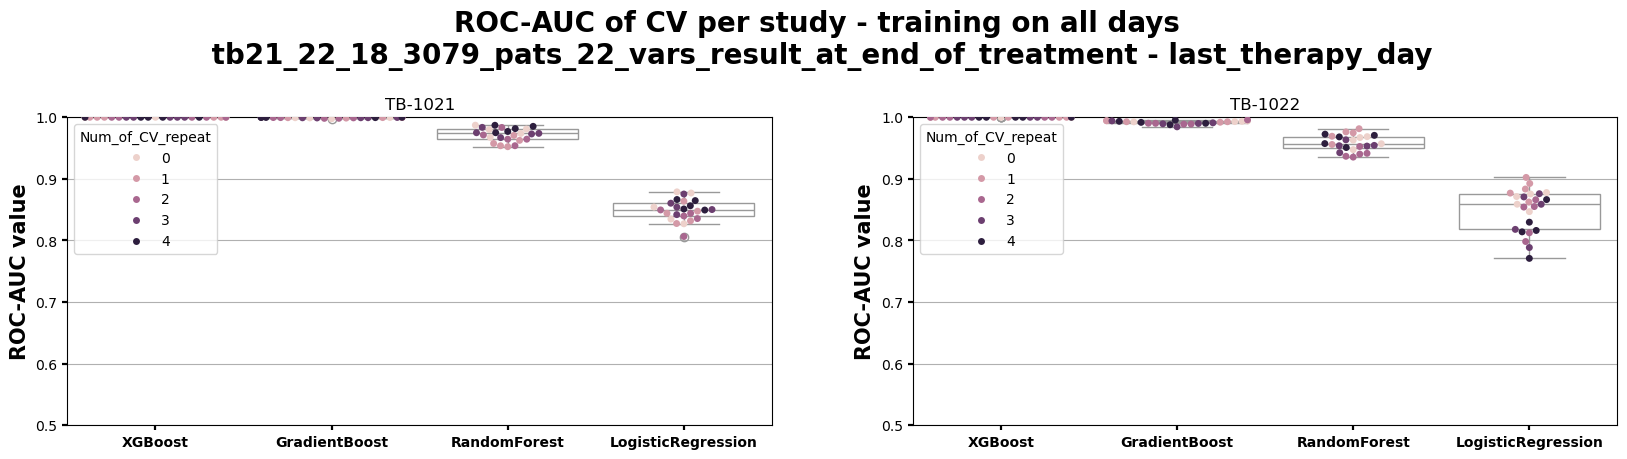

In [5]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


#model_names=['XGBoost','GradientBoost','RandomForest','LogisticRegression','SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:1]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
  

        for training_data_type in training_data_types[:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]
       
            for model_name in model_names[:]:

                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    if 'train_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        train_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['train_score_per_study'].T)
                        train_score_per_study_df['model_name']=model_name
                        train_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        train_score_per_study_df=train_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(train_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)
                       
      
            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
            
            
    

## CV VALIDATION SET ROC-AUC values 

FileNotFoundError: [Errno 2] No such file or directory: '../data/tb21_1405_pats_41_vars_result_at_end_of_treatment_GradientBoost_31_days_full_only_baseline_vars_training_results.pickle'

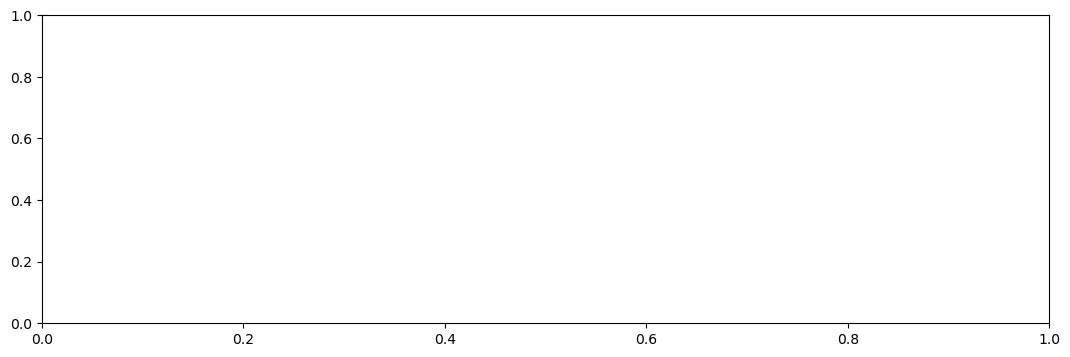

In [4]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][1:2]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:

        for training_data_type in training_data_types[:]:

            fig,ax=plt.subplots(1,1,figsize=(13,4))

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names[:]:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})

            # Calculate mean ROC_AUC_score for each model_name
            mean_scores = cv_res_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

            sns.boxplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
            sns.swarmplot(data=cv_res_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax)


            # Plot mean points
            for i, model in enumerate(model_names):
                mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                max_score = cv_res_df[cv_res_df['model_name'] == model]['ROC_AUC_score'].max()
                ax.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')


            ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
            ax.set_xlabel(None)
            ax.set_xticklabels(model_names, weight='bold')
            #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
            ax.set_ylim(0.5,1) 

            # increase tick width
            ax.tick_params(width=axis_lw)
            ax.yaxis.grid(True) 
            
            
            ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
            if len(scores_per_study_list)>0 and plot_split_by_studies==True:

                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                ncols=len(cv_res_per_study_df['STUDYID'].unique())
                nrows=1
                fig2=plt.figure(figsize=(ncols*10,nrows*4))
                
                for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                    ax2=fig2.add_subplot(nrows,ncols,n+1)
                    plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]
                    
                    # Calculate mean ROC_AUC_score for each model_name
                    mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()
                    
                    sns.boxplot(data=plot_df,x='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                    sns.swarmplot(data=plot_df,x='model_name',y='ROC_AUC_score',hue='Num_of_CV_repeat',ax=ax2)
                    
                    # Plot mean points
                    for i, model in enumerate(model_names):
                        mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                        max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                        ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                    
                    ax2.set_title(studyid)
                    ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                    ax2.set_xlabel(None)
                    ax2.set_xticklabels(model_names, weight='bold')
                    #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                    ax2.set_ylim(0.5,1) 

                    # increase tick width
                    ax2.tick_params(width=axis_lw)
                    ax2.yaxis.grid(True)
                    
                    suptitle=f"ROC-AUC of CV per study - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
                    fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  

            suptitle=f"ROC-AUC of CV - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 
            fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## CV VALIDATION SET ROC-AUC values - across therapy time

/tmp/ipykernel_172011/3289117515.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_172011/3289117515.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_172011/3289117515.py:205: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_172011/3289117515.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
/tmp/ipykernel_172011/3289117515.py:205: U

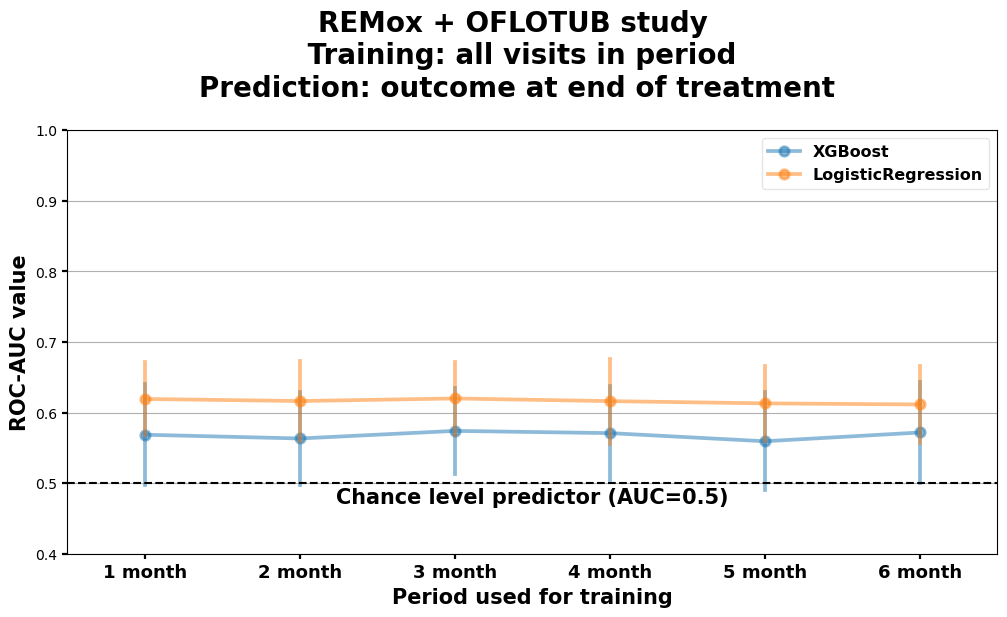

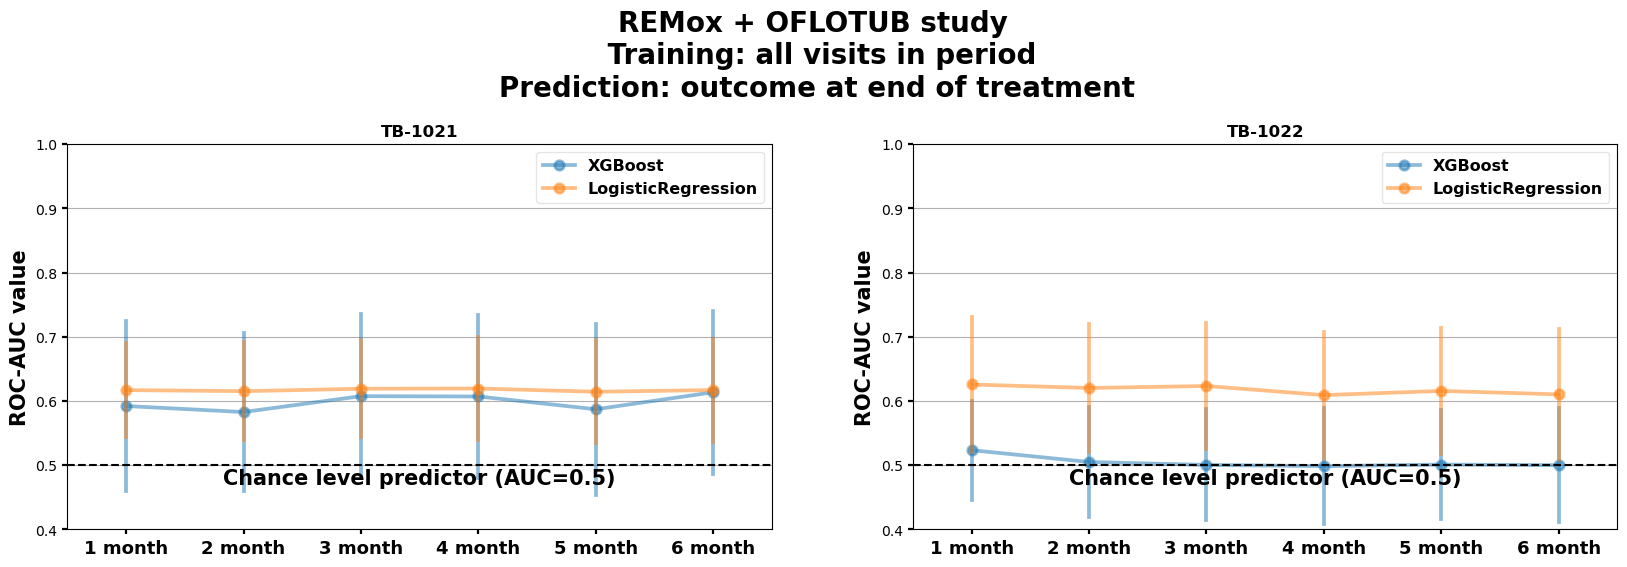

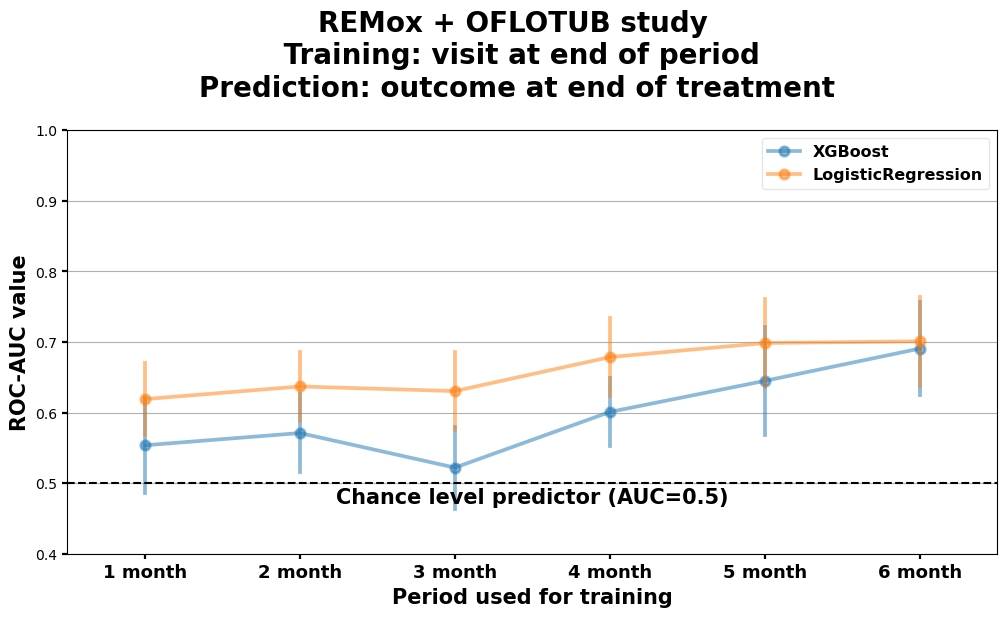

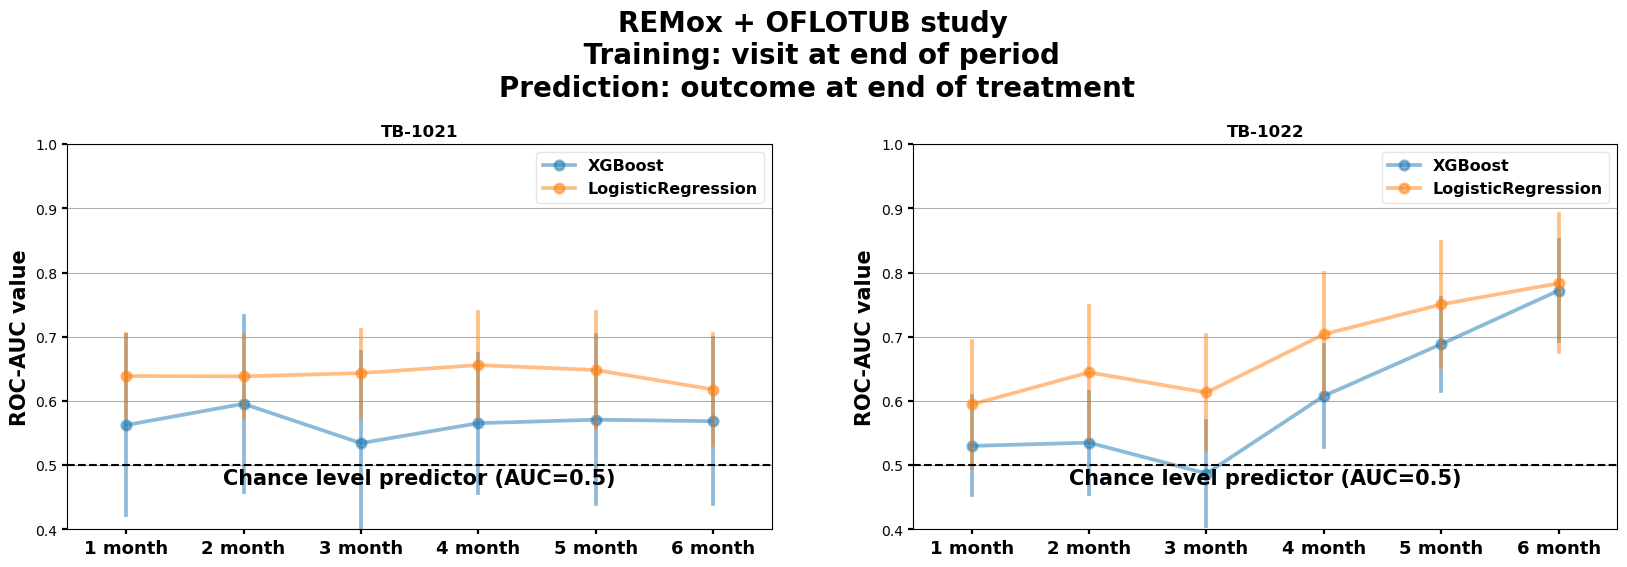

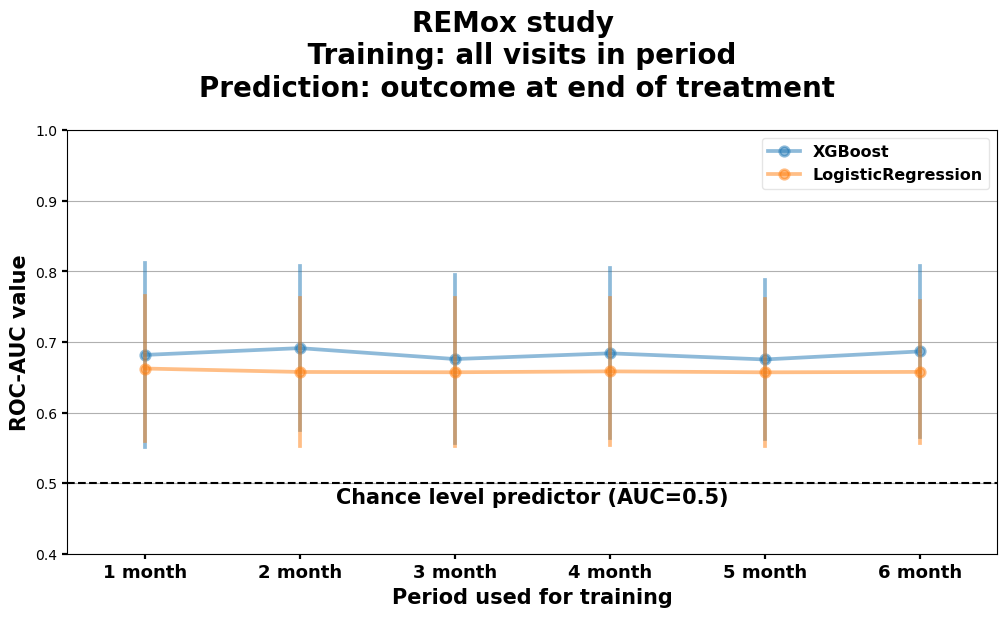

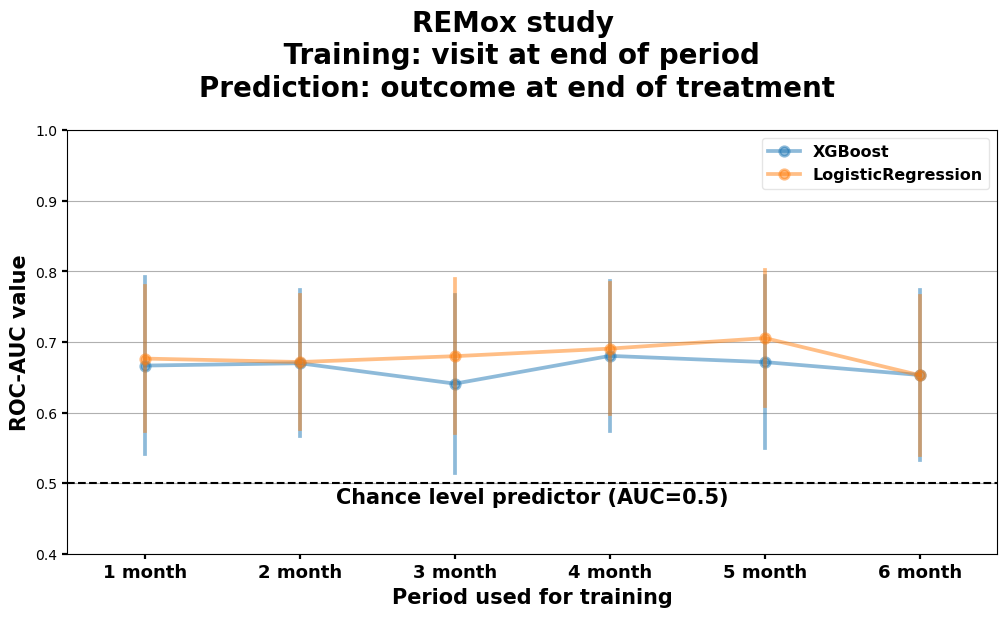

In [6]:
figtitle_size=20
subtitle_size=18
x_tick_size=13
y_tick_size=13
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

suptitle_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in period',
                             'last_therapy_day':'visit at end of period'}


model_names=['XGBoost','GradientBoost','LogisticRegression','RandomForest']#,'SVC']#,'KNN']
#model_names=['LogisticRegression']
training_data_types=['full','last_therapy_day']
plot_split_by_studies=True

model_names_for_plot=['XGBoost','LogisticRegression']
#model_names_for_plot=['XGBoost','GradientBoost','LogisticRegression','RandomForest']
period_end_days_for_plot=period_end_days[:]


### loop over ML models, train them & training results in a dictionary
for data_param_key in [*parameters_for_analysis][:2]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    pat_ids=X['USUBJID'].unique().tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for training_data_type in training_data_types[:]:
        
        cv_res_df_list,cv_res_df_per_study_list=[],[]
        
        fig,ax=plt.subplots(1,1,figsize=(12,5.5))
        
        for period_end_day in period_end_days_for_plot:

            scores,cv_num_list,model_name_list,scores_per_study_list=[],[],[],[]

            for model_name in model_names_for_plot:


                #fn=f'../data/{data_param_key}_{model_name}_{training_data_type}_training_results.pickle'
                #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):
                    cv_roc_auc_scores=cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score']
                    scores.extend(cv_roc_auc_scores)
                    cv_num_list.extend([cv_repeat_num+1,]*len(cv_roc_auc_scores))
                    model_name_list.extend([model_name,]*len(cv_roc_auc_scores))
                    
                    
                    if 'test_score_per_study' in cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores'].keys():
                        test_score_per_study_df=pd.melt(cv_results[f'cv_rep_{cv_repeat_num}']['cv_roc_auc_scores']['test_score_per_study'].T)
                        test_score_per_study_df['model_name']=model_name
                        test_score_per_study_df['Num_of_CV_repeat']=cv_repeat_num
                        test_score_per_study_df['inclusion_period']=period_end_day
                        test_score_per_study_df=test_score_per_study_df.rename(columns={'value':'ROC_AUC_score'})
                        
                        scores_per_study_list.append(test_score_per_study_df)


            ## Collect CV-results where ROC-AUC was calculated across all studies
            cv_res_df=pd.DataFrame.from_dict({'model_name':model_name_list,'Num_of_CV_repeat':cv_num_list,'ROC_AUC_score':scores})
            cv_res_df['inclusion_period']=period_end_day
            cv_res_df_list.append(cv_res_df)
            
            ## 
            if len(scores_per_study_list)>0:
                cv_res_per_study_df=pd.concat(scores_per_study_list,axis=0)
                cv_res_df_per_study_list.append(cv_res_per_study_df)
                
        cv_res_acros_time_df=pd.concat(cv_res_df_list,axis=0)
        #print(period_end_day,training_data_type,'\n',cv_res_acros_time_df,'\n========')
        
        
        
        # Calculate mean ROC_AUC_score for each model_name
        mean_scores = cv_res_acros_time_df.groupby(['inclusion_period','model_name'])['ROC_AUC_score'].median().reset_index()

        #sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,color='white',boxprops={'fill': None})
        #bp=sns.boxplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,boxprops={'fill': None},legend=None)
        #sns.stripplot(data=cv_res_acros_time_df, x='inclusion_period', hue='model_name', y='ROC_AUC_score', ax=ax, #color='black',
        #              size=6, jitter=0, alpha=1, dodge=False)
        
        sns.pointplot(data=cv_res_acros_time_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax,
                      errorbar='sd',alpha=0.5)
        

       
        '''
        # Set manual offsets depending on the number of models and the seaborn plot spacing
        offsets = np.linspace(-0.30, 0.30, num=len(model_names))  # Adjust this based on the number of models

        for j, period in enumerate(period_end_days[:4]):
            group_data = cv_res_acros_time_df[cv_res_acros_time_df['inclusion_period'] == period]
            for i, model in enumerate(model_names_for_plot):
                median_score = mean_scores.loc[(mean_scores['model_name'] == model) & (mean_scores['inclusion_period'] == period), 'ROC_AUC_score'].values[0]
                max_score = group_data[group_data['model_name'] == model]['ROC_AUC_score'].max()
                # Calculate position
                position = j + offsets[i]  # shift each model within its group
                ax.text(position, max_score + 0.005, f'Median:\n{median_score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        '''
        
        ax.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
        ax.set_xlabel('Period used for training',fontsize=y_label_size,fontweight='bold')
        
        ## Convert days to months for xticklabels
        xticklabels=[f'{int(np.floor(int(day)/30))} month' if day !='all' else '6 month' for day in period_end_days_for_plot]
        ax.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
        #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
        ax.set_ylim(0.4,1) 

        # increase tick width
        ax.tick_params(width=axis_lw)
        ax.yaxis.grid(True) 
        
        ## PLot chance predicor's line at 0.5
        ax.axhline(y=0.5,color='black', linestyle='dashed')
        range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
        ax.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                            rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')
        
        ## Remove legend title

        # Adjust legend: changing font size and handle size
        h, l = ax.get_legend_handles_labels()
        legend = ax.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)
        
        ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})
        
        # Adjust the legend's title font weight to bold
        #plt.setp(legend.get_title(), fontweight='bold')
        # You can adjust handle size like this, making them larger
        #for handle in legend.legendHandles:
        #    handle.set_linewidth(4)  # Set the handle width

        
        if data_param_key in suptitle_dict.keys():
            study_names=suptitle_dict[data_param_key]
            prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
            train_ds_type=suptitle_training_type_dict[training_data_type]
            suptitle= f"{study_names} study \n Training: {train_ds_type}\nPrediction: outcome at {prediction_time}"
            
        else:   
            suptitle=f"ROC-AUC of CV - {data_param_key} - {training_data_type}" 
            
        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.1)  
        
        
        
        ## IF THERE ARE AUC-ROC VALUES PER STUDY AVAILABLE, PLOT HEM IN A SEPERATE BOXPLOT
        if len(scores_per_study_list)>0 and plot_split_by_studies==True:

            cv_res_per_study_df=pd.concat(cv_res_df_per_study_list,axis=0)
            ncols=len(cv_res_per_study_df['STUDYID'].unique())
            nrows=1
            fig2=plt.figure(figsize=(ncols*10,nrows*5))

            for n,studyid in enumerate(cv_res_per_study_df['STUDYID'].unique()):
                ax2=fig2.add_subplot(nrows,ncols,n+1)
                plot_df=cv_res_per_study_df[cv_res_per_study_df['STUDYID']==studyid]

                # Calculate mean ROC_AUC_score for each model_name
                mean_scores=plot_df.groupby('model_name')['ROC_AUC_score'].median().reset_index()

                #sns.boxplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,color='white',boxprops={'fill': None})
                #sns.swarmplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2)
                sns.pointplot(data=plot_df,x='inclusion_period',hue='model_name',y='ROC_AUC_score',ax=ax2,
                      errorbar='sd',alpha=0.5)
                
                '''
                # Plot mean points
                for i, model in enumerate(model_names):
                    mean_score = mean_scores.loc[mean_scores['model_name'] == model, 'ROC_AUC_score'].values[0]
                    max_score = plot_df[plot_df['model_name'] == model]['ROC_AUC_score'].max()
                    ax2.text(i, max_score+0.005, f'Median: {mean_score:.3f}', ha='center', va='bottom', fontsize=10,fontweight='bold')
                '''

                ax2.set_title(studyid,fontweight='bold')
                ax2.set_ylabel('ROC-AUC value',fontsize=y_label_size,fontweight='bold')
                ax2.set_xlabel(None)
                ax2.set_xticklabels(xticklabels, weight='bold',fontsize=x_tick_size)
                #ax.set_title(f"{'_'.join([llm_model_name,fine_tuned_tag])} - Test set ROC-AUC")
                ax2.set_ylim(0.4,1) 

                # increase tick width
                ax2.tick_params(width=axis_lw)
                ax2.yaxis.grid(True)
                
                ## PLot chance predicor's line at 0.5
                ax2.axhline(y=0.5,color='black', linestyle='dashed')
                range_mean=(ax.get_xlim()[1]+ ax.get_xlim()[0])/2
                ax2.text(range_mean,0.48,'Chance level predictor (AUC=0.5)',fontsize=y_label_size,fontweight='bold',
                                    rotation=0,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                ## Remove legend title

                # Adjust legend: changing font size and handle size
                h, l = ax2.get_legend_handles_labels()
                legend = ax2.legend(h, l, title='Models', loc='best',title_fontsize=12,handlelength=2)

                ax2.legend(h,l,frameon=True,framealpha=0.5,
                                    prop={'weight':'bold','size':legend_fontsize})

                fig2.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=1.15)  
    
            
            
    

## ROC-AUC curve of test set

In [ ]:
columns_to_drop

In [ ]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


for data_param_key in [*parameters_for_analysis][:2]:
    
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        


    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[:]:


            ncols=train_params['num_cv_repeats']
            fig,axes=plt.subplots(1,ncols,figsize=(ncols*8,12))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                      columns_to_drop_)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']

                    ## Calculate label weights mapped to the test labels for RocCurveDisplay
                    if training_results['train_params']['weight_by_label_freq']==True:

                        label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                        label_weights=y_test[outcome_label].map(label_weights_dict).values

                    if training_results['train_params']['weight_by_label_freq']==False:
                        label_weights=None   

                    if len([*cv_results])==1:
                        ax=axes
                    else:    
                        ax=axes[cv_repeat_num]


                    rfc_disp=RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name,
                                                                            sample_weight=label_weights,alpha=0.8)  

                    ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                    ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                    ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                    ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                    ax.set_title(' - '.join(['CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                    ## Plot diagonal chance level predictor curve + customize legend
                    ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                    ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                            rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                    h, l = ax.get_legend_handles_labels()
                    ax.legend(h,l,frameon=True,framealpha=0.5,
                            prop={'weight':'bold','size':legend_fontsize})

                    ## Change linewidth of axes
                    for axis in ['top','bottom','left','right']:
                        ax.spines[axis].set_linewidth(axis_lw)

                    # increase tick width
                    ax.tick_params(width=axis_lw)

                    suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                    suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                    fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.87)  
                    ax.grid(True)        


## ROC-AUC curve of test set - split by study

In [ ]:

for data_param_key in [*parameters_for_analysis][:1]:
    

    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[1:2]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()


        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)

        for training_data_type in training_data_types[:]:


            ncols=train_params['num_cv_repeats']
            nrows=len(X['STUDYID'].unique())
            fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*7,nrows*7.5),constrained_layout=False)
            #fig=plt.figure(figsize=(ncols*6,nrows*4))

            for model_name in model_names[:]:

                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']


                for cv_repeat_num in range(len([*cv_results])):

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop=columns_to_drop + X.columns[X.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                       columns_to_drop=[])
                    #fig2,ax2=plt.subplots() 
                    #X_subset.loc[X_subset['USUBJID'].isin(X_test_pat_ids),'DAY'].hist(bins=50,ax=ax2)

                    #X_test_pat_ids=cv_results[f'cv_rep_{cv_repeat_num}']['X_test_pat_ids']
                    #X_test=X.loc[X['USUBJID'].isin(X_test_pat_ids),:]
                    #y_test=y.loc[X_test['USUBJID'].tolist()]

                    #X_test=X_test.drop(columns=columns_to_drop)

                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']


                    for l,studyid in enumerate(X_subset['STUDYID'].unique()):                                  

                        if len([*cv_results])==1:
                            ax=axes[l]
                        else:    
                            ax=axes[l,cv_repeat_num]

                        #ax=fig.add_subplot(nrows,ncols,l+1)
                        X_study_mask=X_test.loc[X_test['STUDYID']==studyid,:]
                        y_study_mask=y_test.loc[X_study_mask['USUBJID'].unique().tolist()]
                        X_study_mask=X_study_mask.drop(columns=columns_to_drop)

                        ## Calculate label weights mapped to the test labels for RocCurveDisplay
                        if training_results['train_params']['weight_by_label_freq']==True:

                            label_weights_dict=cv_results[f'cv_rep_{cv_repeat_num}']['label_weights_dict'] 
                            label_weights=y_study_mask[outcome_label].map(label_weights_dict).values

                        if training_results['train_params']['weight_by_label_freq']==False:
                            label_weights=None   


                        
                        rfc_disp=RocCurveDisplay.from_estimator(model, X_study_mask, y_study_mask, ax=ax, name=model_name,
                                                                                sample_weight=label_weights,alpha=0.8)  

                        ax.set_ylabel('True Positive Rate',fontsize=y_label_size,fontweight='bold')
                        ax.set_xlabel('False Positive Rate',fontsize=y_label_size,fontweight='bold')

                        ax.tick_params(axis='y', labelsize=y_label_size*0.8)
                        ax.tick_params(axis='x', labelsize=y_label_size*0.8)

                        ax.set_title(' - '.join([studyid,'CV-split',str(cv_repeat_num+1)]),fontsize=subtitle_size,fontweight='bold')

                        ## Plot diagonal chance level predictor curve + customize legend
                        ax.plot([0,1], [0,1],color='black', linestyle='dashed')
                        ax.text(0.5,0.55,'Chance level predictor (AUC=0.5)',fontsize=y_label_size*0.8,fontweight='bold',
                                rotation=45,horizontalalignment='center', verticalalignment='center',rotation_mode='default')

                        h, l = ax.get_legend_handles_labels()
                        ax.legend(h,l,frameon=True,framealpha=0.5,
                                prop={'weight':'bold','size':legend_fontsize})

                        ## Change linewidth of axes
                        for axis in ['top','bottom','left','right']:
                            ax.spines[axis].set_linewidth(axis_lw)

                        # increase tick width
                        ax.tick_params(width=axis_lw)

                        plt.subplots_adjust(wspace=0.25)

                        #suptitle=f"ROC curve of test data\n {data_param_key} - {training_data_type}" 
                        suptitle=f"ROC curve of test data - training on {period_end_day} days\n {data_param_key} - {training_data_type}" 

                        fig.suptitle(suptitle,fontsize=figtitle_size,fontweight='bold',y=0.95)  
                        ax.grid(True)        

                    ## Print distribution of labels per study
                    df=y_test.reset_index()#
                    df['STUDYID']=df['USUBJID'].str.split('/',expand=True)[0].values
                    #print(pd.crosstab(df['STUDYID'],df[outcome_label]))

#plt.tight_layout()


# FEATURE IMPORTANCE: SHAP-VALUES

## Calculate SHAP-values

In [8]:

### CALCULATE SHAP-SCORES (FEATURE IMPORTANCE) ####
def calculate_shap_values(X_train,X_test,model,model_name):
    import shap
    
    #importances_dict[training_method][train_ds_type+'_train_data'][model_type_name]={}

    if model_name in ['RandomForest','GradientBoost','XGBoost']:
        explainer=shap.TreeExplainer(model,data=X_train)
        shap_values=explainer(X_test)

    elif model_name in ['LogisticRegression','Lasso','Ridge','ElasticNet']:
        explainer=shap.LinearExplainer(model,data=X_train,masker=shap.maskers.Impute(data=X_train))
        shap_values=explainer(X_test)

    elif model_name in ['DenseNetwork']:
        explainer=shap.DeepExplainer(model,data=torch.tensor(X_train.values,dtype=torch.float32))
        shap_values=explainer.shap_values(torch.tensor(X_test.values,dtype=torch.float32))
        
    elif model_name in ['SVR','KNN']:
        explainer=shap.KernelExplainer(model.predict, data=shap.kmeans(X_train, 1),
                                        masker=shap.maskers.Independent(X_train, max_samples=100))
        shap_values=explainer.shap_values(X_test)                                                       

    return shap_values

In [9]:
figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6

model_names=['XGBoost','LogisticRegression']

for data_param_key in [*parameters_for_analysis][:2]:
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        

    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()

       ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
        
        for training_data_type in training_data_types[1:]:
            print(f'Running training with {training_data_type} model')


            for model_name in model_names[:]:
                
                
                #fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_training_results.pickle'
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']

                
                for cv_repeat_num in range(len([*cv_results])):
                    print(f'Calculating SHAP-values for model {model_name},CV-repeat number:{cv_repeat_num}')

                    ## Based on the saved random state used at training, re-create the train-test data split
                    rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                    if len(columns_to_drop)>0:
                        columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                        ## If colunm name is in the temp_cols_to_keep list, don't drop it
                        columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]

                    X_train,X_test,y_train,y_test,\
                        X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                      train_params['test_size_ratio'],
                                                                                      rand_state,training_data_type,
                                                                                      columns_to_drop_)


                    model=cv_results[f'cv_rep_{cv_repeat_num}']['model']
                    
                    shap_values=calculate_shap_values(X_train,X_test,model,model_name)
                    #print(X_test.shape,shap_values.shape)
                    
                    cv_results[f'cv_rep_{cv_repeat_num}']['shap_values']=shap_values
       

                training_results['cv_results']=cv_results
        
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'wb') as handle:
                    pickle.dump(training_results, handle)
        


tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment
Period: 31 days
Running training with last_therapy_day model
Calculating SHAP-values for model XGBoost,CV-repeat number:0
(731, 268) (731, 268)
Calculating SHAP-values for model XGBoost,CV-repeat number:1
(726, 268) (726, 268)
Calculating SHAP-values for model XGBoost,CV-repeat number:2
(732, 268) (732, 268)
Calculating SHAP-values for model XGBoost,CV-repeat number:3
(734, 268) (734, 268)
Calculating SHAP-values for model XGBoost,CV-repeat number:4
(730, 268) (730, 268)
Calculating SHAP-values for model LogisticRegression,CV-repeat number:0


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

(731, 268) (731, 268)
Calculating SHAP-values for model LogisticRegression,CV-repeat number:1


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

(726, 268) (726, 268)
Calculating SHAP-values for model LogisticRegression,CV-repeat number:2


...

(349, 255) (349, 255)
Calculating SHAP-values for model LogisticRegression,CV-repeat number:3


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

(349, 255) (349, 255)
Calculating SHAP-values for model LogisticRegression,CV-repeat number:4


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

(349, 255) (349, 255)


## Plot absolute SHAP-values

tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment
Period: 62 days
last_therapy_day model
Loading SHAP-values for model XGBoost


/tmp/ipykernel_124514/2865604139.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_norm['cv_repeat_num']=cv_repeat_num
/tmp/ipykernel_124514/2865604139.py:147: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
/tmp/ipykernel_124514/2865604139.py:146: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To g

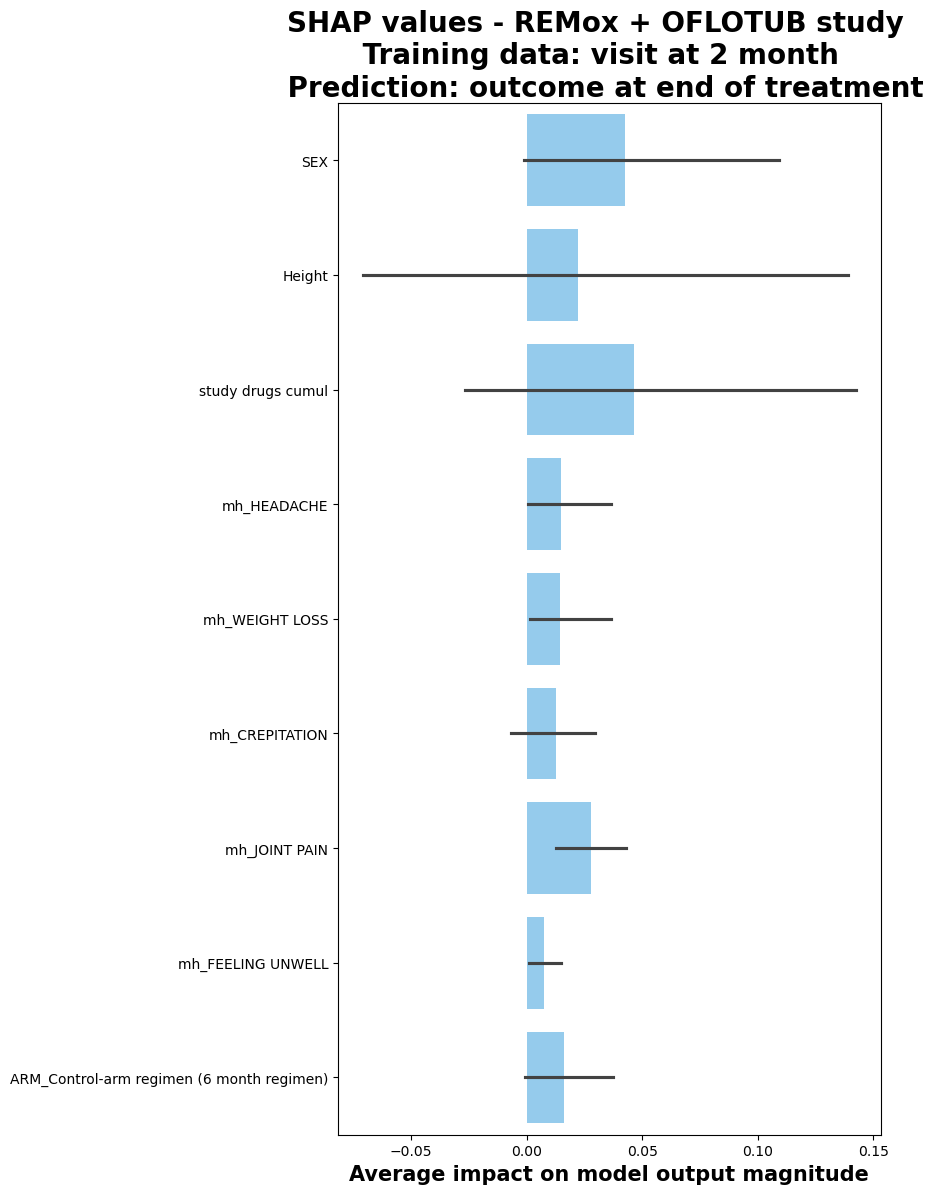

In [19]:
import shap 

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[1:2]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[:1]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_test_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):

                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                        X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_)
                       
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        feature_names=X_test.columns.tolist()
                        feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                        feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                        feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]

                        
                        ## Extract shap-values
                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}']['shap_values'] 
                        
                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names_split, vals)),
                                                      columns=['col_name','feature_importance_vals'])
                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                        
                        shap_abs_df_list.append(shap_abs_importance_df)

                        ## Add ARM and USUBID information to the shap value dataframe
                        rf_resultX['USUBJID']=X_test.index.tolist()
                        rf_resultX['cv_repeat_num']=cv_repeat_num

                        arm_pat_dict=X.loc[X['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                        rf_resultX['ARM']=X_test.index.map(arm_pat_dict)
                        shap_df_list.append(rf_resultX)


                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                        X_test_norm=(X_test-X_test.min())/(X_test.max()-X_test.min())
                        X_test_norm['cv_repeat_num']=cv_repeat_num
                        X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                        X_test_list.append(X_test_norm)
                        
                        
                        #ax=axes[cv_repeat_num]
                        #plt.sca(ax)
                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                        #                    feature_names=feature_names_split,sort=False,show=False)
                        
                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                        
                        #if plot_type=='dot':
                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                        
                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT
                
                merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_test_list,axis=0) 
                
                # Subset to variables that have a SHAP value >0 in any of the CV-splits
                a=merged_abs_shap_across_cv.groupby('col_name').apply(lambda x: x['feature_importance_vals'].mean())
                features_with_non_zero_mean=a[a>np.max(a.values)*0.1].index
                plot_df=merged_abs_shap_across_cv.loc[merged_abs_shap_across_cv['col_name'].isin(features_with_non_zero_mean),:]
                
                fig2,ax2=plt.subplots(1,1,figsize=(7,num_of_feats*0.05))
                sns.barplot(data=plot_df,x='feature_importance_vals',y='col_name',ax=ax2,color='lightskyblue')
                
                if data_param_key in suptitle_study_dict.keys():
                    study_names=suptitle_study_dict[data_param_key]
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    suptitle= f"SHAP values - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                
                else:
                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                fig2.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=0.95)      
                ax2.set_xlabel('Average impact on model output magnitude',fontsize=y_label_size,fontweight='bold')
                ax2.set_ylabel(None)

## Plot absolute SHAP values averged per CV-rep for each Arm

In [ ]:
c=a.loc[:,a.columns.str.contains('mh_')].mean()
c[c<=0].index.tolist()

tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment
Period: all days
last_therapy_day model
Loading SHAP-values for model XGBoost


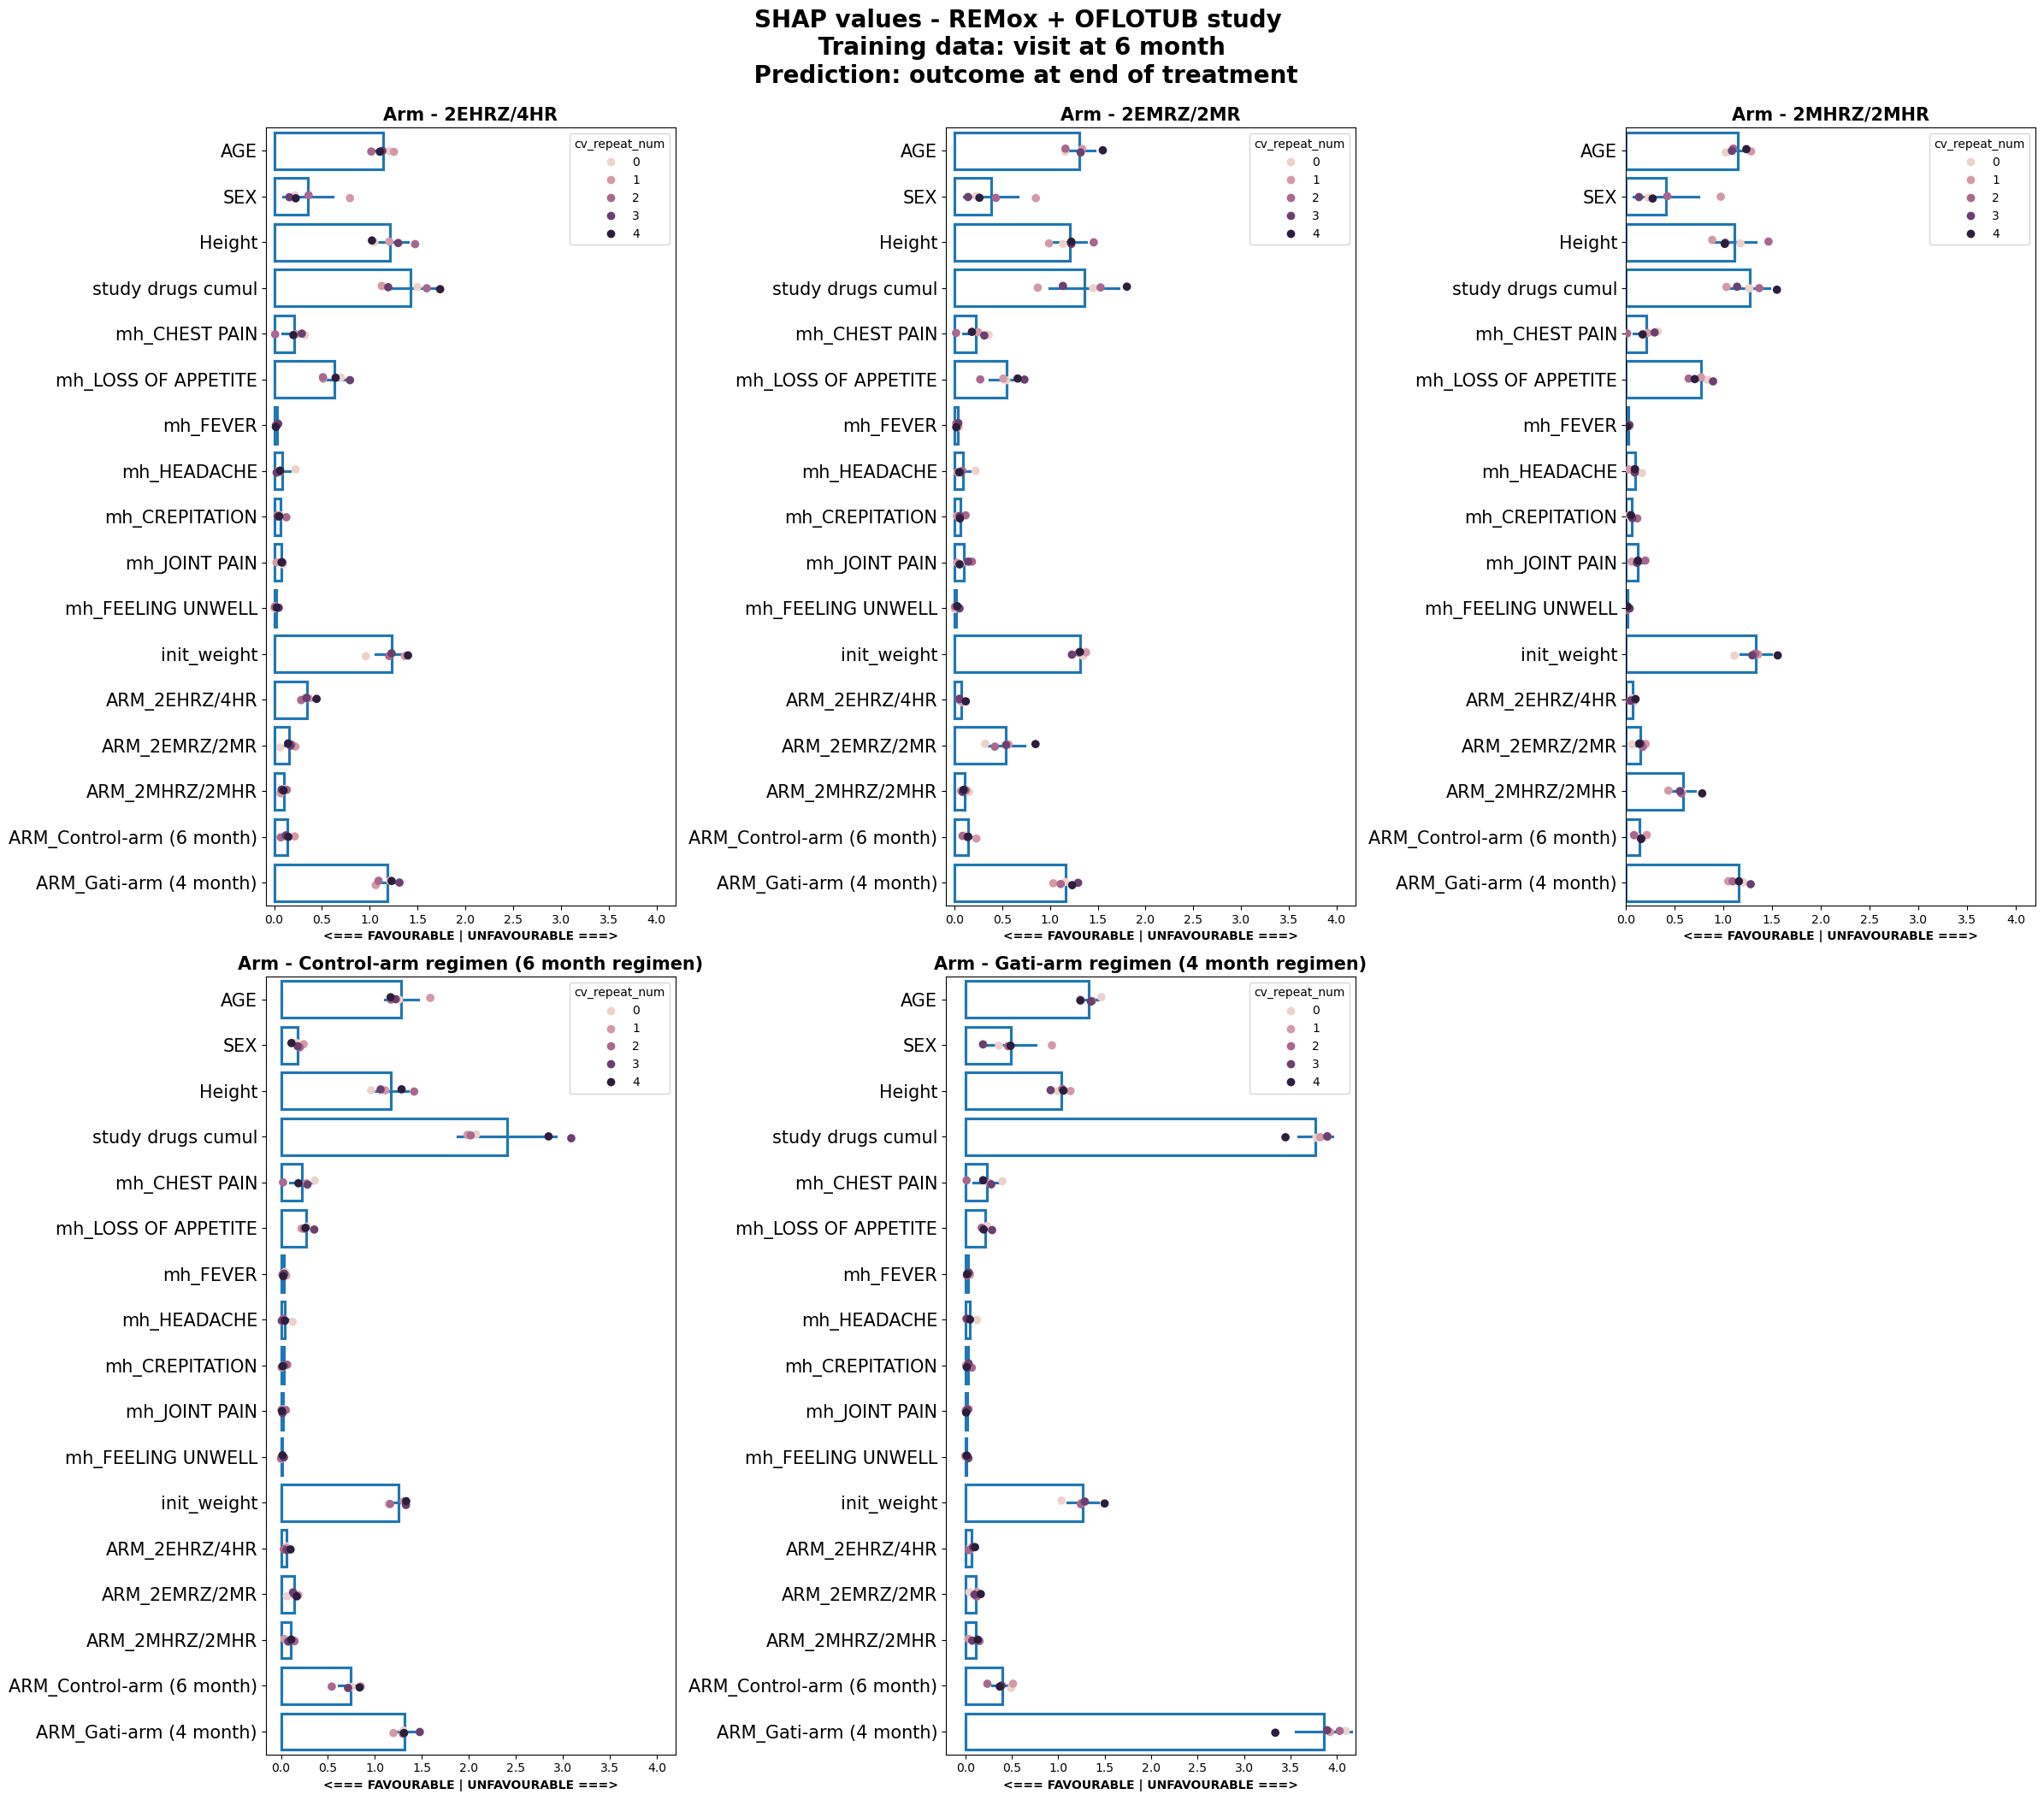

In [82]:
import shap
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[-1:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[:1]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_test_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):

                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                        X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_)
                       
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        feature_names=X_test.columns.tolist()
                        feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                        feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                        feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                        feature_names_split=[x.replace(' regimen','')for x in feature_names_split]

                        
                        ## Extract shap-values
                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}']['shap_values'] 
                        
                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names_split, vals)),
                                                      columns=['col_name','feature_importance_vals'])
                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                        
                        shap_abs_df_list.append(shap_abs_importance_df)

                        ## Add ARM and USUBID information to the shap value dataframe
                        rf_resultX['USUBJID']=X_test.index.tolist()
                        rf_resultX['cv_repeat_num']=cv_repeat_num

                        arm_pat_dict=X.loc[X['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                        rf_resultX['ARM']=X_test.index.map(arm_pat_dict)
                        shap_df_list.append(rf_resultX)


                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                        X_test_norm=(X_test-X_test.min())/(X_test.max()-X_test.min())
                        X_test_norm['cv_repeat_num']=cv_repeat_num
                        X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                        X_test_list.append(X_test_norm)
                        
                        
                        #ax=axes[cv_repeat_num]
                        #plt.sca(ax)
                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                        #                    feature_names=feature_names_split,sort=False,show=False)
                        
                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                        
                        #if plot_type=='dot':
                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                        
                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT
                
                merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_test_list,axis=0) 


                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b',regex=True)]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                
                
                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                mh_thr=0.1
                mh_shap_vals=merged_shap_across_cv_numeric.loc[:,merged_shap_across_cv_numeric.columns.str.contains('mh_')].mean()
                mh_cols_to_drop=mh_shap_vals[mh_shap_vals<=np.max(mh_shap_vals.values)*mh_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=mh_cols_to_drop)
                
                
                ncols=3
                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    
                    ## Subset to ARM shap values 
                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                
                    ## Calculate the mean of raw SHAP values per CV-rep
                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].mean()))
                    
                    ## Calculate the mean of absolute SHAP values per CV-rep
                    shap_plot_df=shap_df.groupby(['cv_repeat_num']).apply(lambda x:(x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')].abs().mean()))
                
                    ## Melt to long format
                    shap_plot_df=pd.melt(shap_plot_df.reset_index(),id_vars=['cv_repeat_num'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                    #x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                
                    ## PLot SHAP values as a barplot + a stripplot
                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='sd',fill=False,ax=ax)
                    sns.stripplot(data=shap_plot_df,y='variable',x='value',hue='cv_repeat_num',ax=ax,s=7,jitter=0.05)
                
                    ## Sert axis labels and titles
                    #ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                    ax.set_xlabel('Average impact on model output magnitude',fontsize=8,fontweight='bold')
                    ax.tick_params(axis='y', labelsize=15)
                    ax.set_ylabel(None)
                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                    plt.tight_layout()
                    #ax.set_xlim(-1.3,1.6)
                    ax.set_xlim(None,4.2)
                
                ## Create suptitle
                if data_param_key in suptitle_study_dict.keys():
                    study_names=suptitle_study_dict[data_param_key]
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if period_end_day!='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                    if period_end_day=='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                else:
                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)      


## Plot raw SHAP values for all CV-reps for each Arm

tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment
Period: 31 days
last_therapy_day model
Loading SHAP-values for model XGBoost
Period: 62 days
last_therapy_day model
Loading SHAP-values for model XGBoost
Period: 93 days
last_therapy_day model
Loading SHAP-values for model XGBoost
Period: 125 days
last_therapy_day model
Loading SHAP-values for model XGBoost
Period: 160 days
last_therapy_day model
Loading SHAP-values for model XGBoost
Period: all days
last_therapy_day model
Loading SHAP-values for model XGBoost


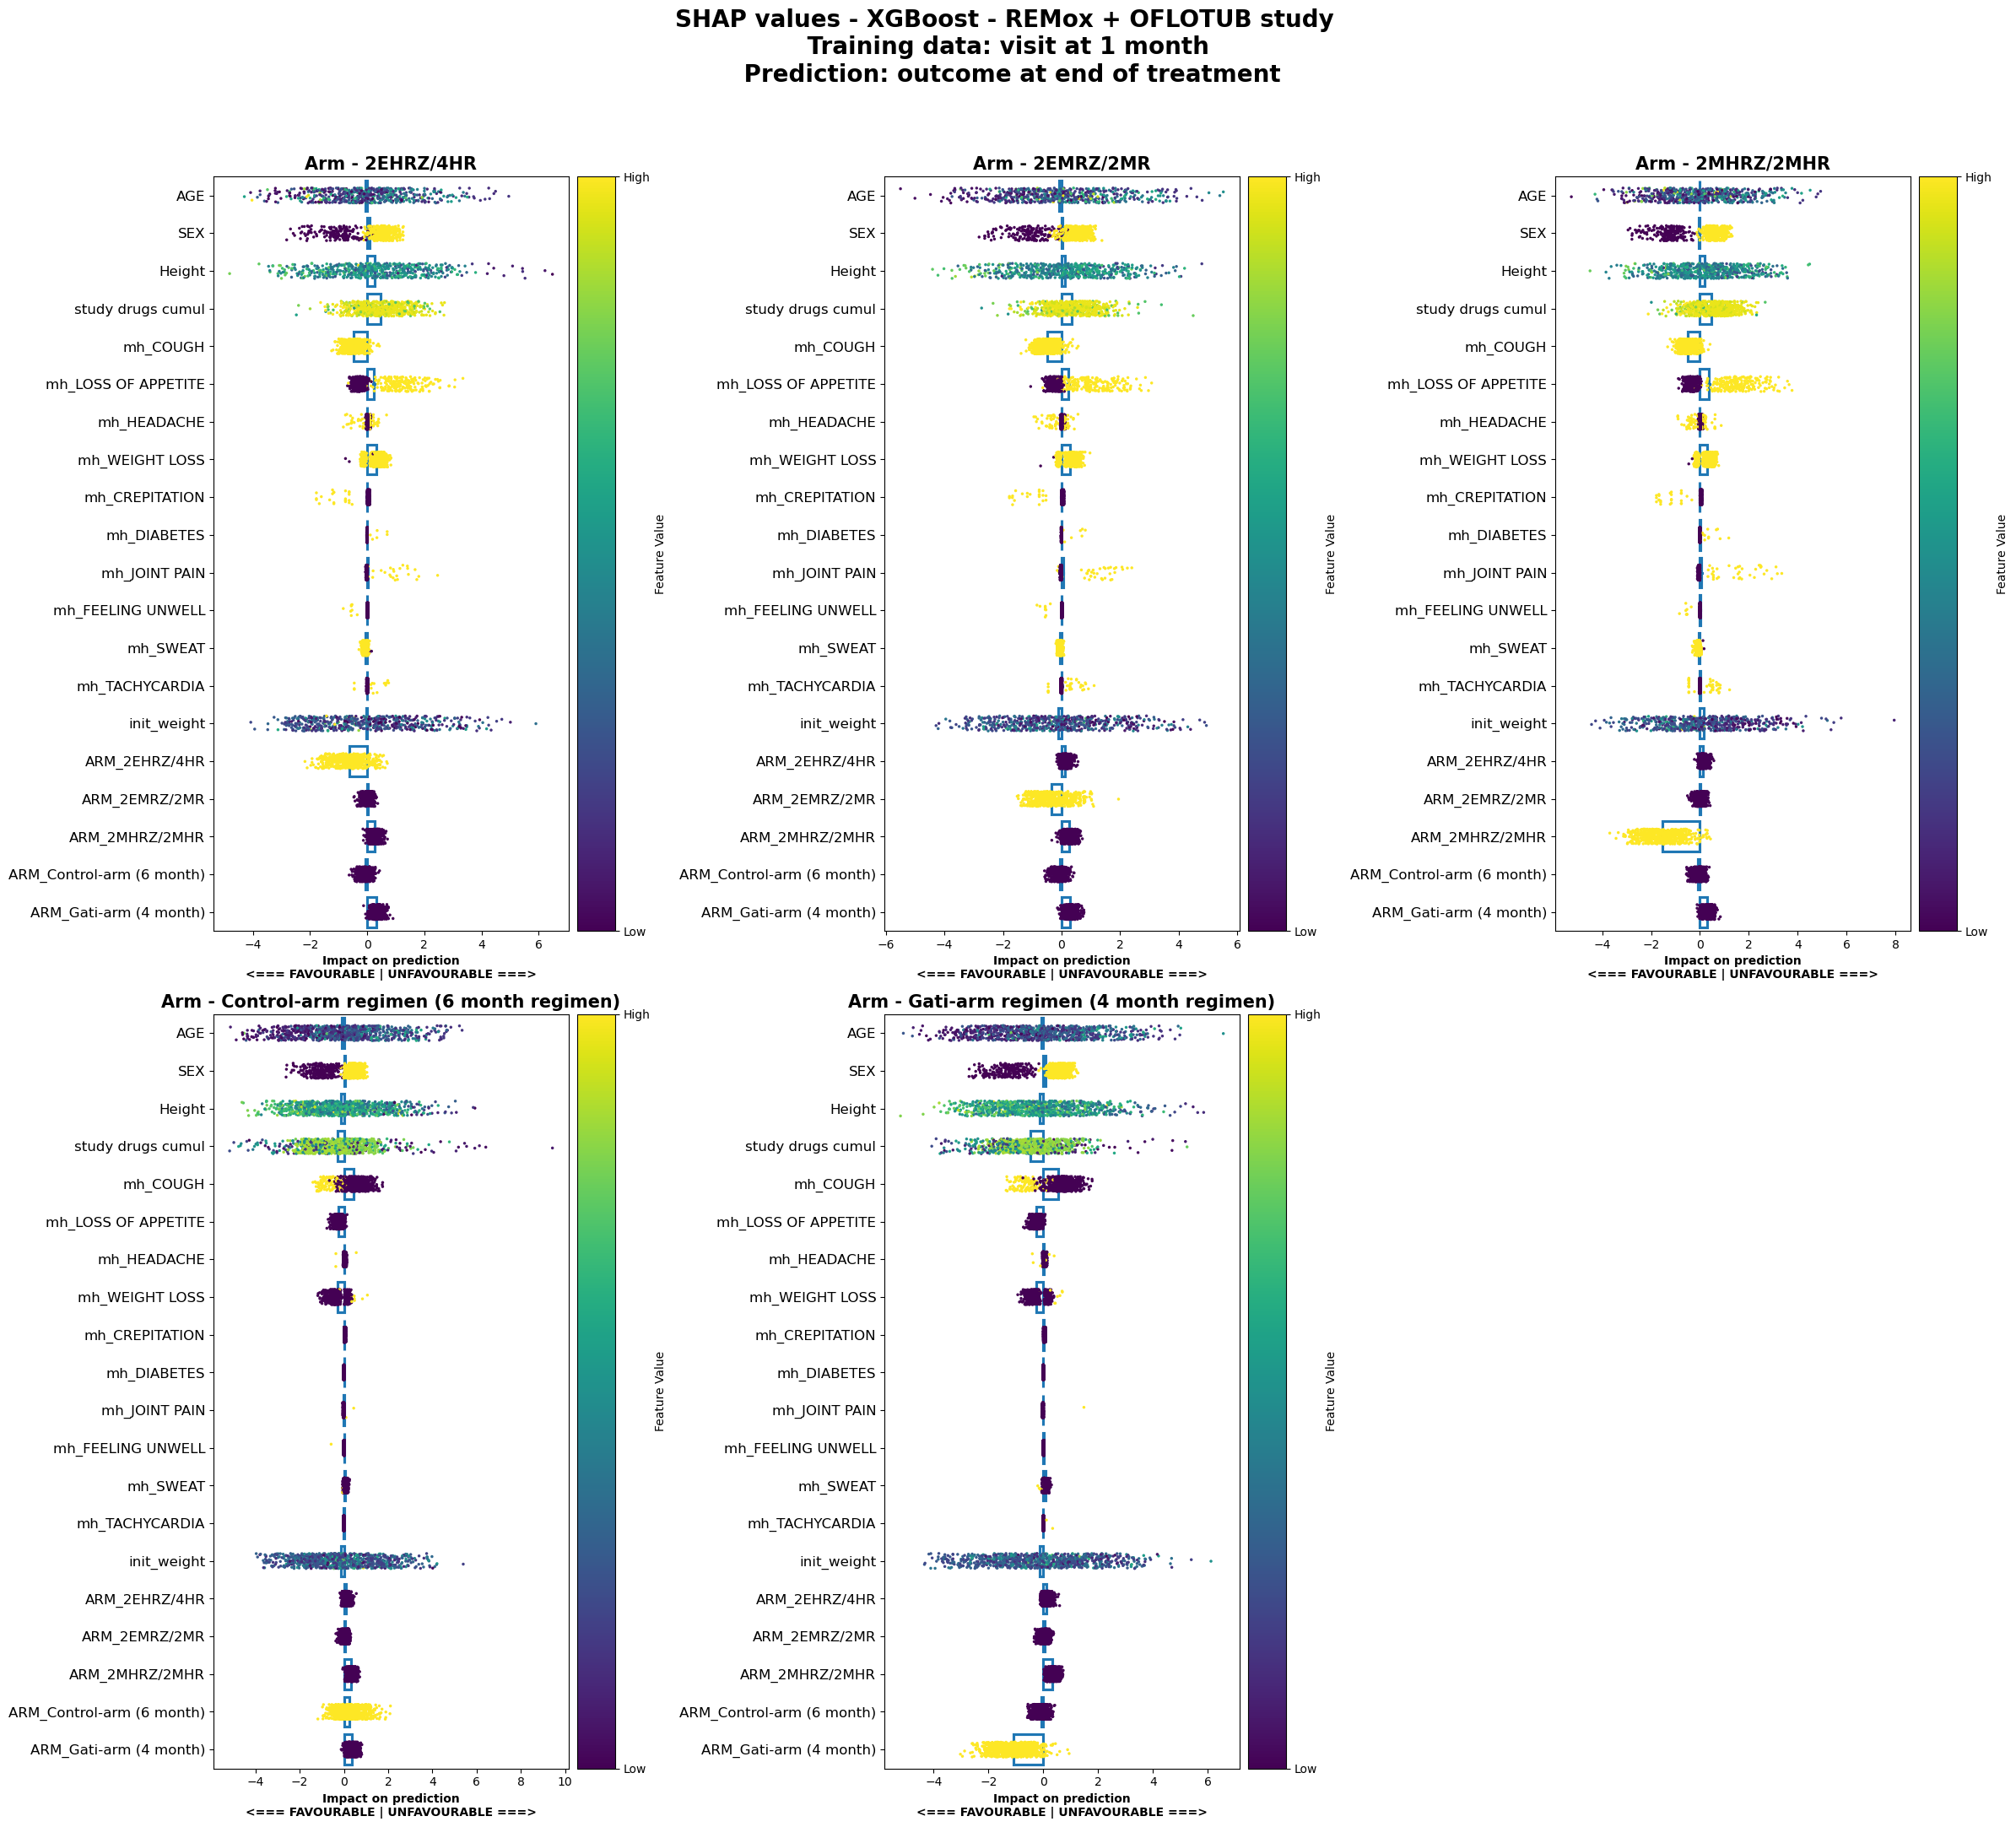

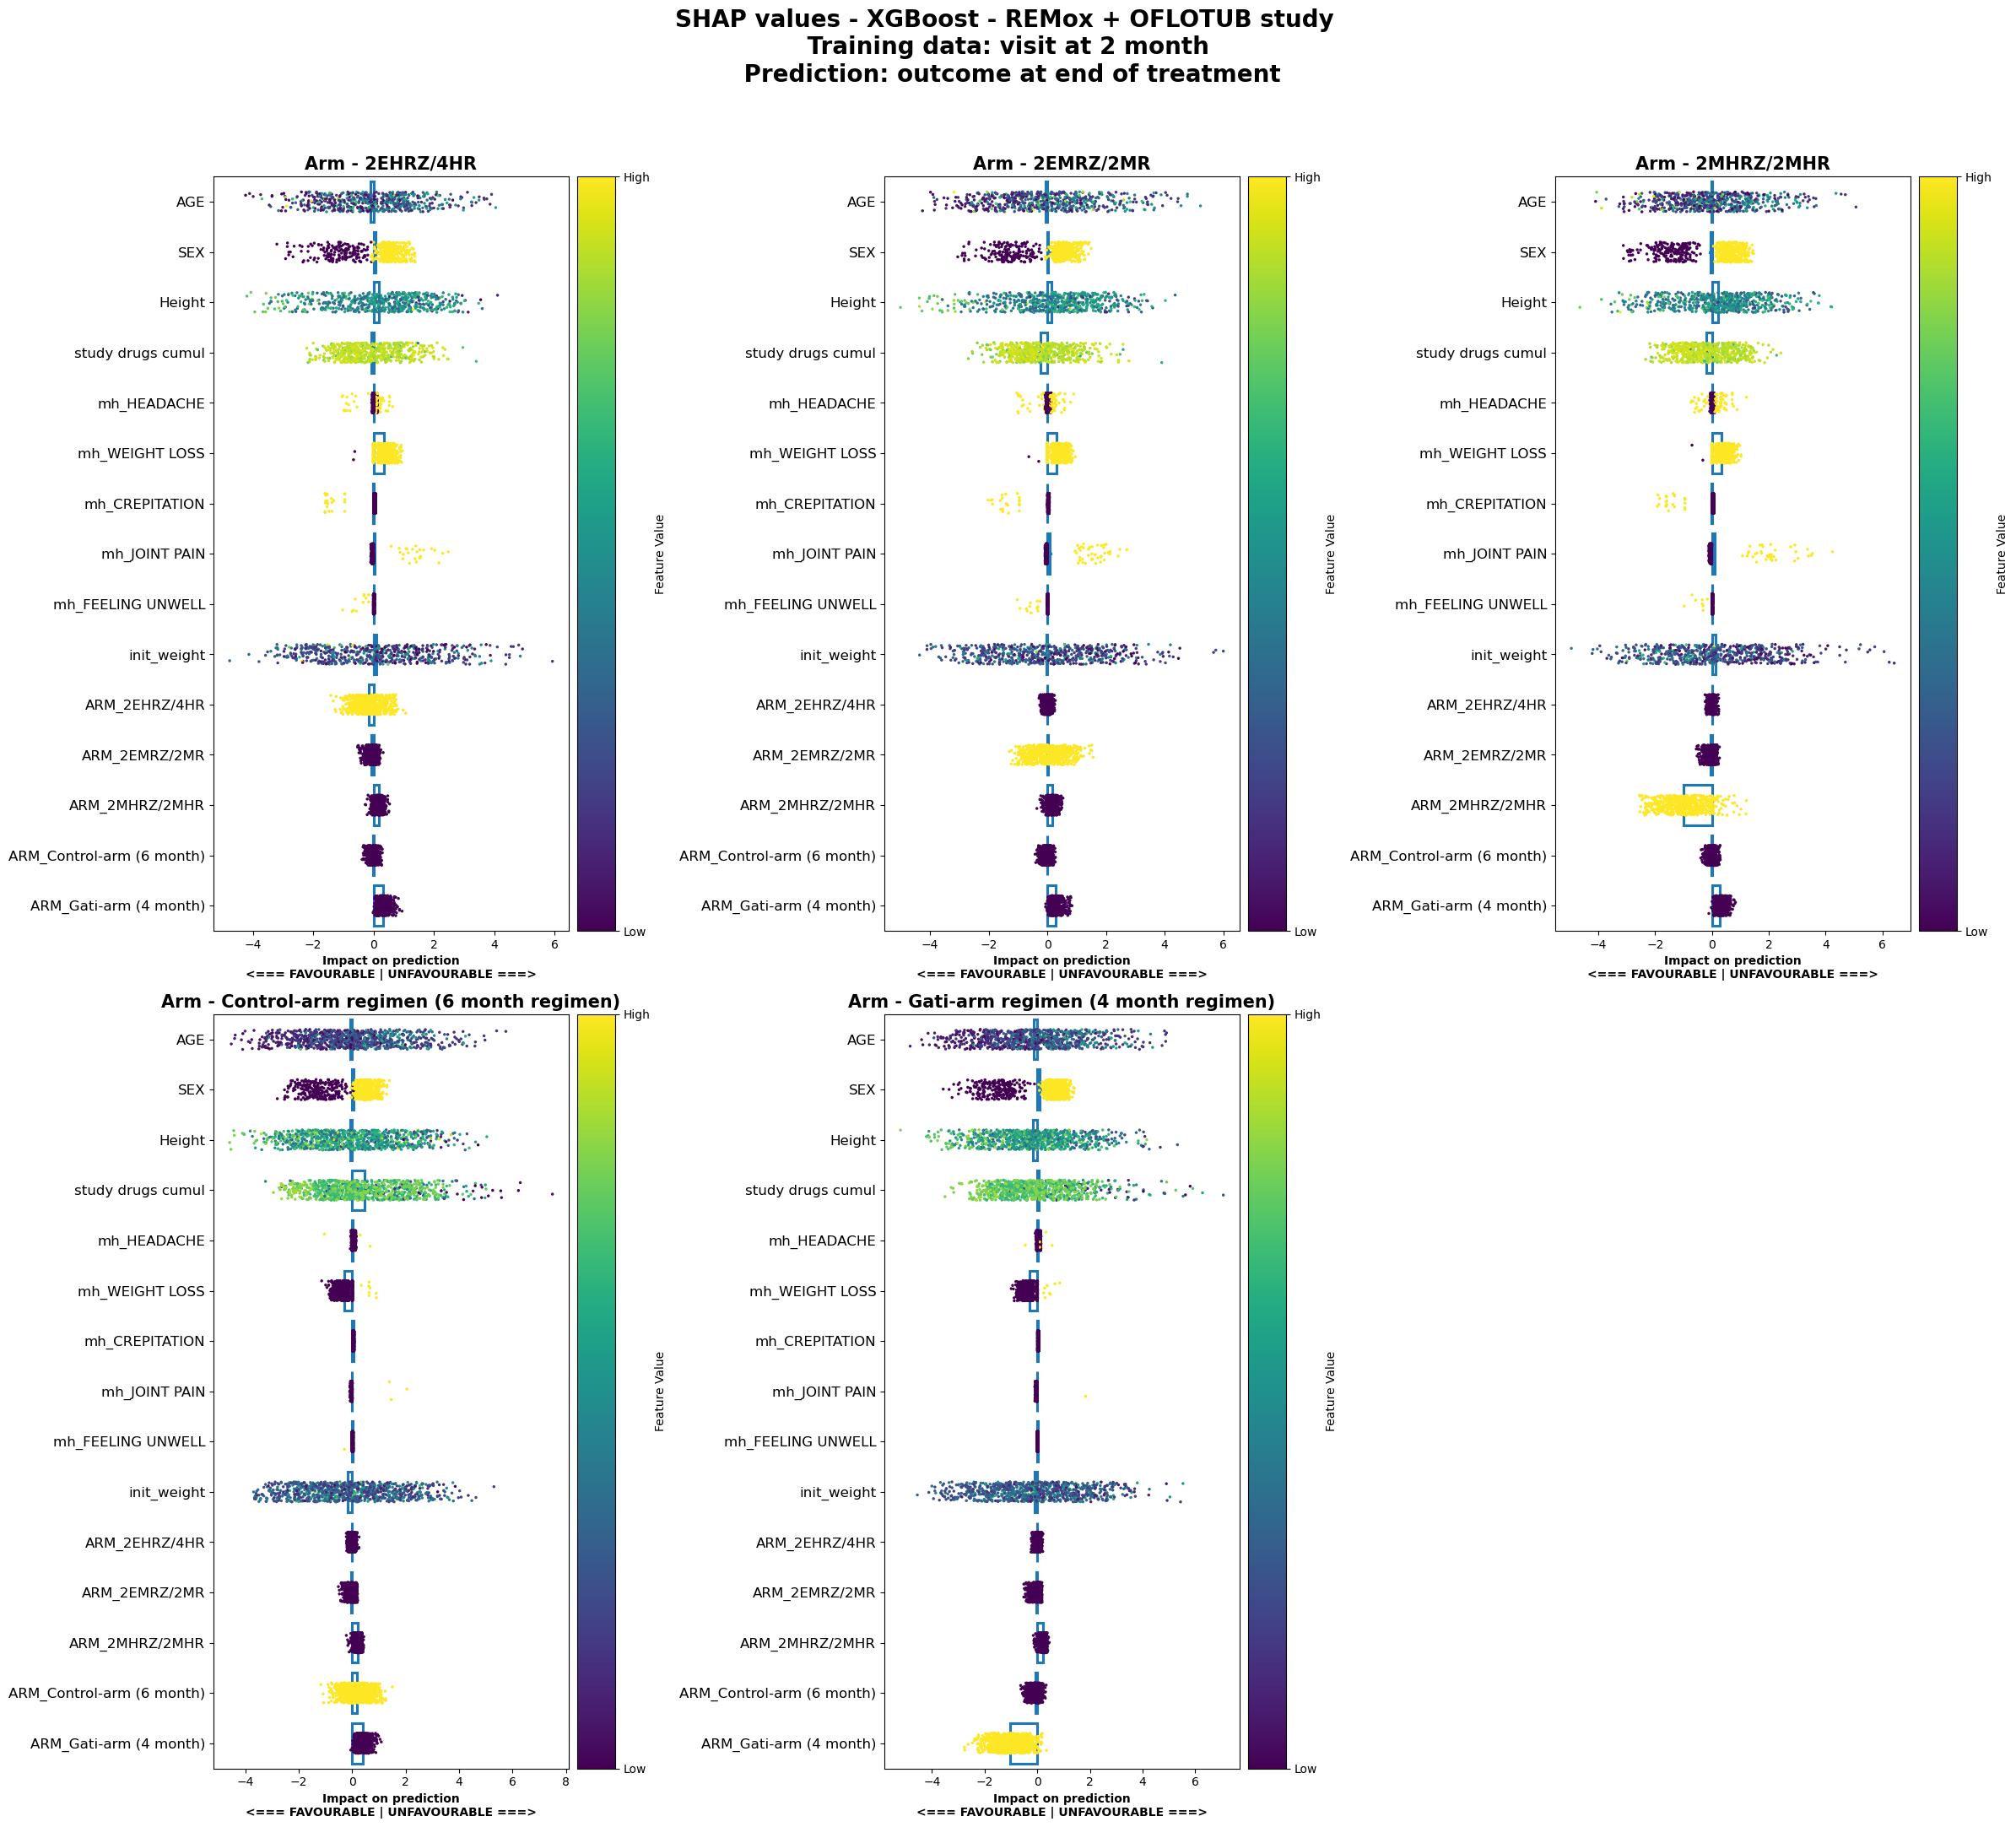

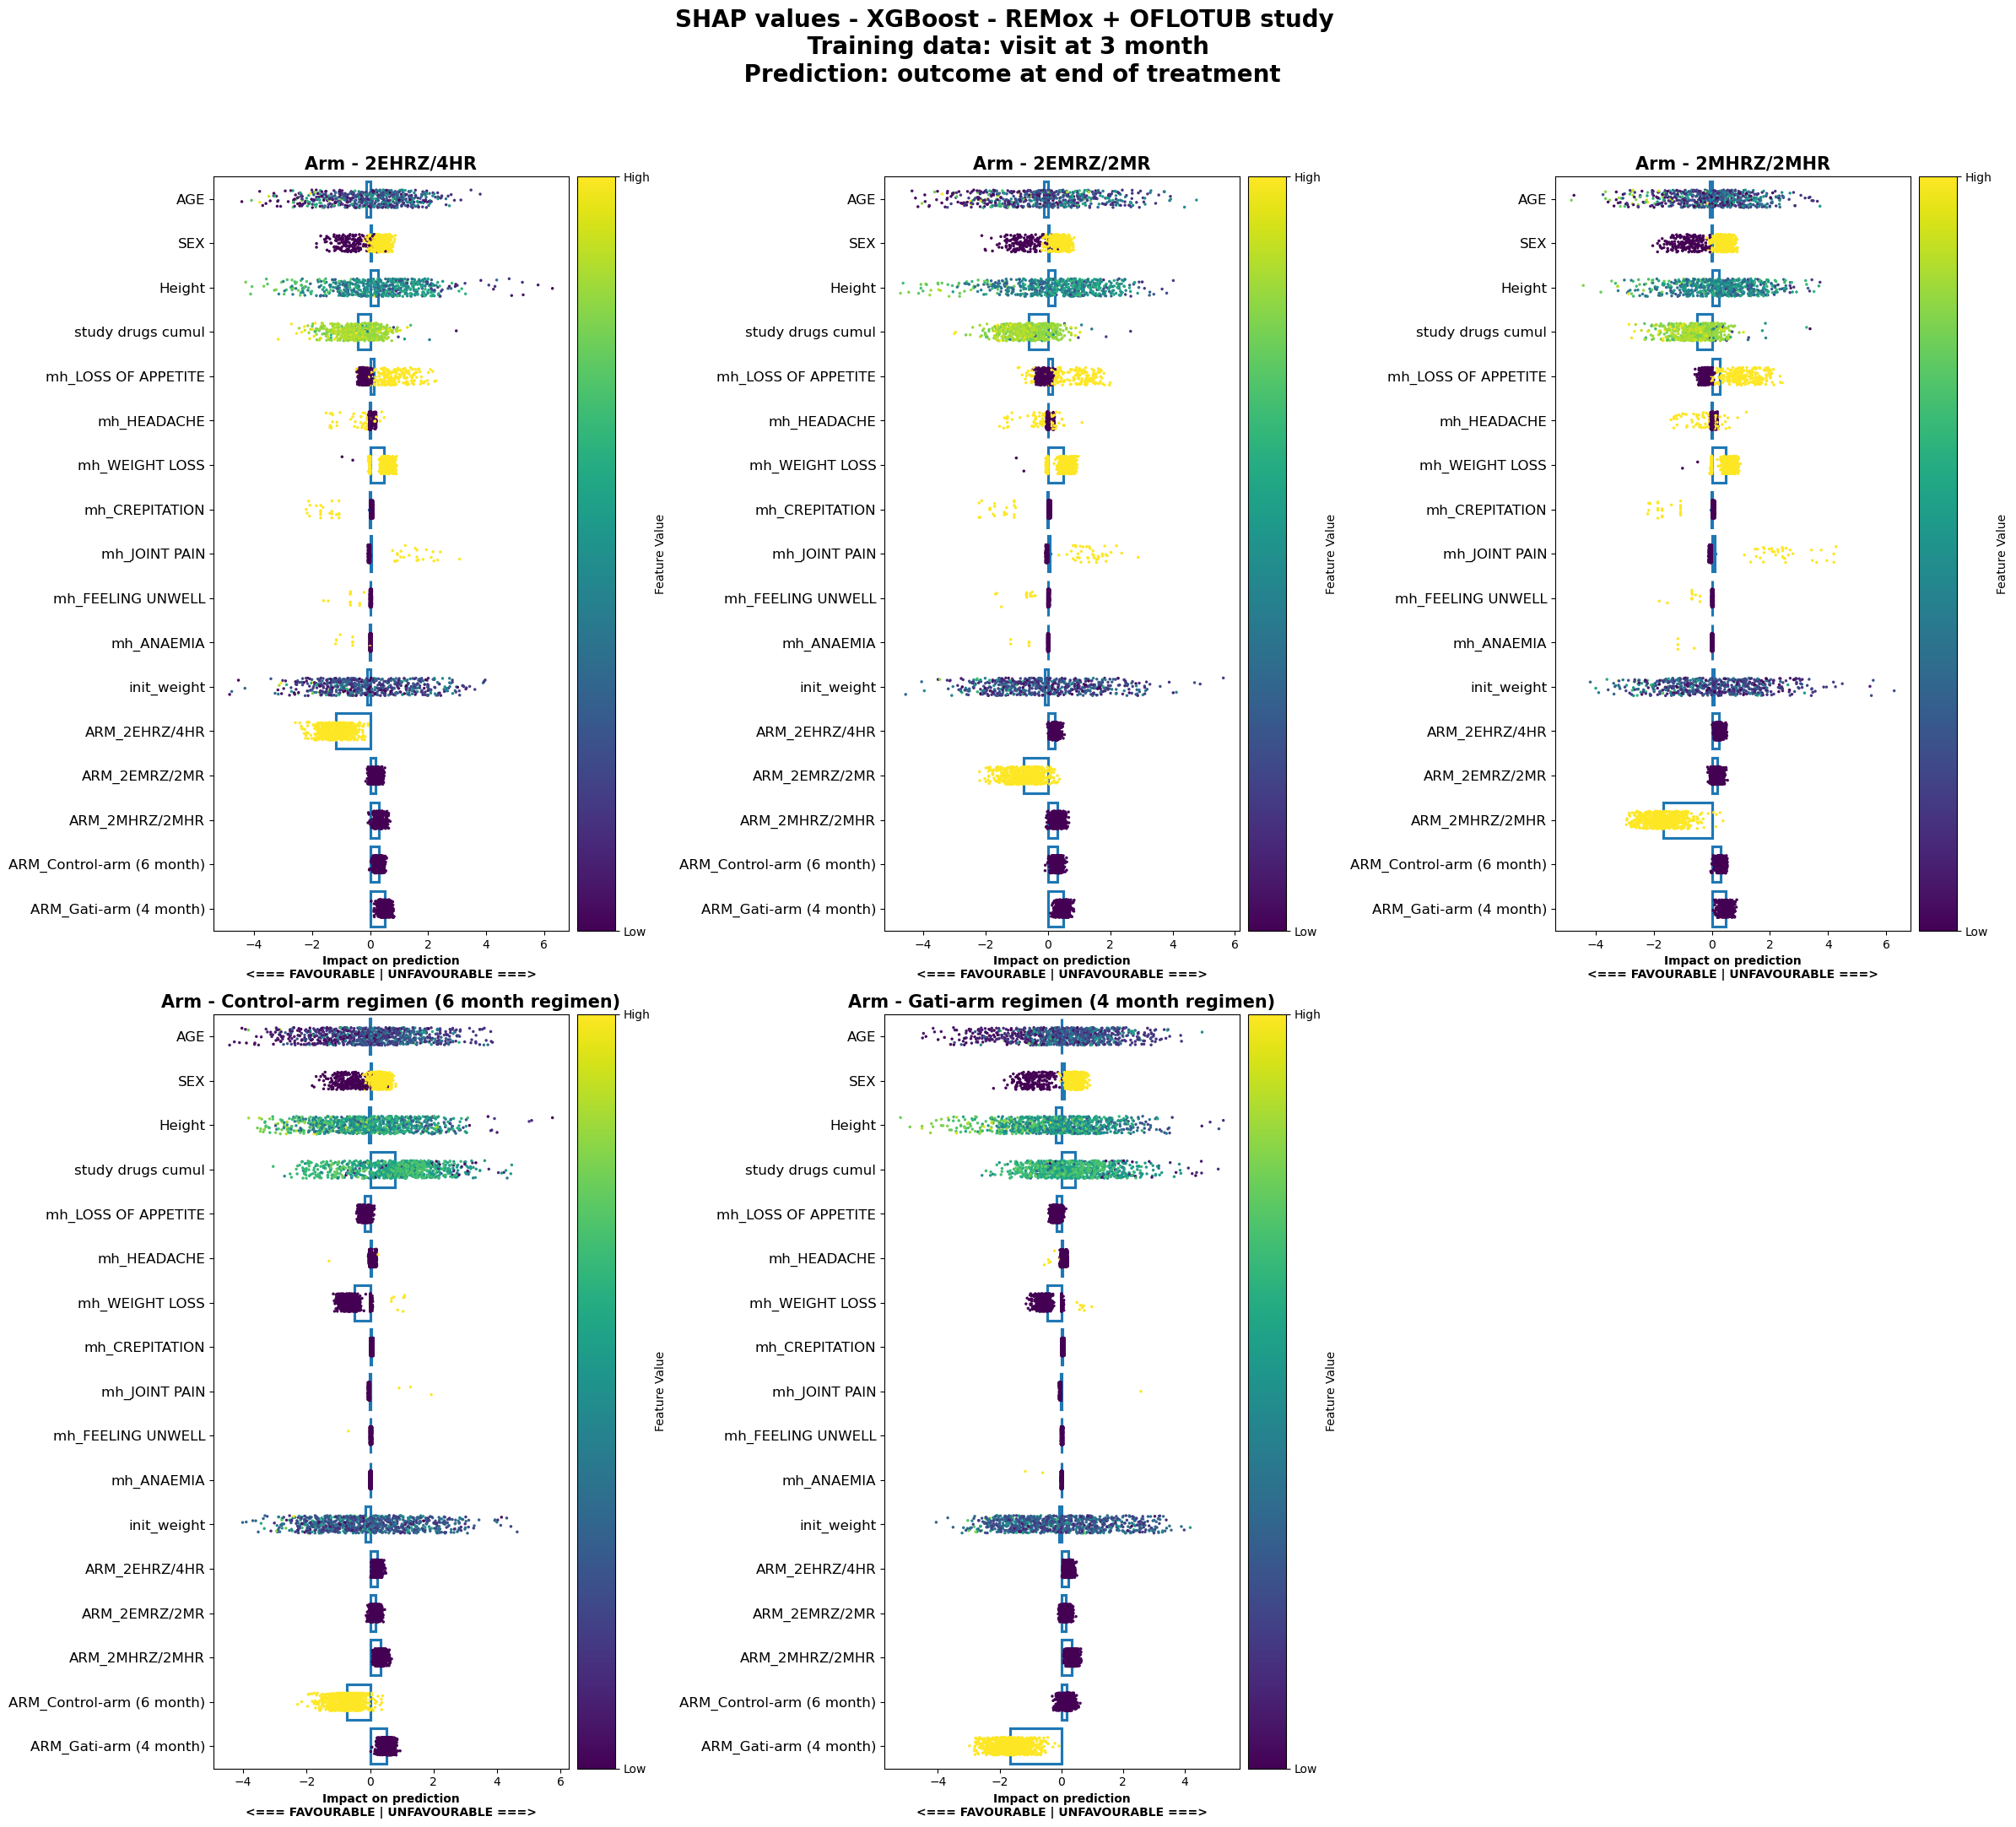

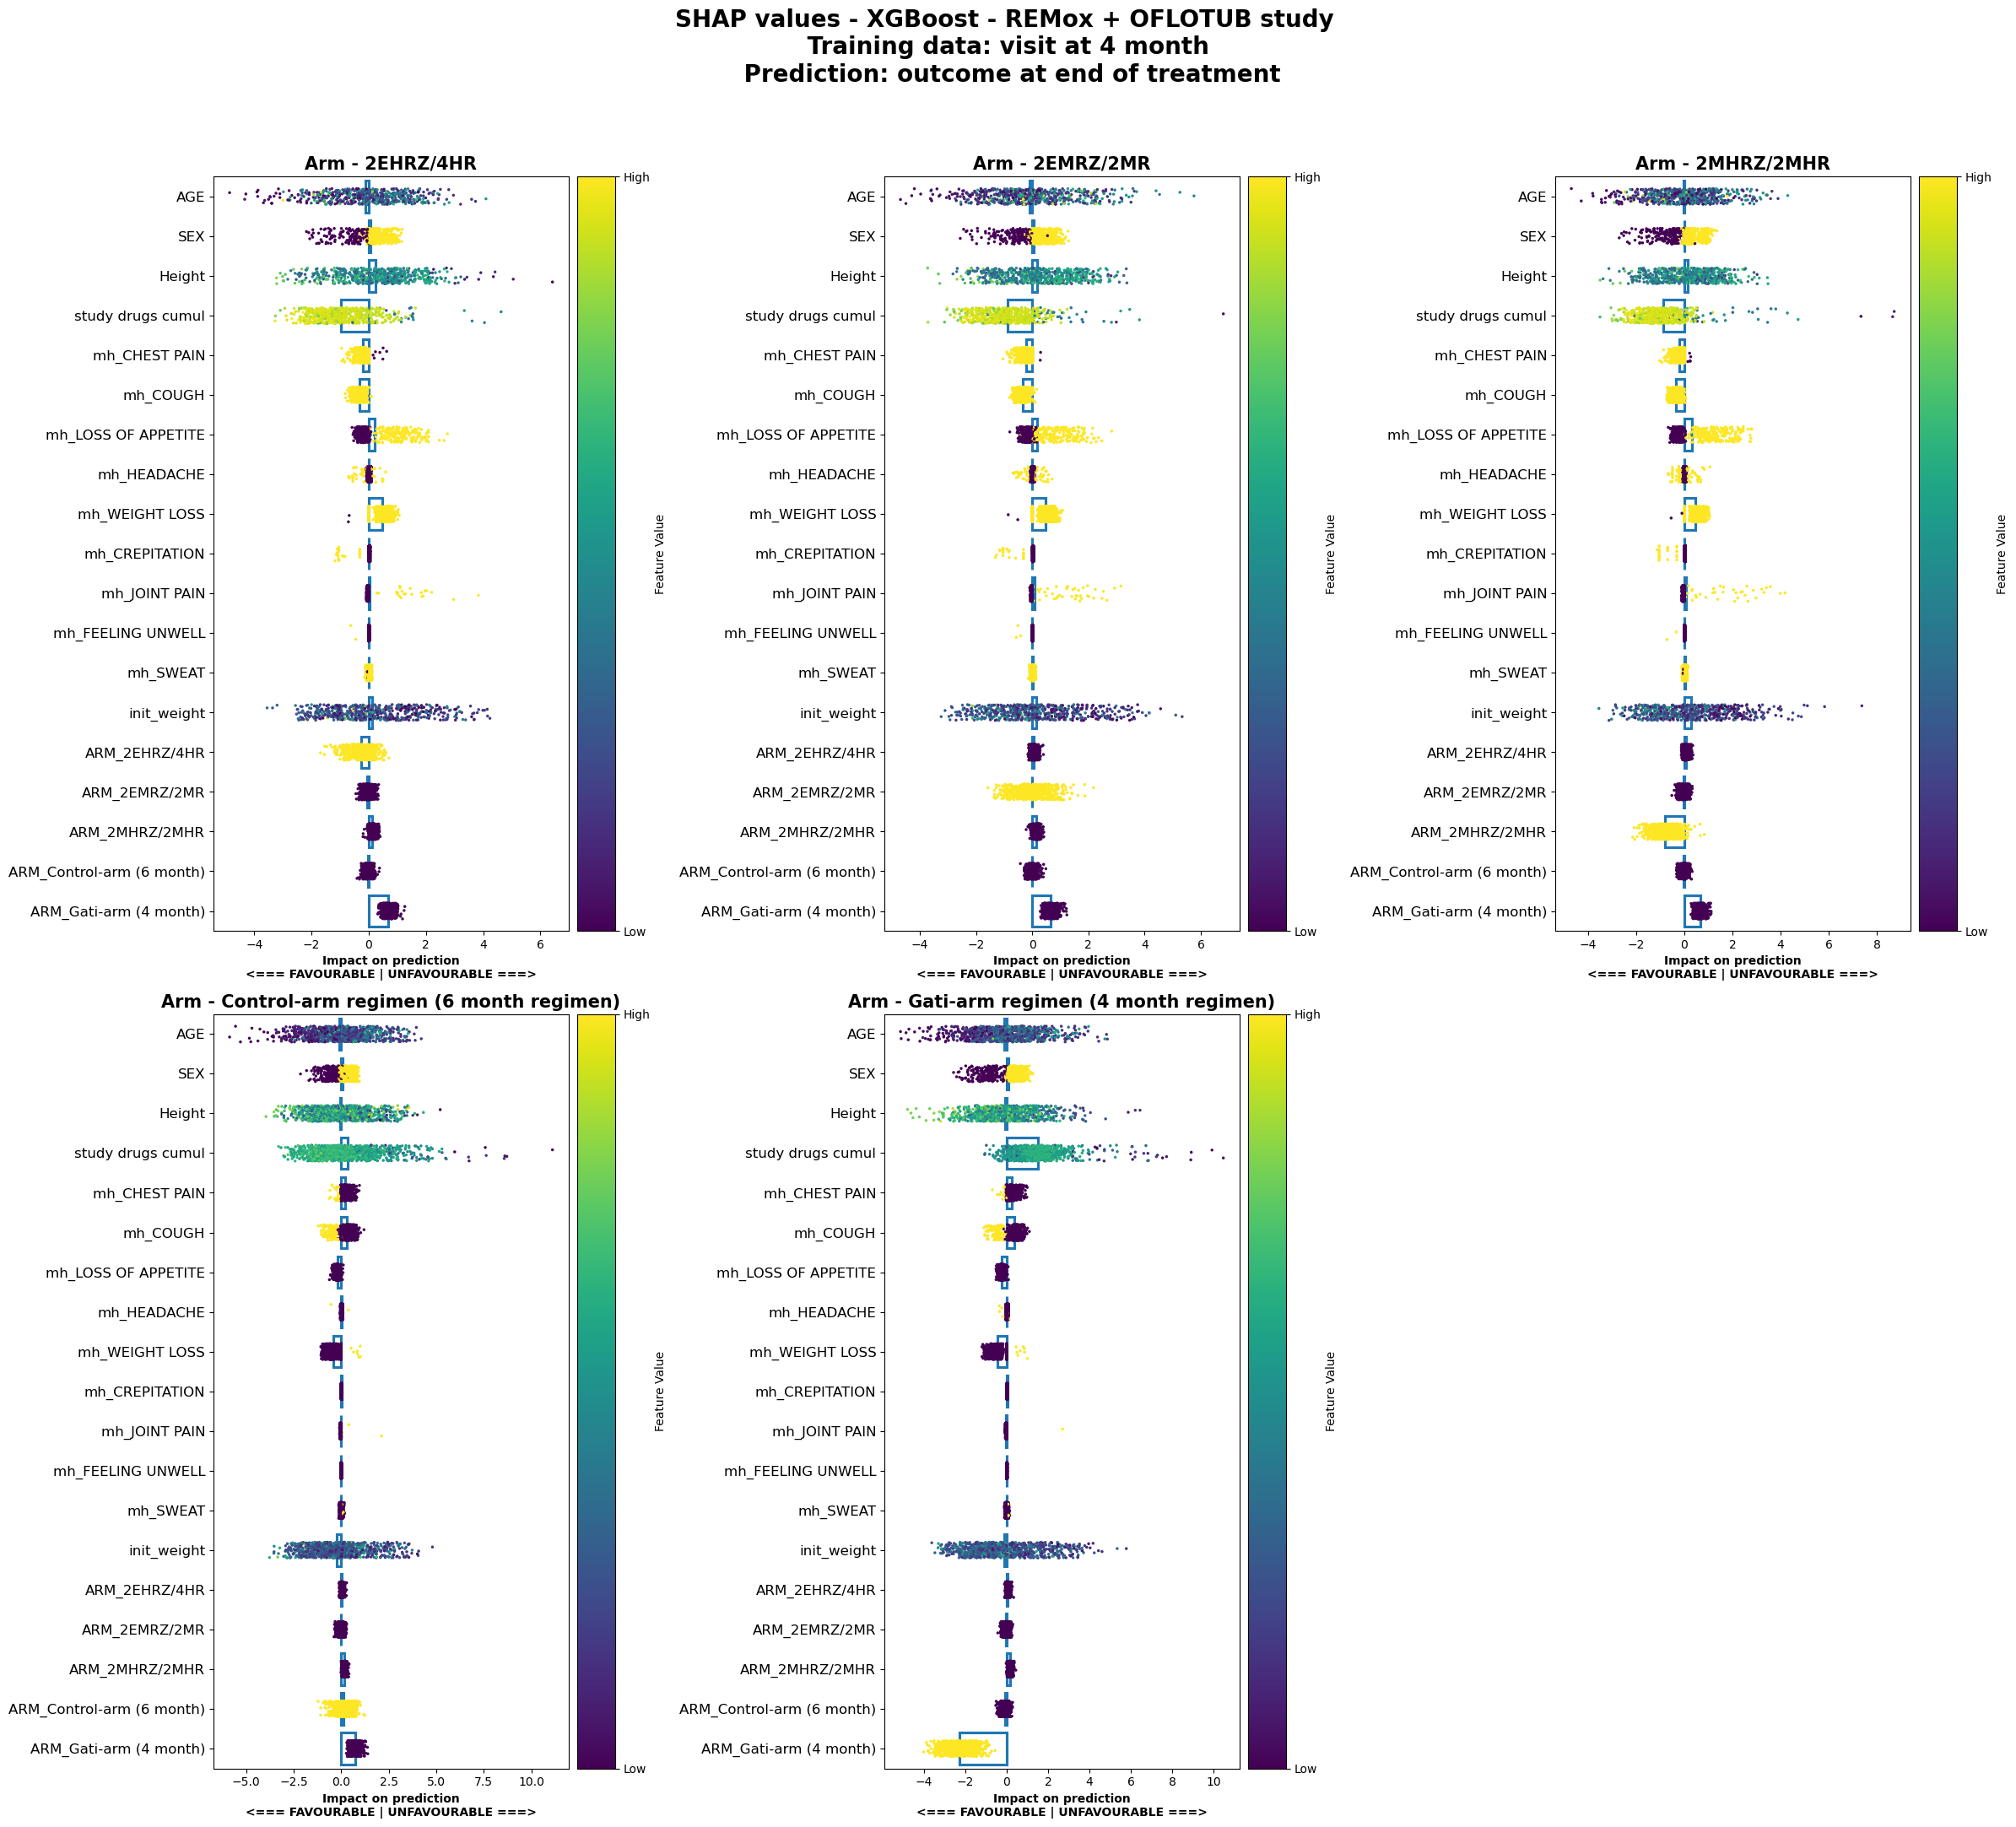

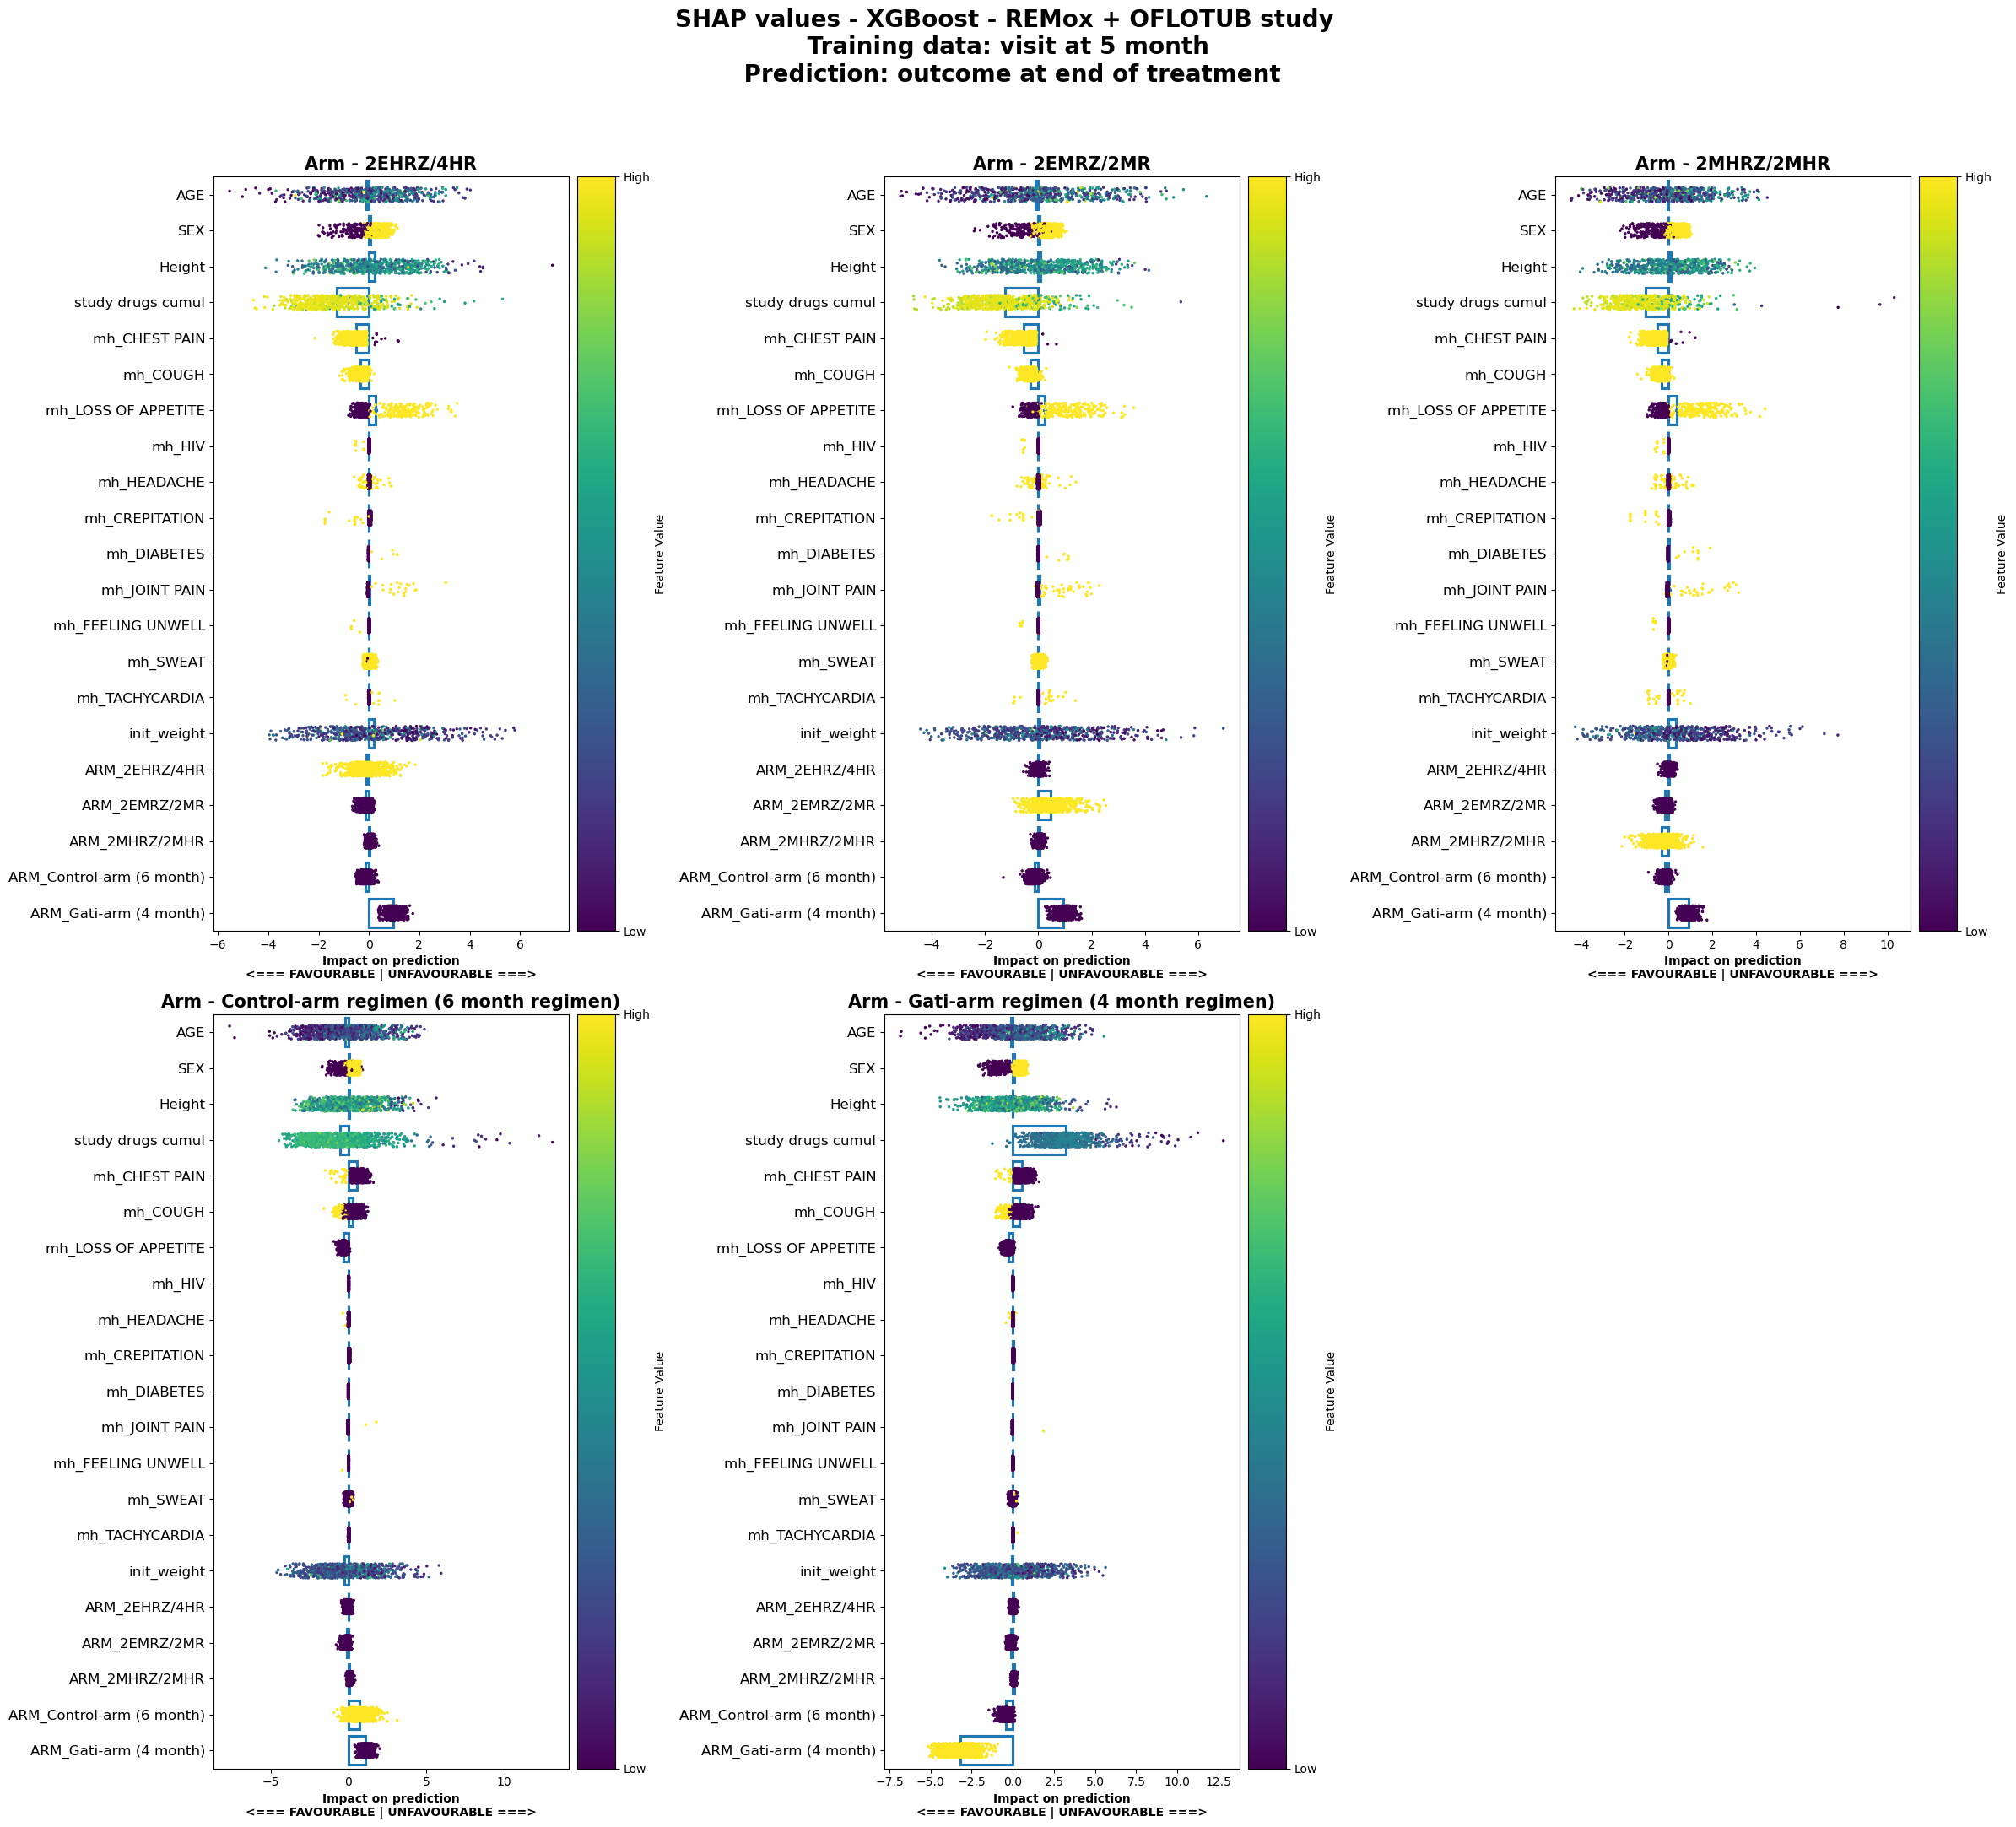

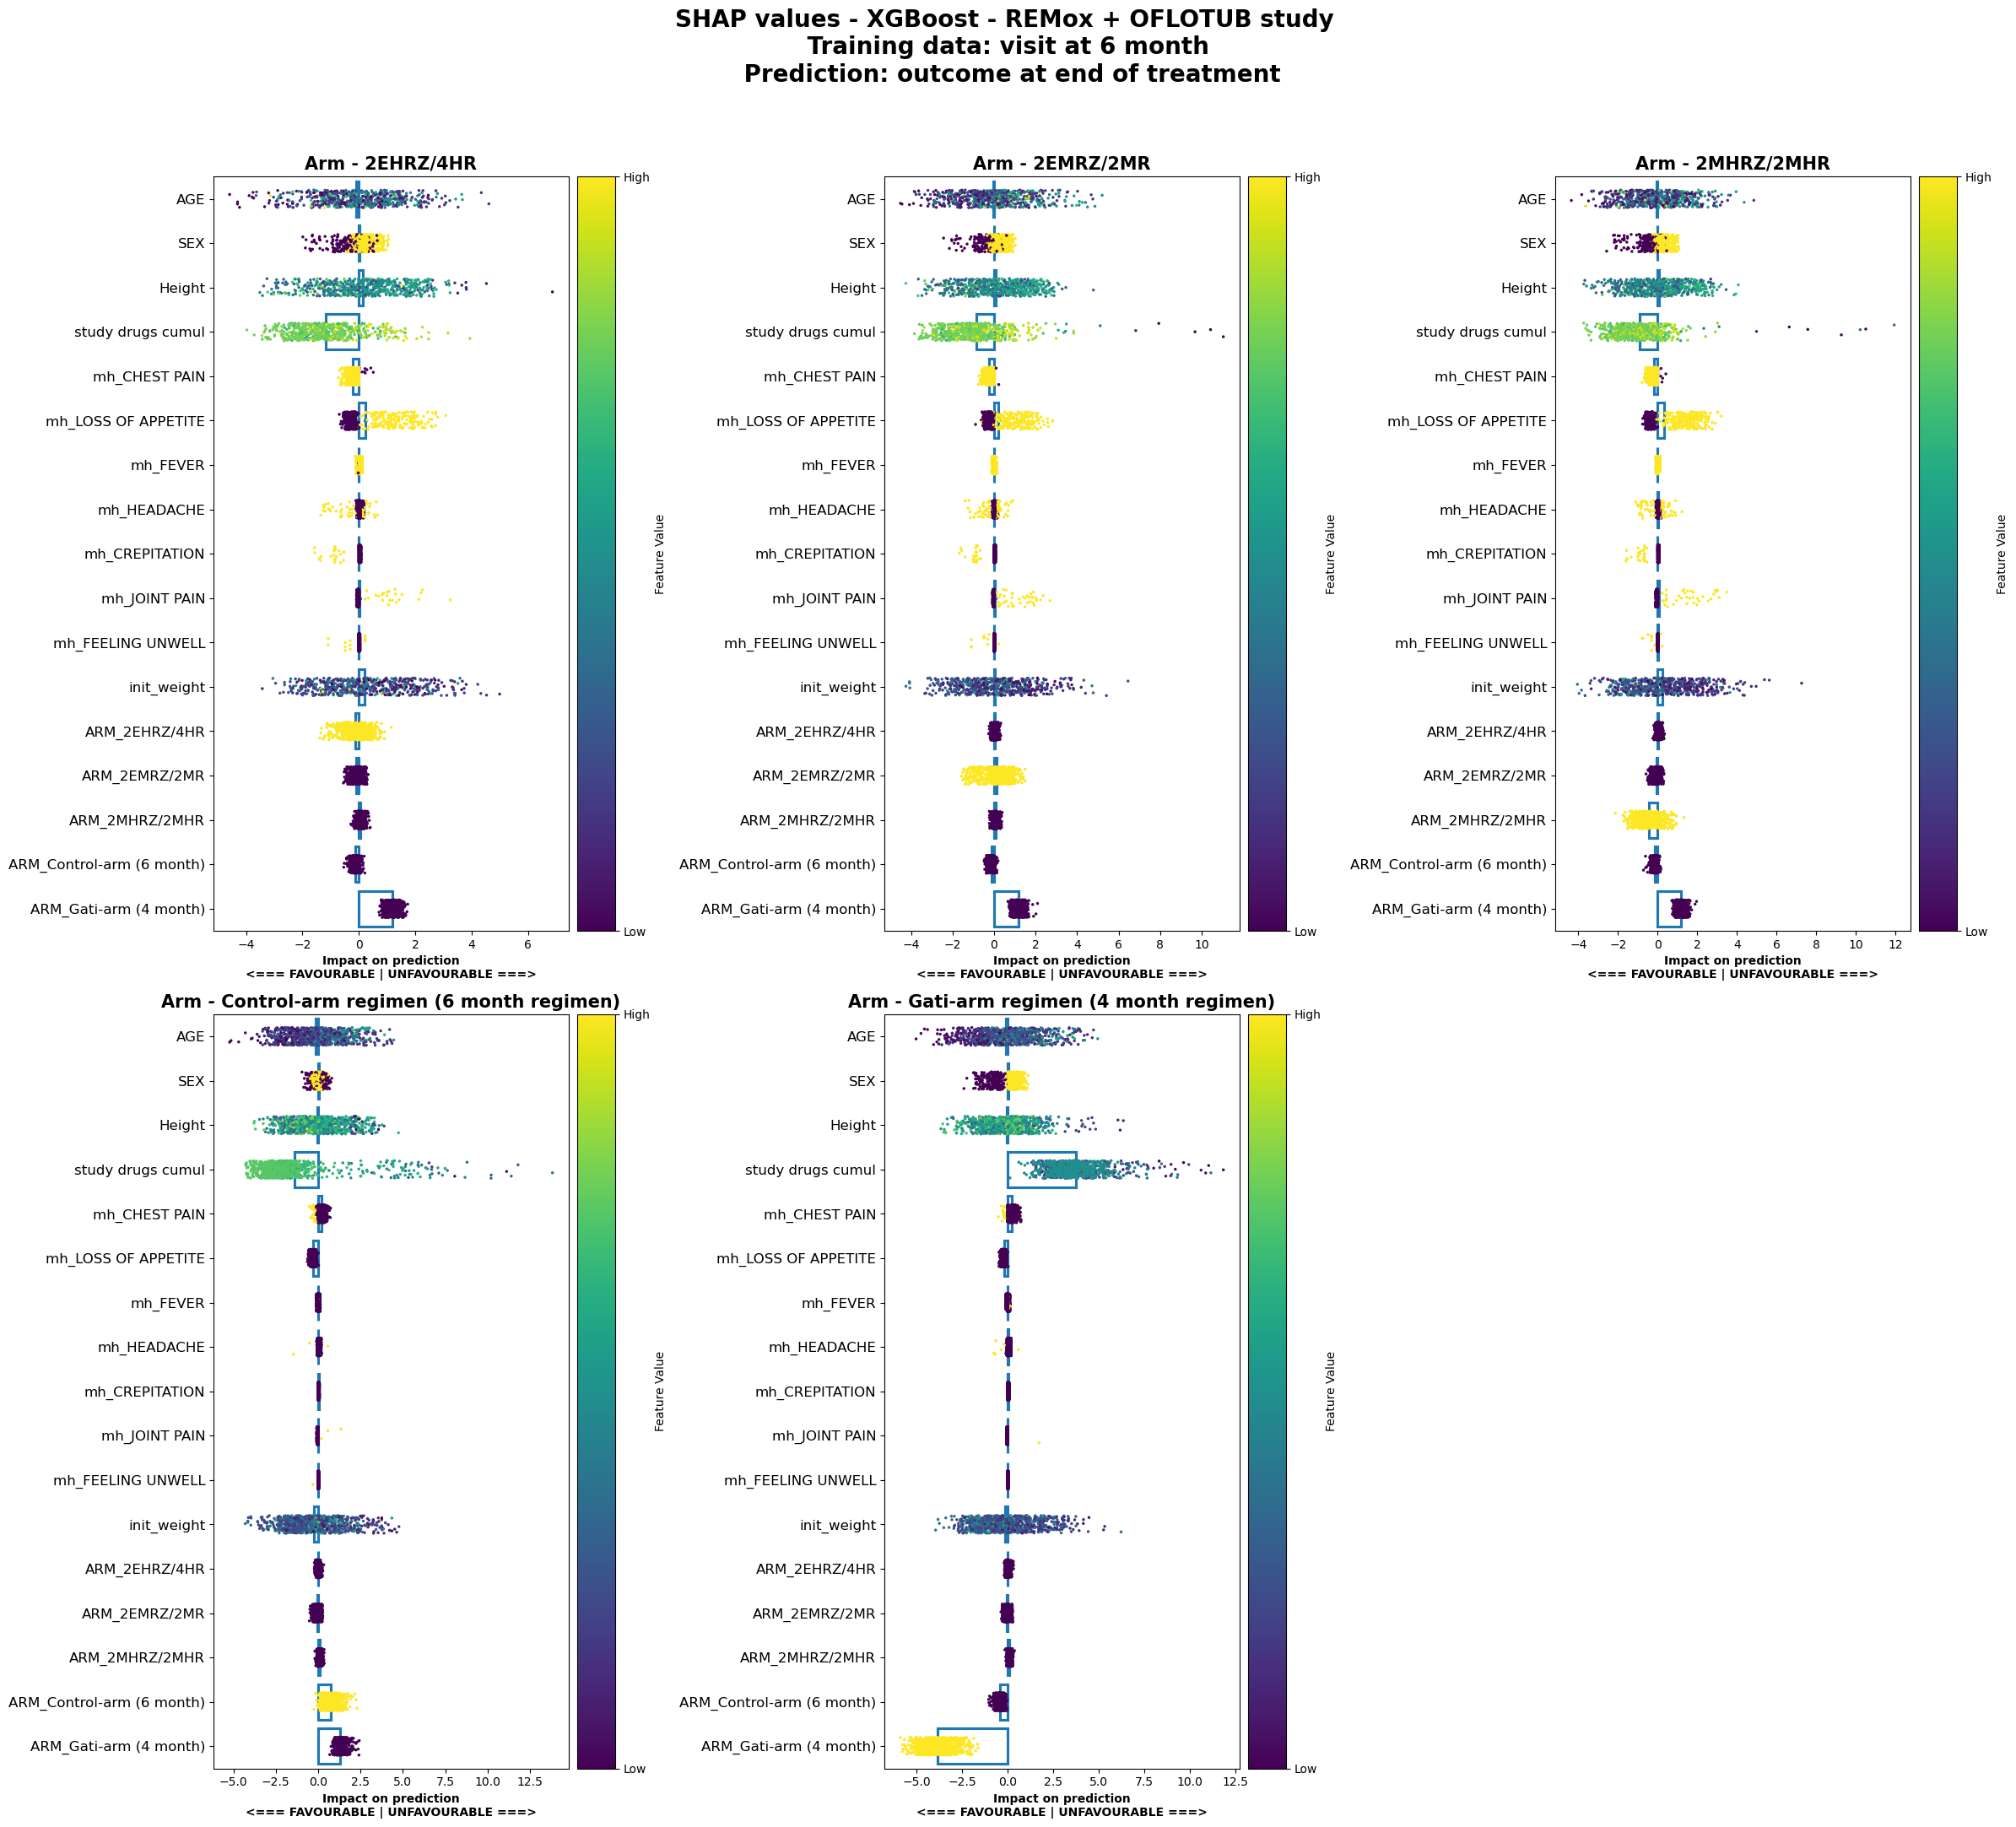

In [12]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)


import shap 

figtitle_size=20
subtitle_size=18
x_tick_size=31
y_tick_size=31
y_label_size=15
legend_fontsize=11.5
axis_lw=1.6


shap_plot_types=['bar','dot'] #'dot'


suptitle_study_dict={'tb21_22_18_3079_pats_22_vars_result_at_end_of_treatment':'REMox + OFLOTUB',
              'tb21_1405_pats_41_vars_result_at_end_of_treatment':'REMox'}

suptitle_training_type_dict={'full':'all visits in first',
                             'last_therapy_day':'visit at'}


training_data_types=['full','last_therapy_day']

model_names_for_plotting=['XGBoost','LogisticRegression'][:]

for data_param_key in [*parameters_for_analysis][:1]:
    
    print(data_param_key)
    
    outcome_label=data_param_key.split('vars_')[-1].upper()
        
    ## Define X and y dataframes for training
    fn='../data/'+data_param_key+'_preproc_data_with_imp.csv.gz'
    X=pd.read_csv(fn,index_col=0)
    X=X.rename(columns=lambda x: x.replace('<', 'lower than'))
    X=X.rename(columns=lambda x: x.replace('>', 'higher than'))
    
    ## Drop patients who have their last therapy day before therapy_day_thr ==> these patient probably dropped out
    last_day_per_pat_df=X.sort_values(by=['DAY']).groupby('USUBJID').apply(lambda x: x.loc[x.index[-1],:])
    pat_ids=last_day_per_pat_df[last_day_per_pat_df['DAY']>therapy_day_thr]['USUBJID'].tolist()
    
    ## Subset outcome dataframe to patient considered
    target_df=outcome_df.loc[pat_ids,outcome_label]
    y=target_df.loc[pat_ids].replace(label2id)
    
    
    for period_end_day in period_end_days[:]:
        
        print(f'Period: {period_end_day} days')
        if period_end_day != 'all':
            X_subset=X[(X['USUBJID'].isin(pat_ids)) & \
                       ~(X['STUDYID'].isin(['TB-1018']))&\
                       (X['DAY']<period_end_day)].copy()

        if period_end_day=='all': 
            X_subset=X[(X['USUBJID'].isin(pat_ids))&\
                      ~(X['STUDYID'].isin(['TB-1018']))].copy()
        
        ## Drop all columns that contain only zeroes
        X_subset=X_subset.loc[:, (X_subset!= 0).any(axis=0)]

        ## Add initial weight as a column
        X_subset=add_init_weight_as_variable(X_subset)

        ## One-hot encode categorical columns
        categorical_columns=['ARM']
        X_subset=one_hot_encode_categorical_vars(X_subset,categorical_columns)
        
        ## Define baseline columns to keep 
        temp_col_threshold=0.5
        temporal_data_names=['mh','re']
        temp_cols_to_keep=['dr_reg_study_drugs_cumul','vs_Height_STD_NUM_RESULT']
        for temp_data_name in temporal_data_names:
            cols_to_keep=select_temporal_cols_with_suff_pat_data(temp_data_name,X_subset,temp_col_threshold)
            temp_cols_to_keep.extend(cols_to_keep)
    

        for training_data_type in training_data_types[1:]:
            print(f'{training_data_type} model')

            ncols=train_params['num_cv_repeats']

            for model_name in model_names_for_plotting[:1]:
                print(f'Loading SHAP-values for model {model_name}')
                
                fn=f'../data/{data_param_key}_{model_name}_{period_end_day}_days_{training_data_type}_only_baseline_vars_training_results.pickle'
                with open(fn, 'rb') as handle:
                    training_results=pickle.load(handle)

                cv_results=training_results['cv_results']
                ncols=len([*cv_results])
                
                for plot_type in shap_plot_types[:]:
                    #fig,axes=plt.subplots(1,ncols)
                    
                    shap_abs_df_list,shap_df_list,X_test_list=[],[],[]
                    
                    for cv_repeat_num in range(len([*cv_results])):

                        ## Based on the saved random state used at training, re-create the train-test data split
                        rand_state=cv_results[f'cv_rep_{cv_repeat_num}']['rand_state']

                        if len(columns_to_drop)>0:
                            columns_to_drop_=columns_to_drop + X_subset.columns[X_subset.columns.str.startswith(tuple(temp_cols_to_drop))].tolist()
                            ## If colunm name is in the temp_cols_to_keep list, don't drop it
                            columns_to_drop_=[coln for coln in columns_to_drop_ if coln not in temp_cols_to_keep]


                        X_train,X_test,y_train,y_test,\
                            X_train_pat_ids,X_test_pat_ids = create_std_training_testing_data(X_subset,y,pat_ids,
                                                                                          train_params['test_size_ratio'],
                                                                                          rand_state,training_data_type,
                                                                                          columns_to_drop_)
                       
                        num_of_feats=len(X_test.columns)
                        plot_size=[ncols*7,num_of_feats*0.25]

                        ## Shorten feature names
                        feature_names=X_test.columns.tolist()
                        feature_names_dr_reg=[x.split('dr_reg_')[1].replace('_',' ') if 'dr_reg' in x else x for x in feature_names]
                        feature_names_split=[x.split('_')[1] if '_STD_NUM' in x else x for x in feature_names_dr_reg]
                        feature_names_split=[x.replace('_STD_CAT_ORDINAL','')for x in feature_names_split]
                        feature_names_split=[x.replace(' regimen','')for x in feature_names_split]

                        
                        ## Extract shap-values
                        shap_values=cv_results[f'cv_rep_{cv_repeat_num}']['shap_values'] 
                        
                        rf_resultX = pd.DataFrame(shap_values.values, columns = feature_names_split)
                        vals = (rf_resultX.values).mean(0) #np.abs(rf_resultX.values).mean(0)
                        shap_abs_importance_df = pd.DataFrame(list(zip(feature_names_split, vals)),
                                                      columns=['col_name','feature_importance_vals'])
                        shap_abs_importance_df['cv_repeat_num']=cv_repeat_num
                        
                        shap_abs_df_list.append(shap_abs_importance_df)

                        ## Add ARM and USUBID information to the shap value dataframe
                        rf_resultX['USUBJID']=X_test.index.tolist()
                        rf_resultX['cv_repeat_num']=cv_repeat_num

                        arm_pat_dict=X.loc[X['USUBJID'].isin(X_test.index),:].groupby('USUBJID').apply(lambda x: x['ARM'].unique()[0]).to_dict()
                        rf_resultX['ARM']=X_test.index.map(arm_pat_dict)
                        shap_df_list.append(rf_resultX)


                        ## Min-max normlaize X_test + add cv_repeat_num to X_test
                        X_test_norm=(X_test-X_test.min())/(X_test.max()-X_test.min())
                        X_test_norm['cv_repeat_num']=cv_repeat_num
                        X_test_norm['ARM']=X_test_norm.index.map(arm_pat_dict)
                        X_test_list.append(X_test_norm)
                        
                        
                        #ax=axes[cv_repeat_num]
                        #plt.sca(ax)
                        #shap.summary_plot(shap_values,X_test,plot_type=plot_type,plot_size=plot_size,max_display=num_of_feats,
                        #                    feature_names=feature_names_split,sort=False,show=False)
                        
                        #ax.set_title(f'CV-repeat {cv_repeat_num}')
                        
                        #if plot_type=='dot':
                        #    ax.set_xlabel('<=== FAVOURABLE | UNFAVOURABLE ===>',fontweight='bold')
                        
                        suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                        #fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.05)  
                        
                
                ## CALCULATE THE MEAN ABSOLUTE SHAP-SCORES ACROSS CV-SPLITS FOR THE FEATURES AND PLOT AS A BARPLOT
                merged_abs_shap_across_cv=pd.concat(shap_abs_df_list,axis=0)
                merged_shap_across_cv=pd.concat(shap_df_list,axis=0)
                merged_x_test_across_cv=pd.concat(X_test_list,axis=0) 


                ## Put categorical columns into index, keeping only numeric columns as values
                merged_shap_across_cv_numeric=merged_shap_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index().drop(columns='level_2')
                merged_x_test_across_cv_numeric=merged_x_test_across_cv.groupby(['cv_repeat_num','ARM']).apply(lambda x: x.loc[:,~x.columns.str.contains(r'USUBJID|cv_repeat_num|\bARM\b')]).reset_index()#.drop(columns='level_2')
                
                
                ## Drop those medical_history columns, that have a mean SHAP value below a threshold (x % of max value) across the CV-repeats
                ## Drop those medical_history columns, that have a mean SHAP value of zero across the CV-repeats
                # drop mh_columns with relative mean improtance lower, than max mean_importance * mh_thr
                mh_thr=0.1
                mh_shap_vals=merged_shap_across_cv_numeric.loc[:,merged_shap_across_cv_numeric.columns.str.contains('mh_')].mean()
                mh_cols_to_drop=mh_shap_vals[mh_shap_vals<=np.max(mh_shap_vals.values)*mh_thr].index.tolist()
                merged_shap_across_cv_numeric=merged_shap_across_cv_numeric.drop(columns=mh_cols_to_drop)
                merged_x_test_across_cv_numeric=merged_x_test_across_cv_numeric.drop(columns=mh_cols_to_drop)
                
                
                ncols=3
                nrows=int(np.ceil(merged_shap_across_cv_numeric['ARM'].unique().shape[0]/ncols))
                fig=plt.figure(figsize=(8*ncols,10*nrows))
                
                for n,arm in enumerate(merged_shap_across_cv_numeric['ARM'].unique()):
                    ax=fig.add_subplot(nrows,ncols,n+1)
                    shap_df=merged_shap_across_cv_numeric[merged_shap_across_cv_numeric['ARM']==arm]
                    x_test_df=merged_x_test_across_cv_numeric[merged_x_test_across_cv_numeric['ARM']==arm].drop(columns=['USUBJID'])
                    
                    shap_plot_df=pd.melt(shap_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                    x_test_plot_df=pd.melt(x_test_df,id_vars=['cv_repeat_num','ARM'])#,value_vars=df.columns[df.columns.str.contains('USUBJID|cv_repeat_num|ARM')].tolist())
                
                    norm = Normalize(vmin=x_test_plot_df['value'].min(), vmax=x_test_plot_df['value'].max())
                    sm = ScalarMappable(norm=norm, cmap='viridis')
                    pal=sns.color_palette("viridis", as_cmap=True)
                
                    
                    sns.barplot(data=shap_plot_df,y='variable',x='value',errorbar='se',fill=False,ax=ax)
                    stripplot = sns.stripplot(data=shap_plot_df,y='variable',x='value',ax=ax,palette=pal,
                                              hue=x_test_plot_df['value'].values,s=2.5,jitter=0.2)
                    
                    # Remove legend created by stripplot
                    ax.legend_.remove()
                
                    # Add the colorbar
                    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
                    cbar.set_label('Feature Value')
                    
                    # Customize colorbar to show 'High' and 'Low'
                    cbar.set_ticks([x_test_plot_df['value'].min(), x_test_plot_df['value'].max()])
                    cbar.set_ticklabels(['Low', 'High'])
                    
                    ax.set_xlabel('Impact on prediction\n<=== FAVOURABLE | UNFAVOURABLE ===>',fontsize=10,fontweight='bold')
                    #ax.set_xlabel('Average impact on model output magnitude',fontsize=10,fontweight='bold')
                    ax.tick_params(axis='y', labelsize=12)
                    ax.set_ylabel(None)
                    ax.set_title(f'Arm - {arm}',fontsize=15,fontweight='bold')
                    plt.tight_layout()
                    
                    #xlim_min=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.01)
                    #xlim_max=1.05 * np.quantile(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].values,0.99)
                    #ax.set_xlim(xlim_min,xlim_max)
                if data_param_key in suptitle_study_dict.keys():
                    study_names=suptitle_study_dict[data_param_key]
                    prediction_time=data_param_key.split('at_')[-1].replace('_',' ')
                    train_ds_type=suptitle_training_type_dict[training_data_type]
                    if period_end_day!='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {int(np.floor(int(period_end_day)/30))} month \n Prediction: outcome at {str(prediction_time)}"
                    if period_end_day=='all':
                        suptitle= f"SHAP values - {model_name} - {study_names} study \n Training data: {train_ds_type} {6} month \n Prediction: outcome at {str(prediction_time)}"
                else:
                    suptitle=f"SHAP values - training on {period_end_day} days\n {data_param_key} - {training_data_type} data\n{model_name}" 
                fig.suptitle(suptitle,fontweight='bold',fontsize=figtitle_size,y=1.08) 
#a[]

## Cluster SHAP-values (all CV-repeats merged)

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


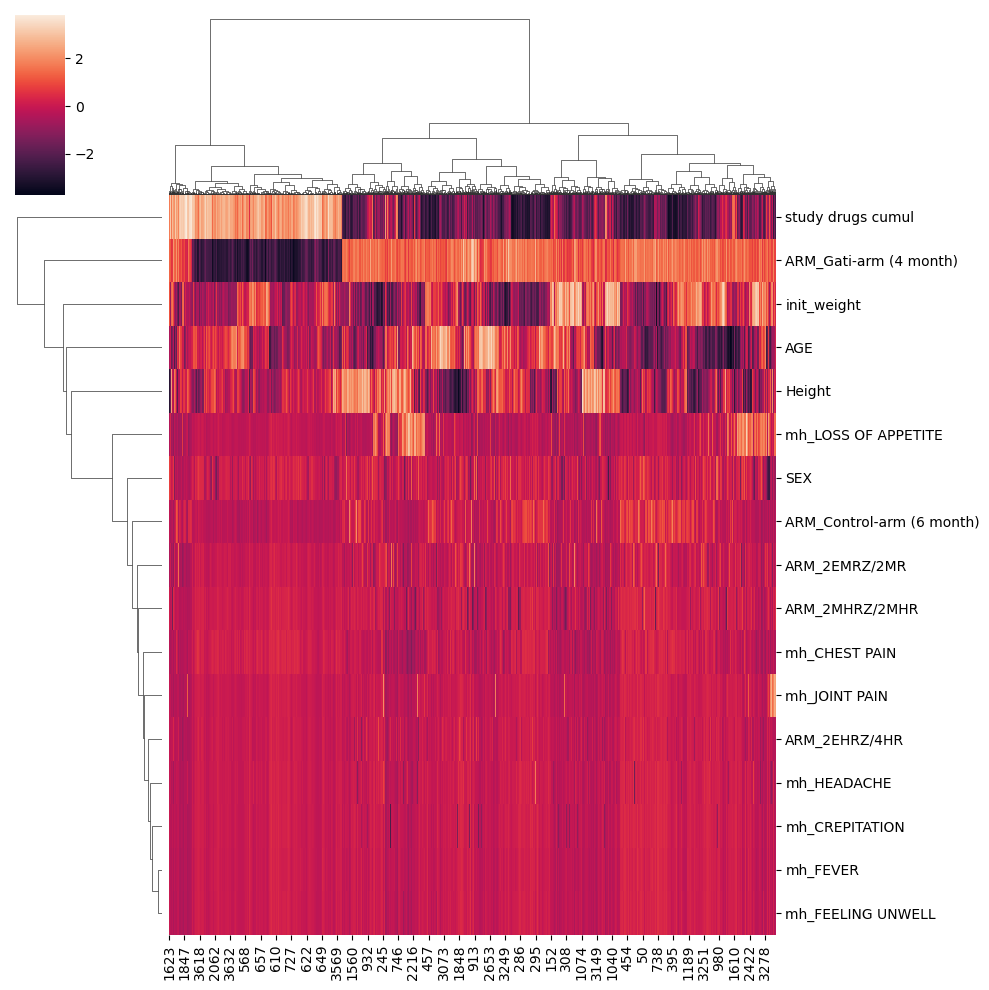

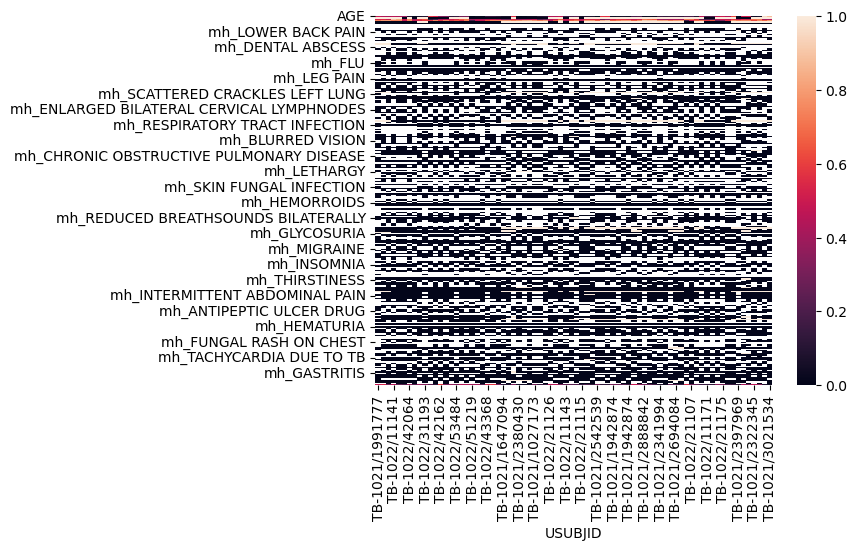

In [15]:
g=sns.clustermap(merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains('cv_repeat_num|ARM')].T,
               z_score=None,metric='euclidean',
               method='ward')

pat_order=[int(label.get_text()) for label in g.ax_heatmap.get_xticklabels()]

## PLot the matching original input variables of the patients clustered in first plot
fig=plt.figure()
f=sns.heatmap(merged_x_test_across_cv.loc[merged_x_test_across_cv.index[pat_order],~merged_x_test_across_cv.columns.str.contains('cv_repeat_num|ARM')].T)
#              metric='euclidean',
#               method='ward')
              

## Cluster SHAP-values per CV-repeat

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/se

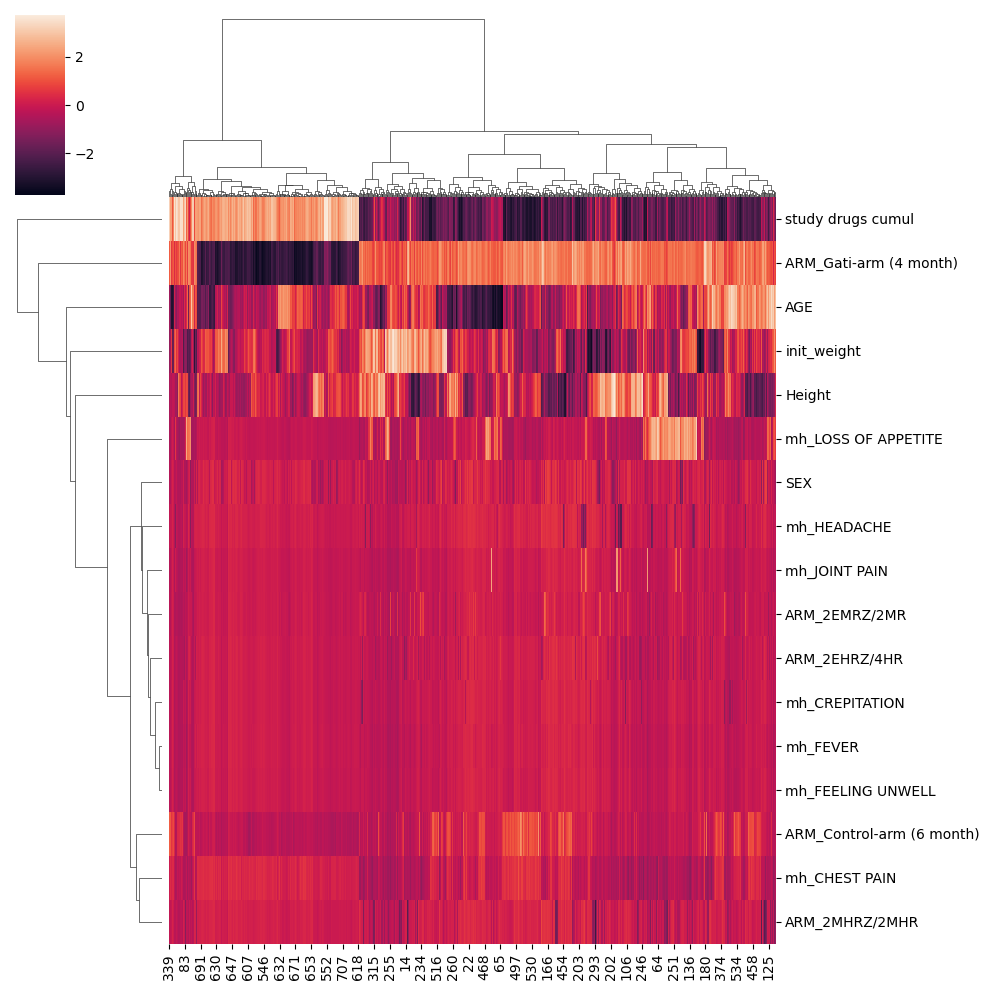

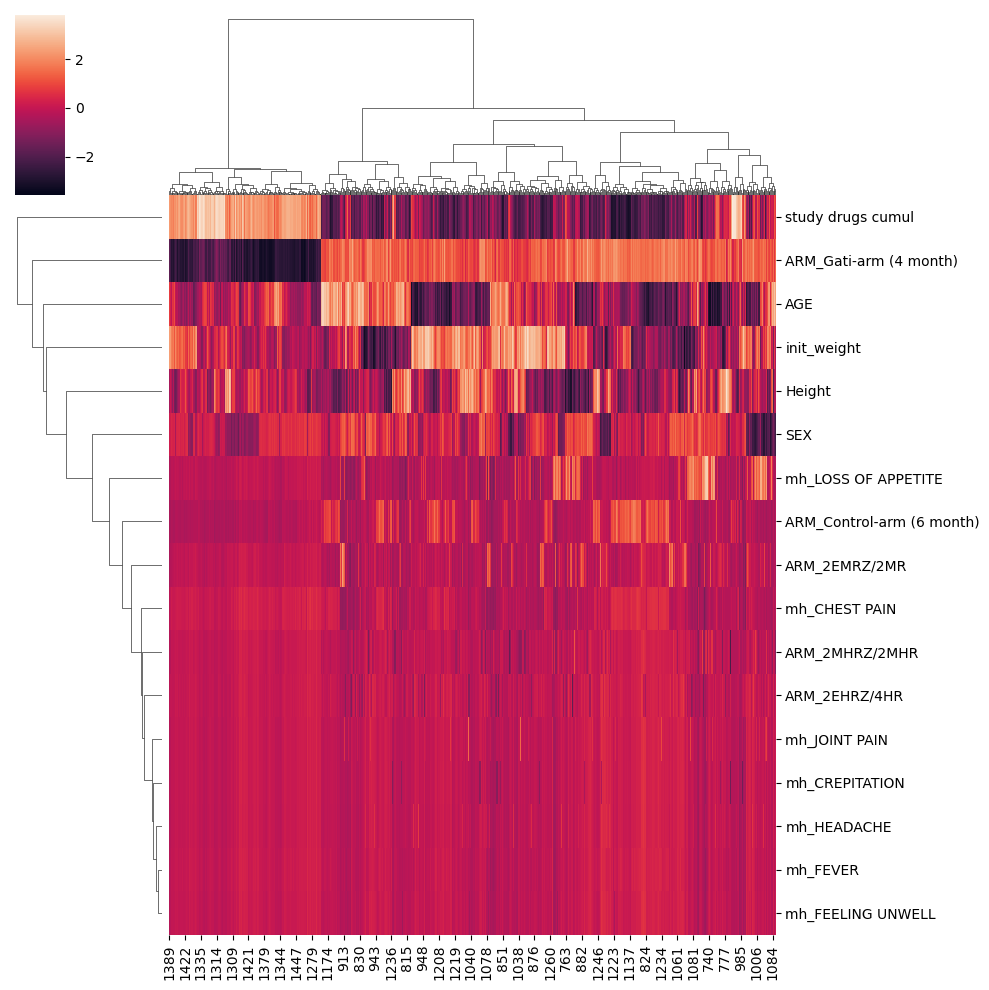

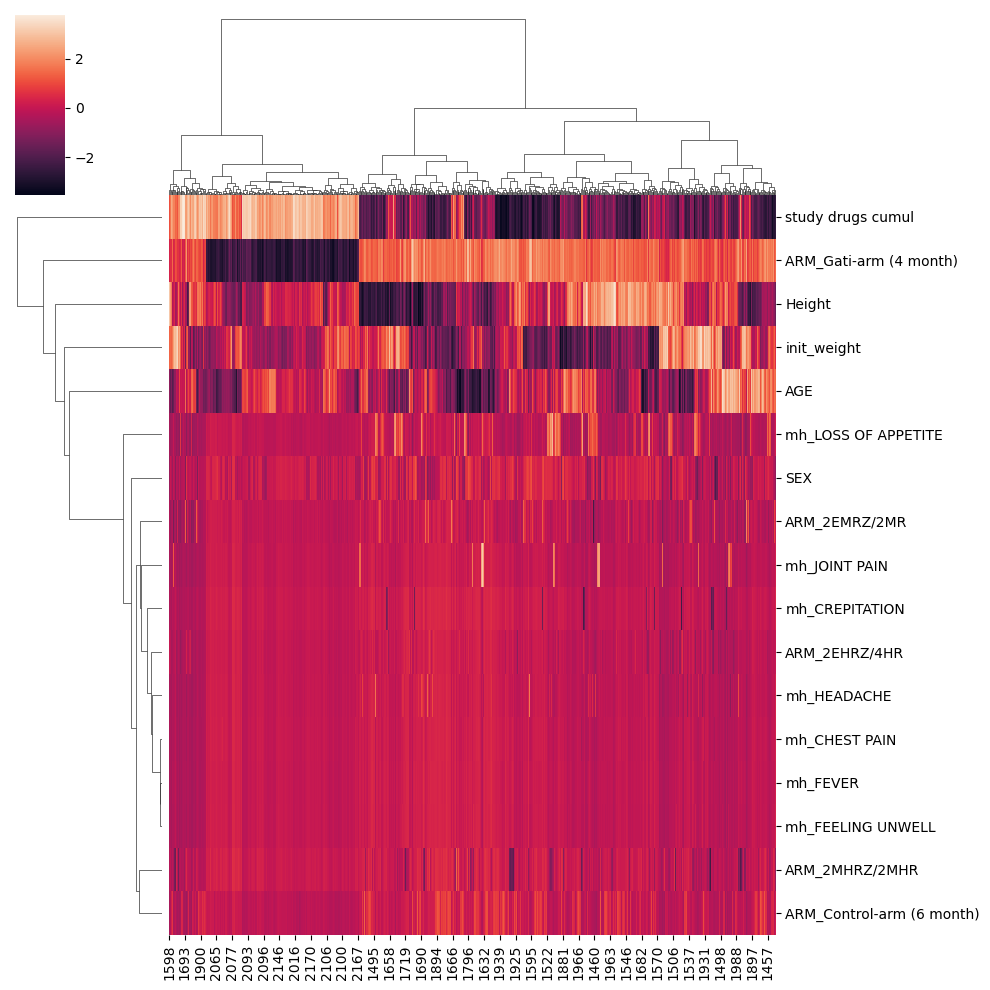

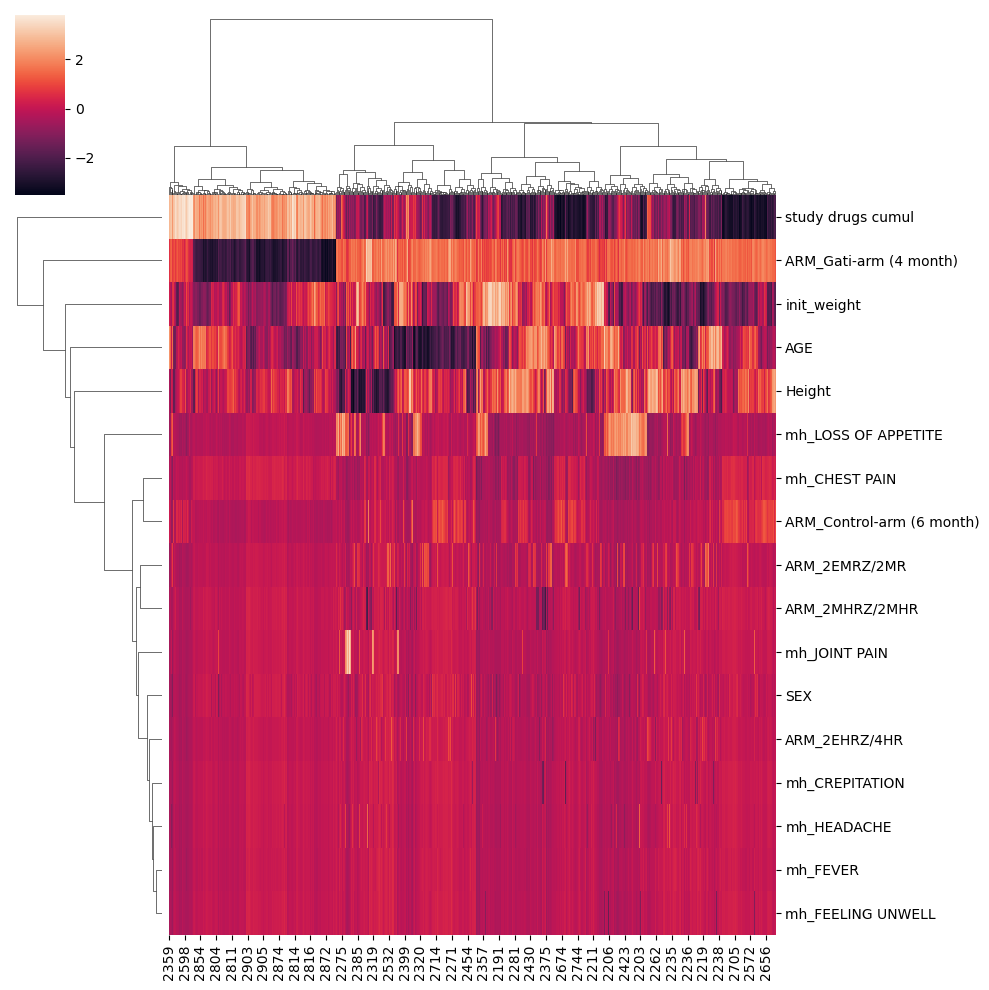

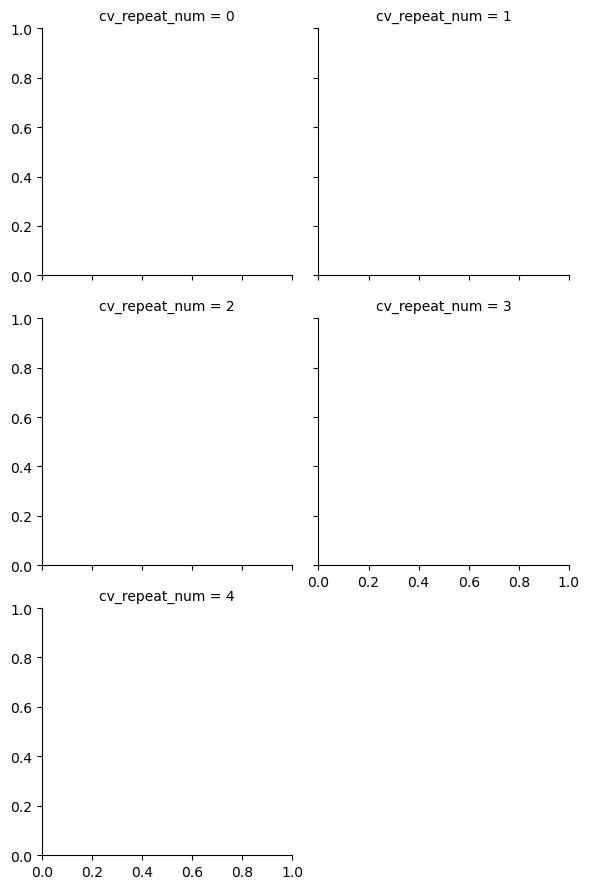

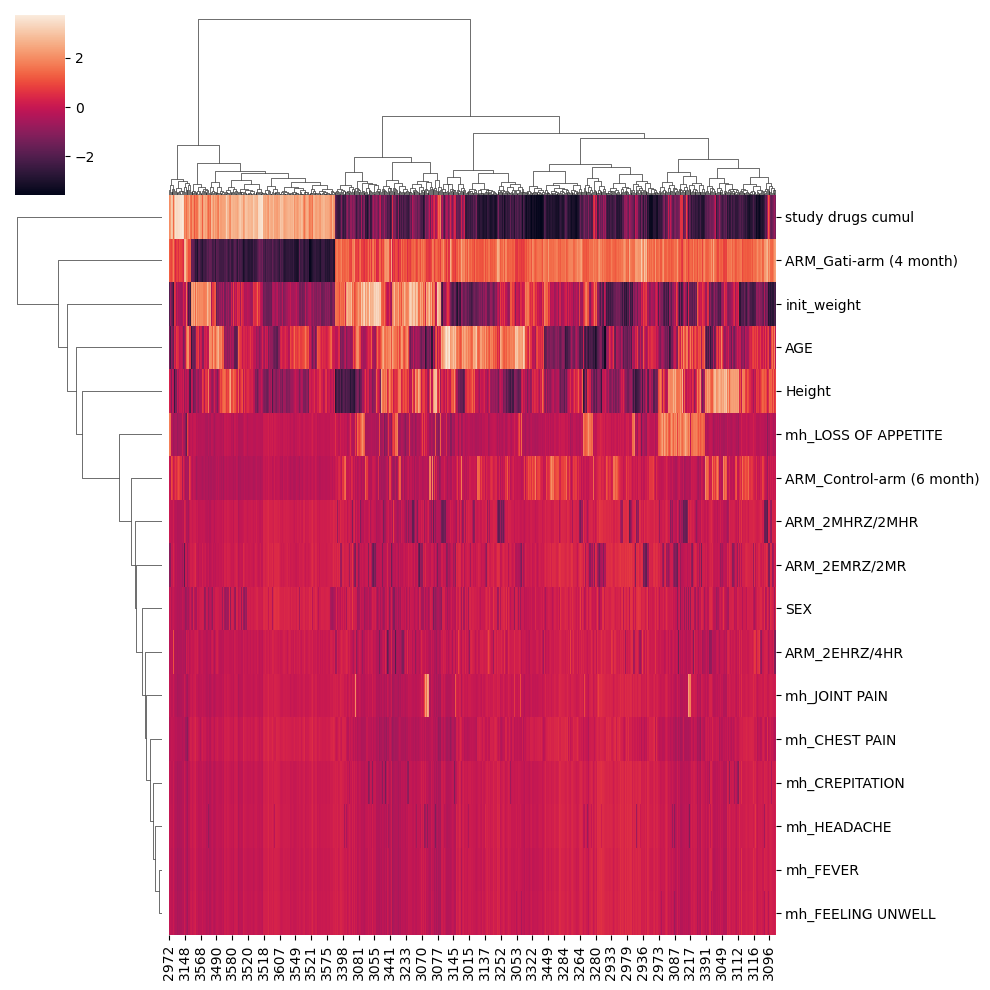

In [33]:
# Custom function to plot clustermap
def plot_clustermap(data, **kwargs):
    sns.clustermap(data.loc[:, ~data.columns.str.contains(r'cv_repeat_num|\bARM\b',regex=True)].T,
                   z_score=1, metric='euclidean',
                   method='ward', **kwargs)

# Prepare FacetGrid
a=merged_shap_across_cv_numeric.loc[:,~merged_shap_across_cv_numeric.columns.str.contains(r'\bARM\b',regex=True)].set_index('cv_repeat_num')
g = sns.FacetGrid(merged_shap_across_cv_numeric,
                   col="cv_repeat_num", col_wrap=2, sharex=True, sharey=True)

# Apply custom function to each facet
g.map_dataframe(plot_clustermap)

# Adjust layout
plt.show()

In [26]:
a

,AGE,SEX,Height,study drugs cumul,mh_CHEST PAIN,mh_LOSS OF APPETITE,mh_FEVER,mh_HEADACHE,mh_CREPITATION,mh_JOINT PAIN,mh_FEELING UNWELL,init_weight,ARM_2EHRZ/4HR,ARM_2EMRZ/2MR,ARM_2MHRZ/2MHR,ARM_Control-arm (6 month),ARM_Gati-arm (4 month)
cv_repeat_num,,,,,,,,,,,,,,,,,
0,0.777317,-0.524523,0.686569,-2.141665,-0.239095,1.248064,0.000149,0.062933,0.026006,-0.023895,0.000000,0.408677,-0.344555,0.016792,0.065133,-0.079983,1.119696
0,0.846486,0.147242,-0.699540,-1.911807,-0.199359,-0.356550,-0.044138,0.131629,0.027356,-0.024873,0.000000,2.110164,-0.145845,0.008799,0.132329,0.049981,1.401966
0,-0.424850,0.118226,0.556400,1.389991,-0.264024,-0.320543,-0.047056,0.169675,0.026006,-0.015592,0.000000,-1.200994,-0.178317,-0.107519,0.149879,-0.107178,1.153057
0,-0.614625,0.049434,-1.224180,-2.891407,-0.511252,1.903734,-0.073447,0.114773,0.026006,-0.022223,0.000000,-2.116575,-0.344915,-0.024373,0.109387,-0.277632,1.123117
0,2.217920,0.315370,3.230948,-1.765741,-0.378157,1.533306,-0.062718,0.072389,0.026006,-0.029151,0.000000,0.646351,-0.201881,0.077970,0.071518,-0.204050,1.595064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,1.044443,0.347010,-0.641334,3.600105,0.265424,-0.269195,-0.028588,0.037121,0.015043,0.003177,0.014794,-0.715645,0.018257,0.153094,0.125313,-0.457768,-3.080823
4,0.637484,0.358754,0.554788,4.231438,0.155598,-0.164212,-0.015135,0.055458,0.015647,-0.002390,0.014794,-0.978936,0.029946,0.151321,0.178987,-0.429295,-4.401698
4,-0.113632,-0.768312,0.220178,2.558484,0.232799,-0.196571,-0.023552,0.057250,0.015043,0.000786,0.014794,-2.128358,0.039883,0.125491,0.174820,-0.446546,-4.403893
